# Indiana Pines

1. Import dependencies

In [1]:
import random
import torch
import multiprocessing
import numpy as np
import re
import time

import torch.utils.data as data

from lightning import Trainer
from dataclasses import asdict
from typing import Optional, Sequence
from pathlib import Path
from sklearn.model_selection import train_test_split

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask_from_path,
    train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.model.hsic import HyperSpectralImageClassifier
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_generic,
    plot_epoch_generic,
    plot_3_generic,
)
from src.data.dataset_decorator import UnlabeledDatasetDecorator, BinaryDatasetDecorator
from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
    lightning_metrics,
)
from src.util.scheduler import CosineLRSchedulerWrapper
from src.model.dbda import DBDA
from src.model.representative_datapoints_search import (
    RepresentativeDataPointsSearchAdapter, RepresentativeDataPointsSearch
)
from src.definitions import RAW_DATA_FOLDER, REPORTS_FOLDER

2. Prepare env

In [2]:
epoch_seconds = int(time.time())

log_dir = REPORTS_FOLDER / f"dbda-k-medoids-vs-random-sample-{epoch_seconds}"

In [3]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 30

In [4]:
batch_size = 64
patch_size = 9
target_dim = 75

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [5]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [6]:
torch.cuda.empty_cache()

In [7]:
torch.set_float32_matmul_precision("medium")

In [8]:
f"Device is {device}"

'Device is mps'

3. Load dataset

In [9]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [10]:
_, image = preprocess_hsi(image, pre_process_type)

In [11]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [12]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [13]:
x.shape

(21025, 9, 9, 75)

In [14]:
y.shape

(21025,)

In [15]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [16]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [17]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 14'

In [18]:
full_dataset = data.TensorDataset(x_tensor, y_tensor)

full_loader = data.DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

In [19]:
mask_arr = [
    (float(re.search(r"-(0_\d+)\.npy$", str(fn)).group(1).replace("_", ".")), fn)
    for fn in Path(RAW_DATA_FOLDER / "mask" / "k-medoids").glob(
        f"indian-pines-k-medoids-STANDARTIZATION-PCA-overall-*.npy"
    )
]

mask_arr = sorted(mask_arr, key=lambda it: it[0])

In [20]:
unique, counts = np.unique(labels, return_counts=True)

labels_per_class = {u: c for u, c in zip(unique, counts)}

4. Train model on a random sampled dataset (stratified).

In [21]:
class RandomSampleDataPointsSearch(
    RepresentativeDataPointsSearchAdapter[HyperSpectralImageClassifier]
):

    def __init__(self, stratify=False):
        super().__init__()

        self.stratify = stratify

    def get_run_params(
        self,
    ) -> Sequence[
        tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
    ]:
        params = {
            "num_epochs": num_epochs,
            "learning_rate": learning_rate,
            "t_initial": num_epochs,
            "weight_decay": weight_decay,
            "lr_min": learning_rate * 0.01,
            "warmup_lr_init": learning_rate * 0.01,
            "warmup_t": int(np.ceil(0.1 * num_epochs)),
        }

        return [self.create_run_params(id, params) for id, _ in mask_arr]

    def init_model(self, params: dict[str, float]) -> HyperSpectralImageClassifier:
        return HyperSpectralImageClassifier(
            DBDA(band=target_dim, classes=num_classes),
            num_classes,
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
            scheduler=lambda optimizer: CosineLRSchedulerWrapper(
                optimizer,
                t_initial=params["num_epochs"],
                lr_min=params["lr_min"],
                warmup_t=params["warmup_t"],
                warmup_lr_init=params["warmup_lr_init"],
            ),
        )

    def fit_model(
        self,
        model: HyperSpectralImageClassifier,
        loader: data.DataLoader,
        eval_loader: Optional[data.DataLoader],
        params: dict[str, float],
    ):
        trainer = Trainer(accelerator="auto", max_epochs=params["num_epochs"])

        trainer.fit(model, loader, eval_loader)

        return [asdict(it) for it in model.val_metrics]

    def score_model(
        self, model: HyperSpectralImageClassifier
    ) -> list[dict[str, float]]:
        trainer = Trainer(accelerator="auto", max_epochs=0)

        return trainer.validate(model, full_loader)[0]

    def on_scored_model(
        self,
        id: str,
        params: dict[str, float],
        model: HyperSpectralImageClassifier,
        model_history: list[dict[str, float]],
        score: dict[str, float],
    ):
        trainer = Trainer(accelerator="auto", max_epochs=0)

        losses = [it["loss"].cpu() for it in model_history]
        f1s = [it["f1"].cpu() for it in model_history]
        plot_epoch_generic(losses, desc=f"Loss ({id} examples)")
        plot_epoch_generic(f1s, desc=f"F1 ({id} examples)")

        y_pred = trainer.predict(model, predict_loader)
        y_pred = torch.cat(y_pred, dim=0)
        y_pred = torch.argmax(y_pred, dim=1)
        y_pred = y_pred.reshape(image_h, image_w)

        plot_segmentation_comparison(y.reshape(image_h, image_w), y_pred.numpy())

        model_labels_count = {
            key: int(value * float(id)) for key, value in labels_per_class.items()
        }
        model_name = create_model_name(f"indian_pines", model_labels_count)
        model_category = "dbda"

        run_params = {
            **params,
            "batch_size": batch_size,
            "patch_size": patch_size,
            "target_dim": target_dim,
            "pre_process_type": str(pre_process_type),
            "dim_reduction_type": str(dim_reduction_type),
        }

        report_run(
            model_name=model_name,
            model_category=model_category,
            run_desc=f"Train model with a random sampled dataset (stratify = {self.stratify})",
            run_params=run_params | model.get_params(),
            run_metrics=lightning_metrics(score),
        )

        read_report_to_show(model_name, sort_by_metric="f1")

    def create_dataloader_from_fraction(
        self, fraction: float
    ) -> tuple[data.DataLoader, data.DataLoader]:

        if self.stratify:
            x_train, x_test, y_train, y_test = train_test_split(
                x, y, train_size=fraction, random_state=random_seed, stratify=y
            )
        else:
            x_train, x_test, y_train, y_test = train_test_split(
                x, y, train_size=fraction, random_state=random_seed
            )

        x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 3, 1, 2)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
        test_dataset = data.TensorDataset(x_test_tensor, y_test_tensor)

        train_loader = data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=cpu_count,
            persistent_workers=True,
        )
        test_loader = data.DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=cpu_count,
            persistent_workers=True,
        )

        return train_loader, None

    def create_run_params(
        self, id: float, params: dict[str, float]
    ) -> tuple[str, data.DataLoader, data.DataLoader, dict[str, float]]:
        loader, eval_loader = self.create_dataloader_from_fraction(id)

        return str(id), loader, eval_loader, params

  0%|          | 0/18 [00:00<?, ?it/s]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trai

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.727562427520752
         val_f1             0.7004178166389465
        val_kappa                   nan
        val_loss             0.822583019733429
  val_overall_accuracy      0.5350842475891113
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


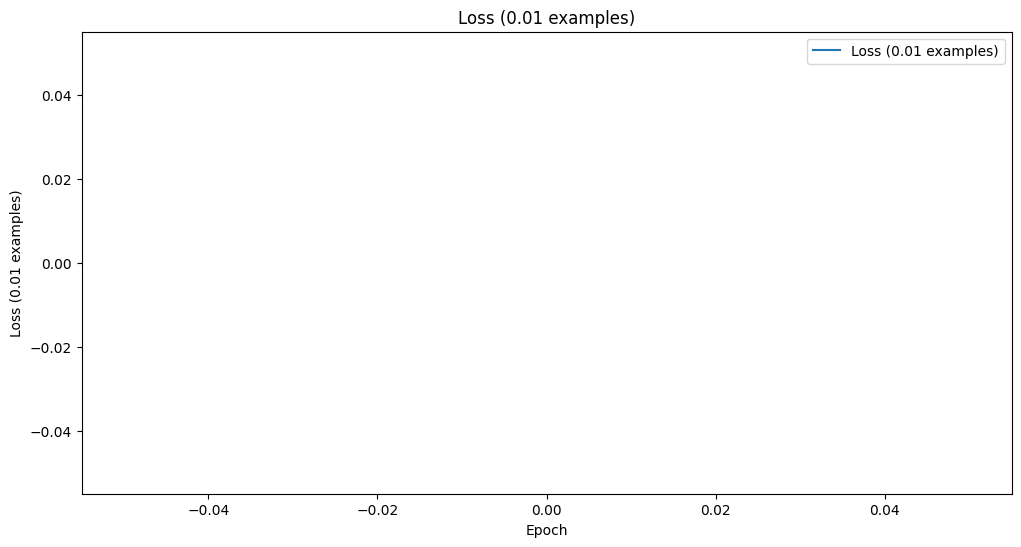

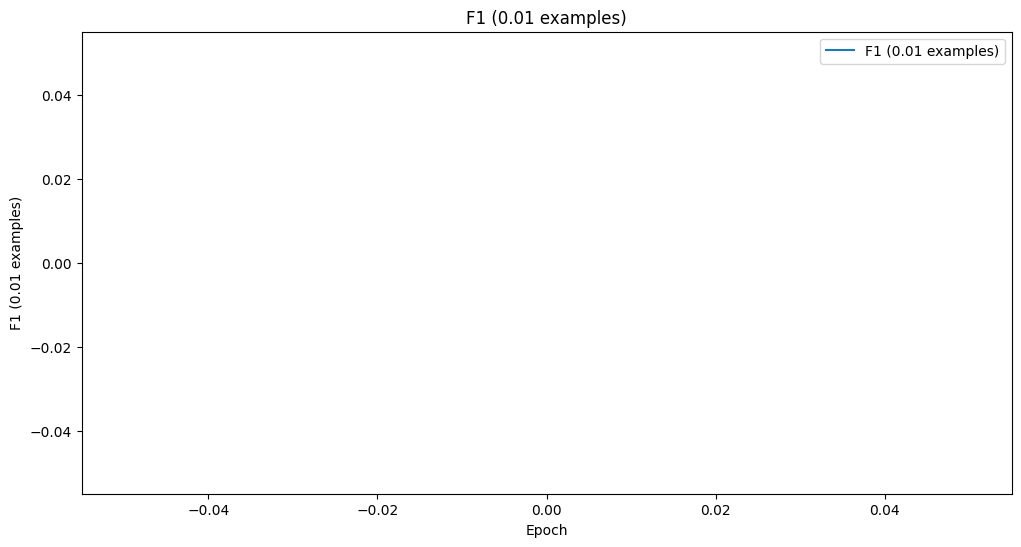

Predicting: |          | 0/? [00:00<?, ?it/s]

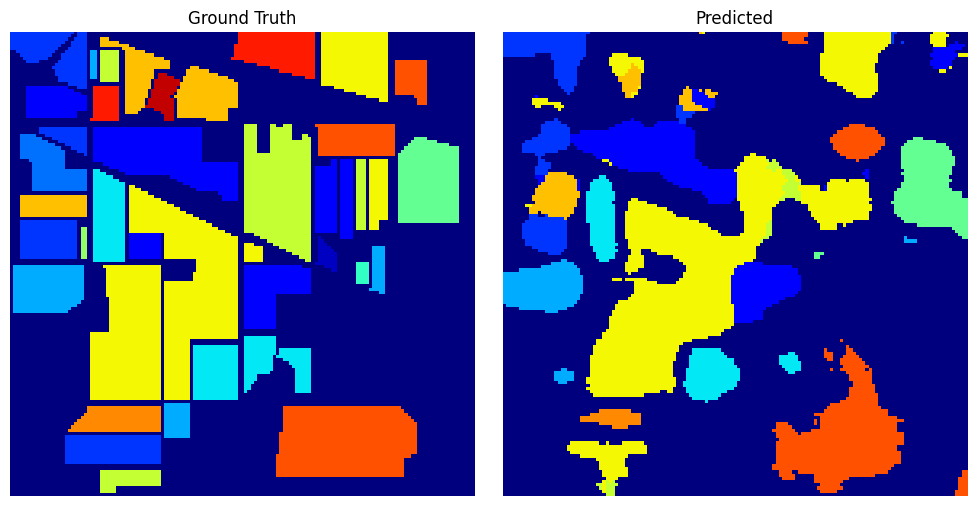

  6%|▌         | 1/18 [00:48<13:39, 48.19s/it, id=0.01, val_average_accuracy=0.728, val_f1=0.7, val_kappa=nan, val_loss=0.823, val_overall_accuracy=0.535]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7904399633407593
         val_f1             0.7764742970466614
        val_kappa                   nan
        val_loss            0.6481728553771973
  val_overall_accuracy      0.6177584528923035
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


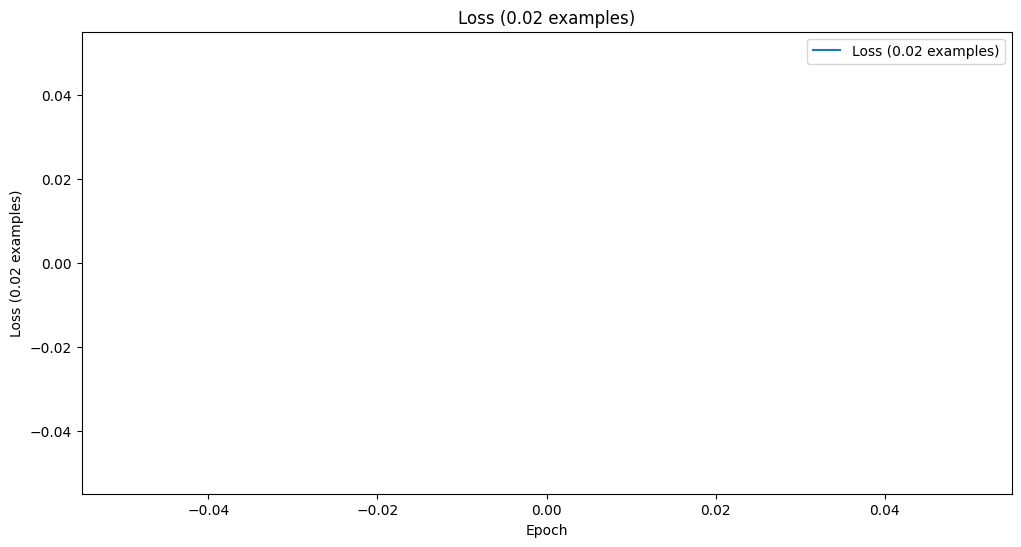

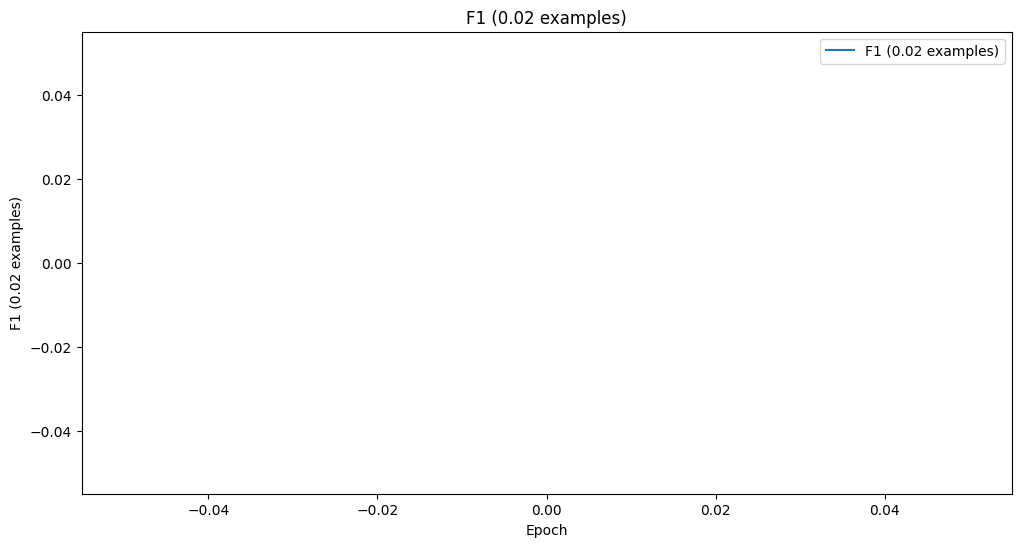

Predicting: |          | 0/? [00:00<?, ?it/s]

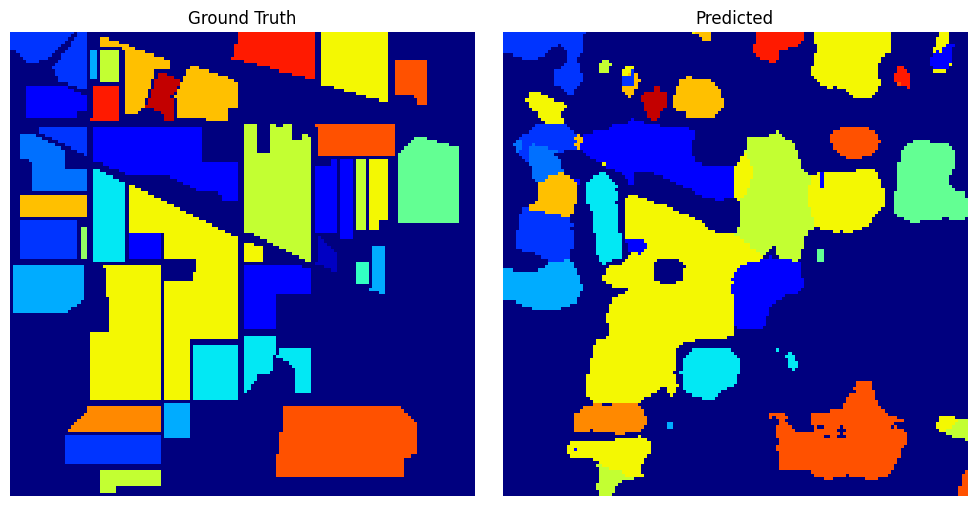

 11%|█         | 2/18 [01:52<15:24, 57.78s/it, id=0.02, val_average_accuracy=0.79, val_f1=0.776, val_kappa=nan, val_loss=0.648, val_overall_accuracy=0.618]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy  

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8260166645050049
         val_f1             0.8134618401527405
        val_kappa                   nan
        val_loss            0.4975533187389374
  val_overall_accuracy      0.6767523288726807
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


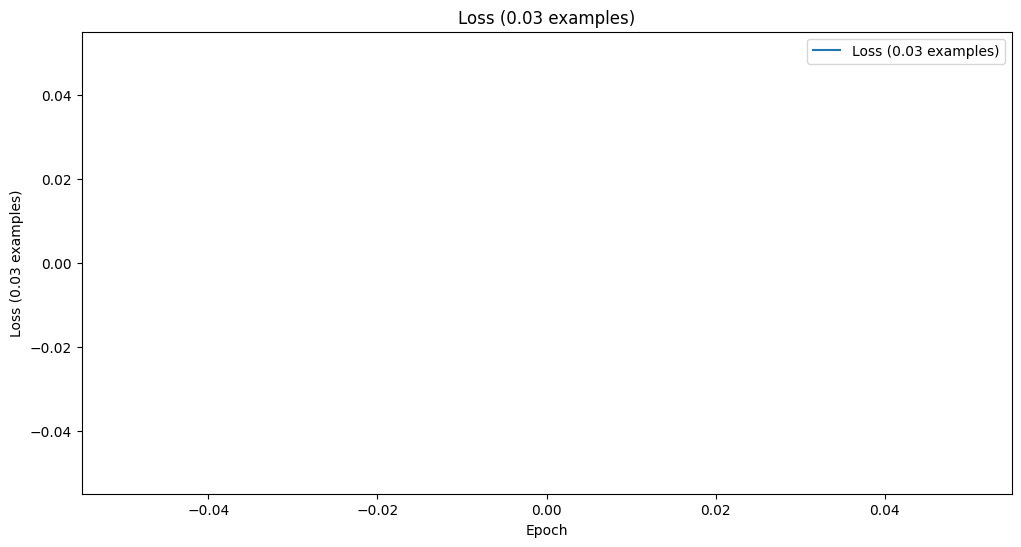

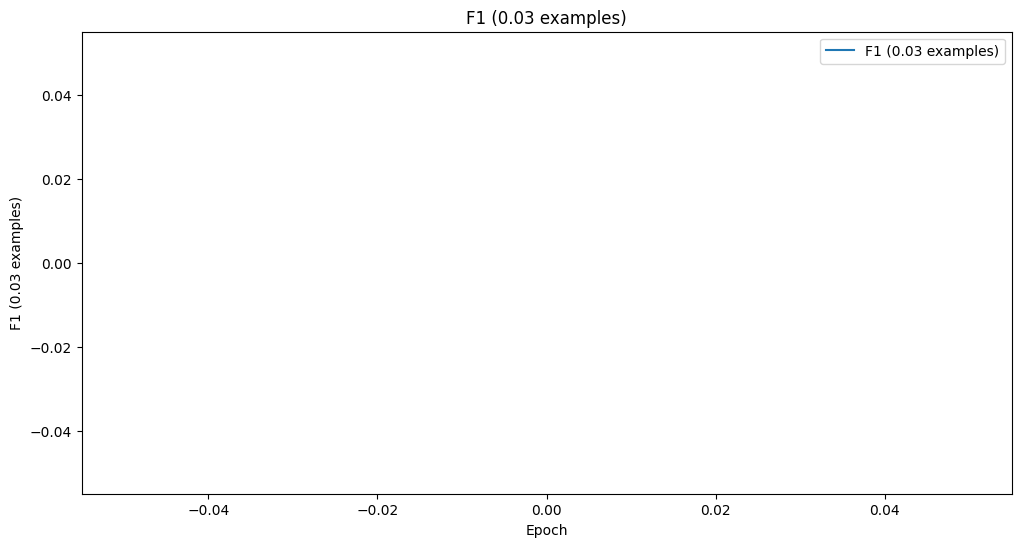

Predicting: |          | 0/? [00:00<?, ?it/s]

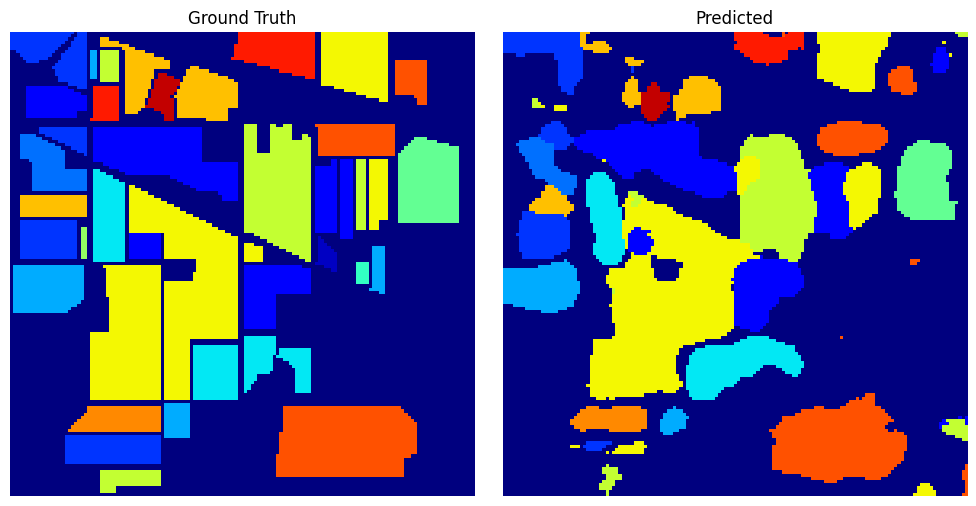

 17%|█▋        | 3/18 [03:14<17:14, 68.94s/it, id=0.03, val_average_accuracy=0.826, val_f1=0.813, val_kappa=nan, val_loss=0.498, val_overall_accuracy=0.677]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8393341302871704
         val_f1             0.8308054208755493
        val_kappa                   nan
        val_loss            0.4802743196487427
  val_overall_accuracy      0.6995301842689514
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


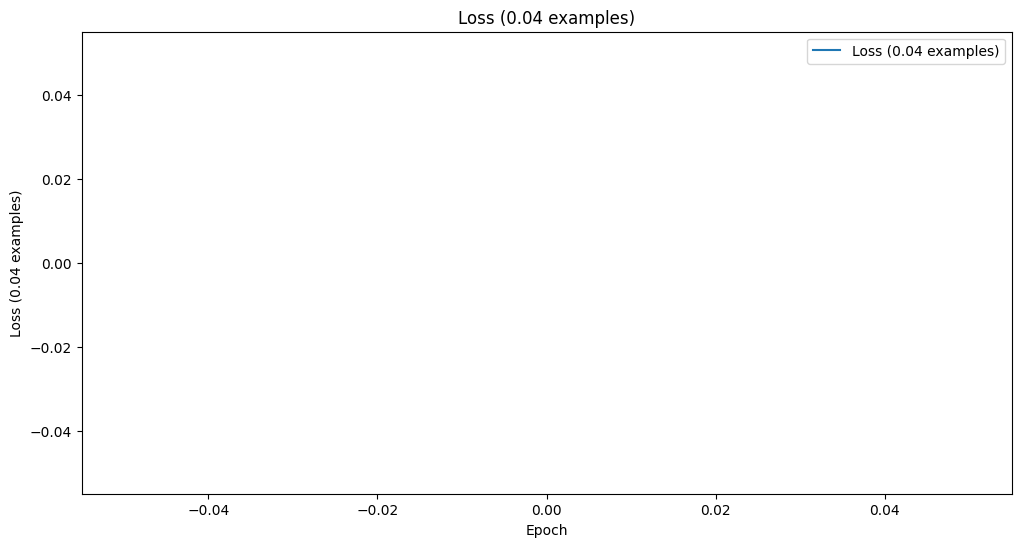

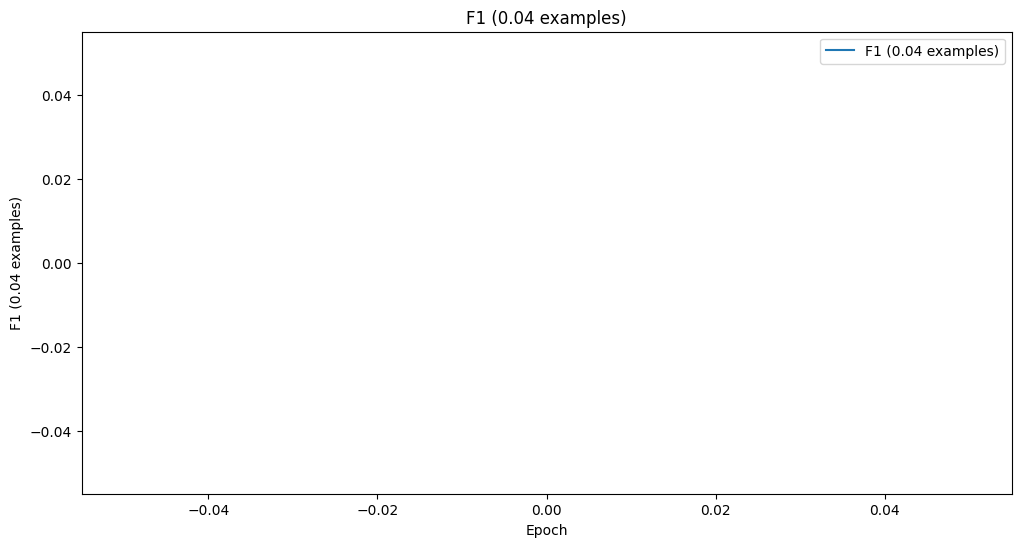

Predicting: |          | 0/? [00:00<?, ?it/s]

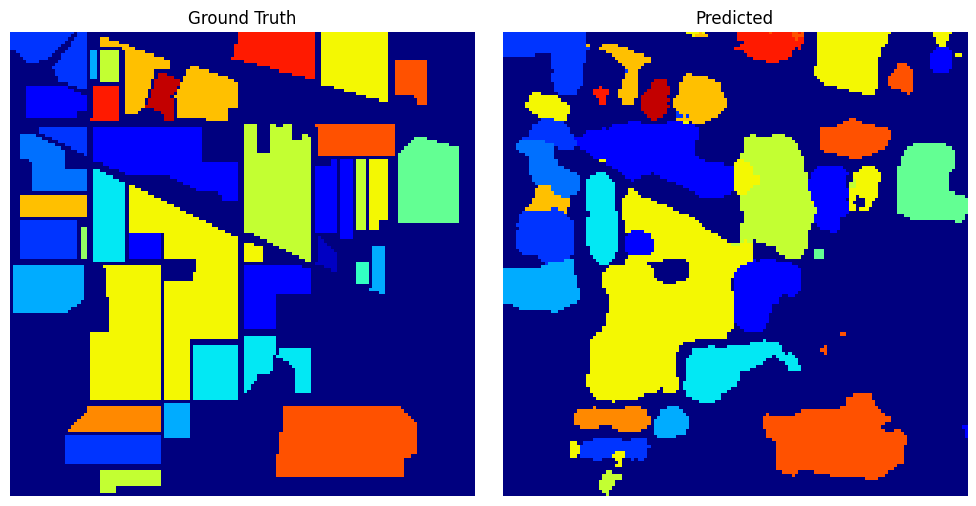

 22%|██▏       | 4/18 [04:59<19:24, 83.14s/it, id=0.04, val_average_accuracy=0.839, val_f1=0.831, val_kappa=nan, val_loss=0.48, val_overall_accuracy=0.7]   You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8729607462882996
         val_f1             0.8651397824287415
        val_kappa                   nan
        val_loss            0.3660302460193634
  val_overall_accuracy      0.7591742277145386
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


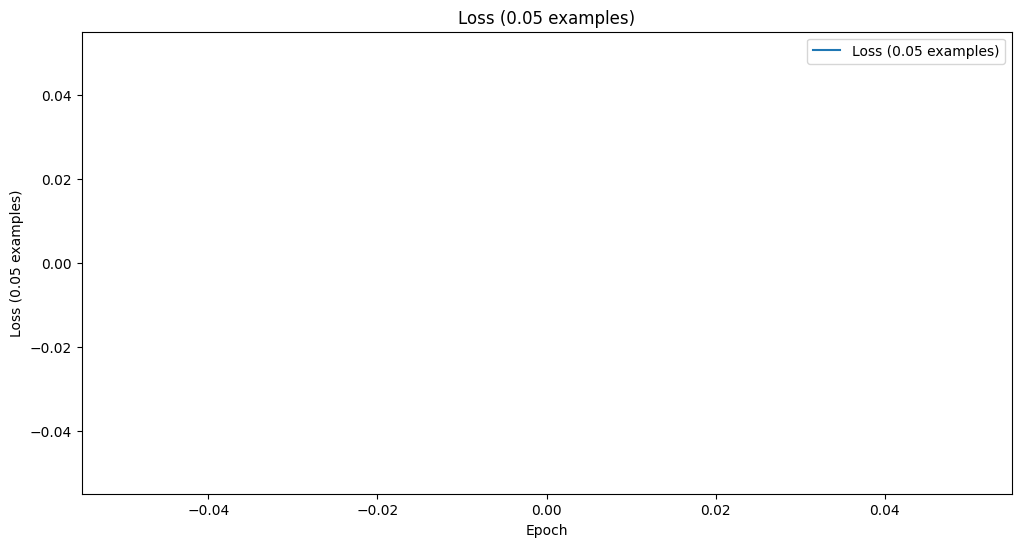

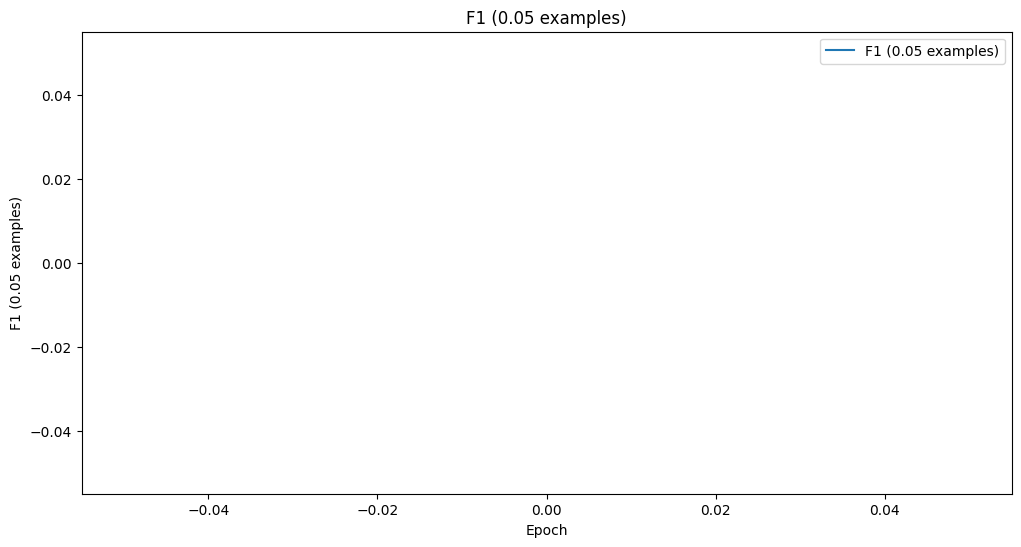

Predicting: |          | 0/? [00:00<?, ?it/s]

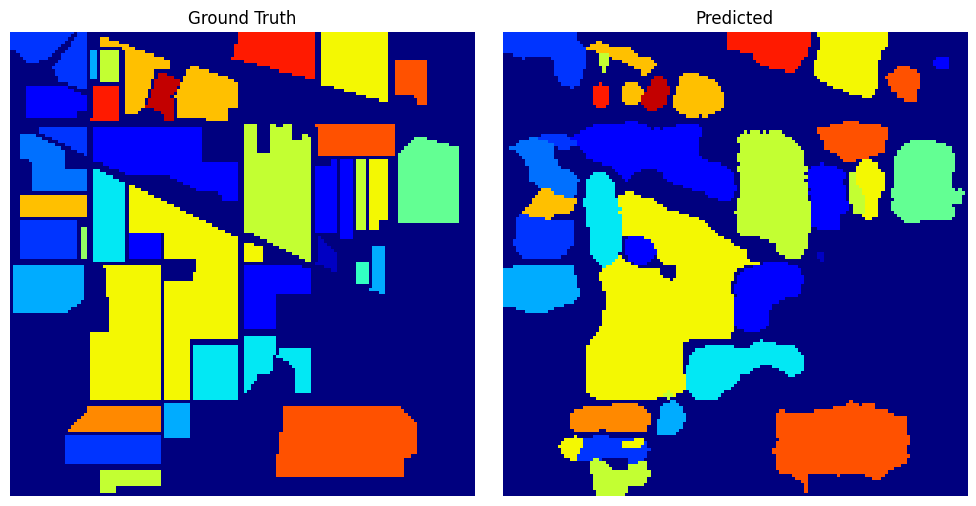

 28%|██▊       | 5/18 [07:12<21:51, 100.87s/it, id=0.05, val_average_accuracy=0.873, val_f1=0.865, val_kappa=nan, val_loss=0.366, val_overall_accuracy=0.759]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8748157024383545
         val_f1             0.8663435578346252
        val_kappa                   nan
        val_loss            0.3691149055957794
  val_overall_accuracy      0.7651005387306213
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


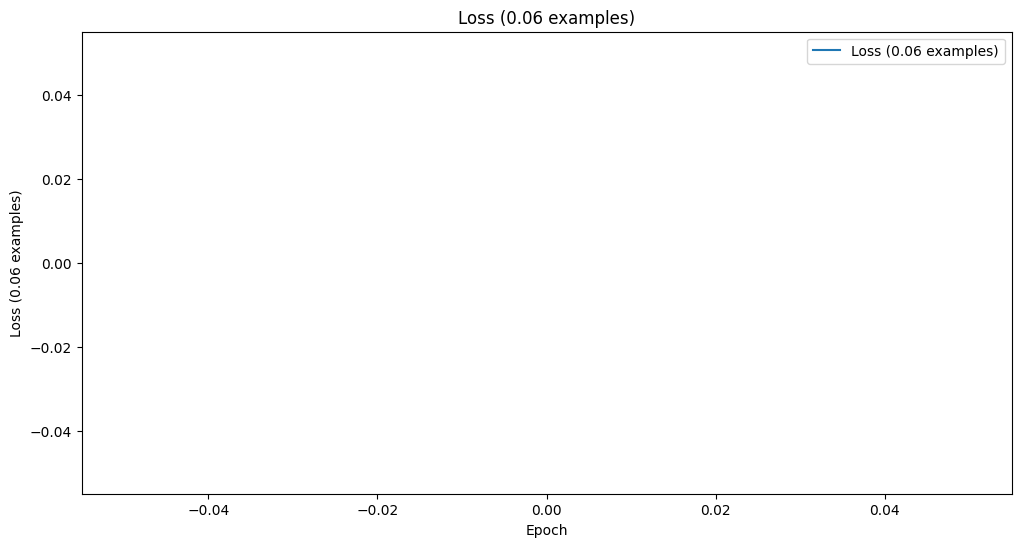

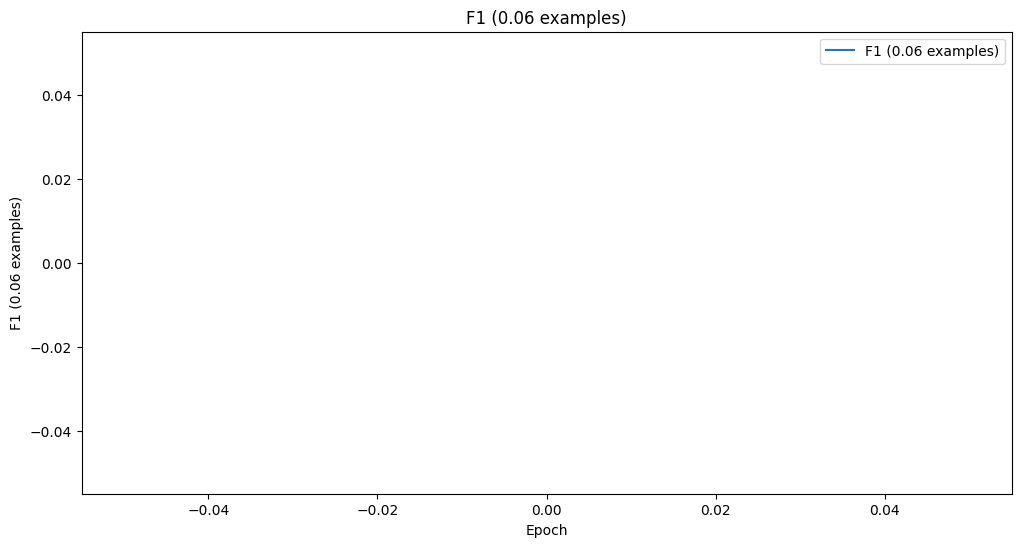

Predicting: |          | 0/? [00:00<?, ?it/s]

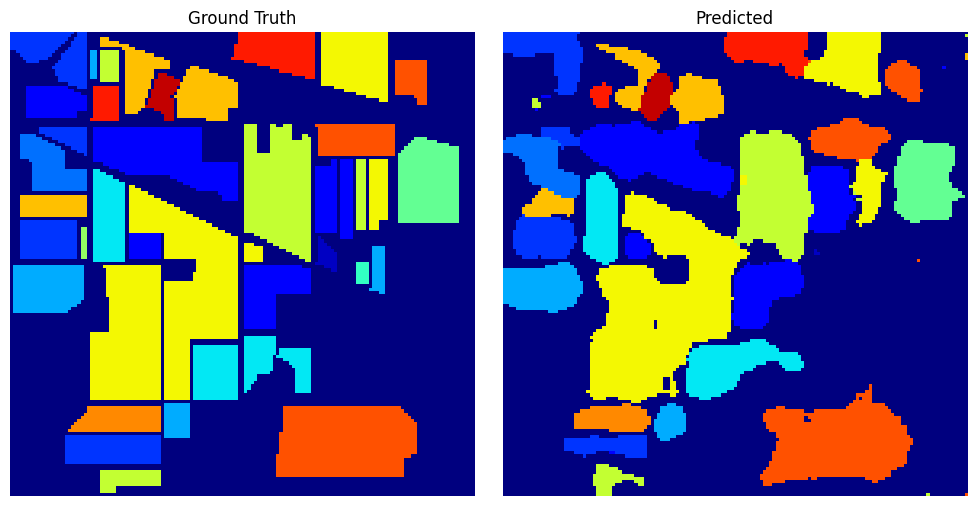

 33%|███▎      | 6/18 [09:28<22:35, 112.94s/it, id=0.06, val_average_accuracy=0.875, val_f1=0.866, val_kappa=nan, val_loss=0.369, val_overall_accuracy=0.765]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8894173502922058
         val_f1             0.8858003616333008
        val_kappa                   nan
        val_loss            0.31427285075187683
  val_overall_accuracy      0.7881587147712708
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


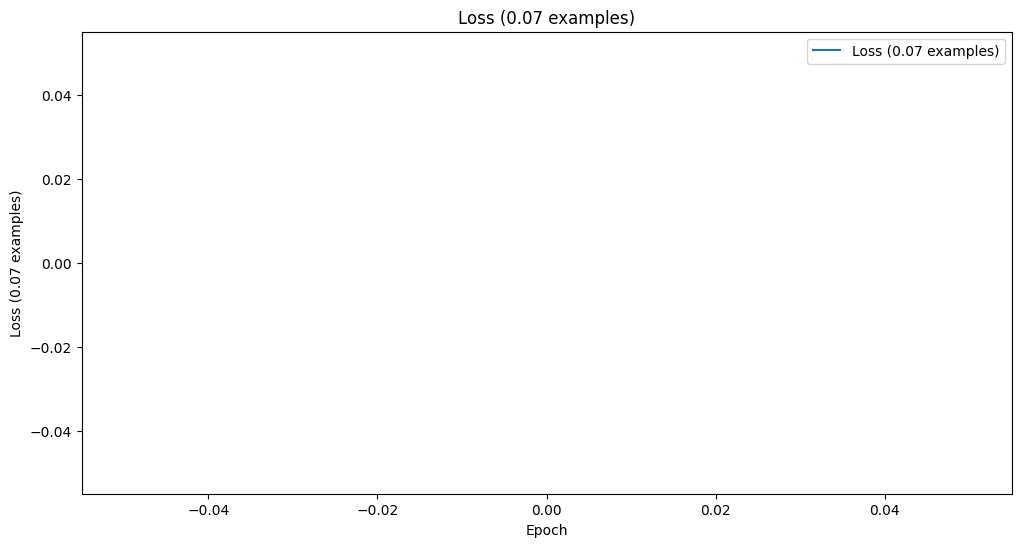

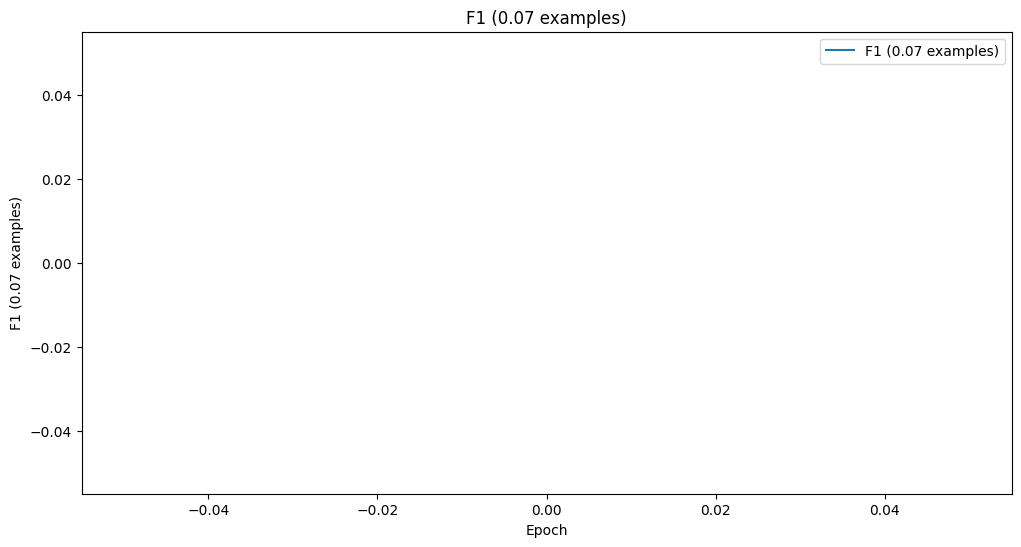

Predicting: |          | 0/? [00:00<?, ?it/s]

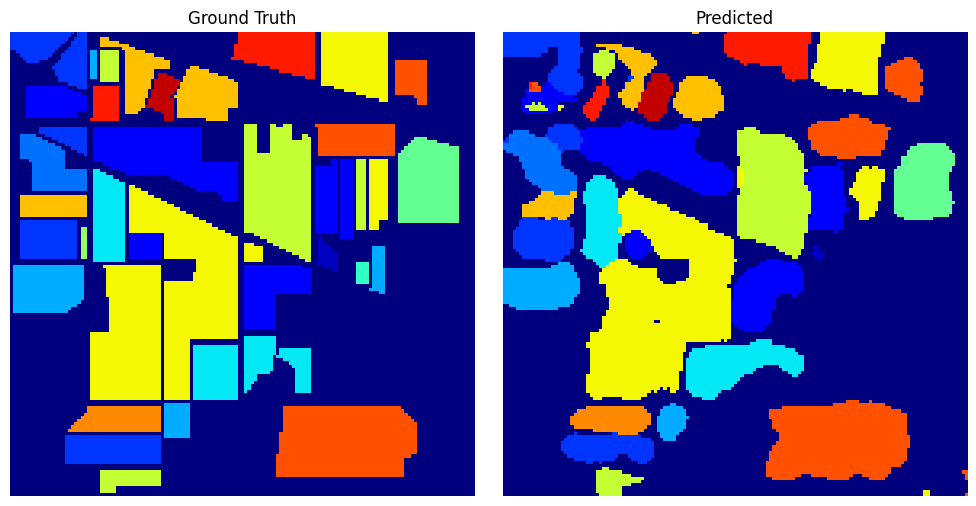

 39%|███▉      | 7/18 [12:02<23:09, 126.34s/it, id=0.07, val_average_accuracy=0.889, val_f1=0.886, val_kappa=nan, val_loss=0.314, val_overall_accuracy=0.788]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8887515068054199
         val_f1             0.8810848593711853
        val_kappa                   nan
        val_loss            0.3049134314060211
  val_overall_accuracy      0.7941306829452515
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


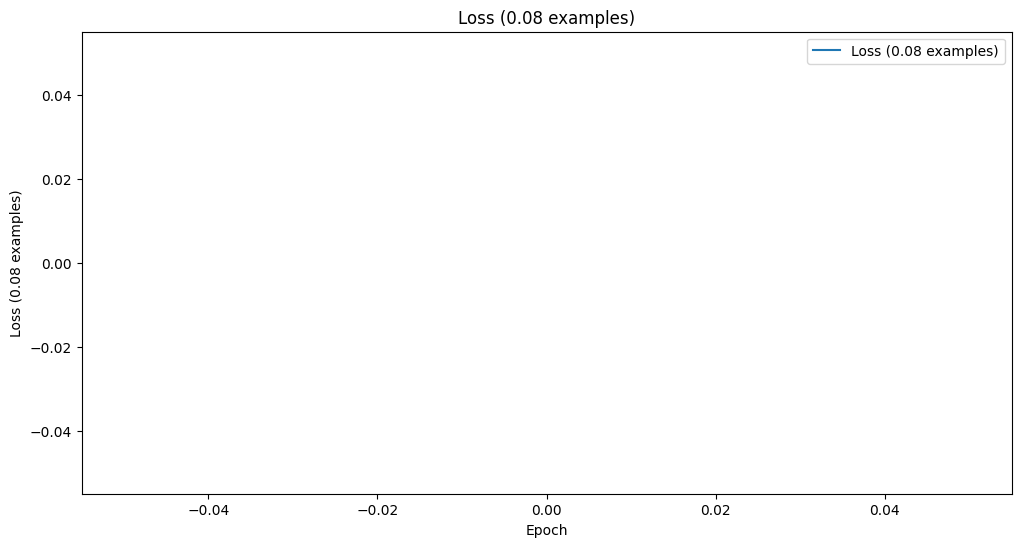

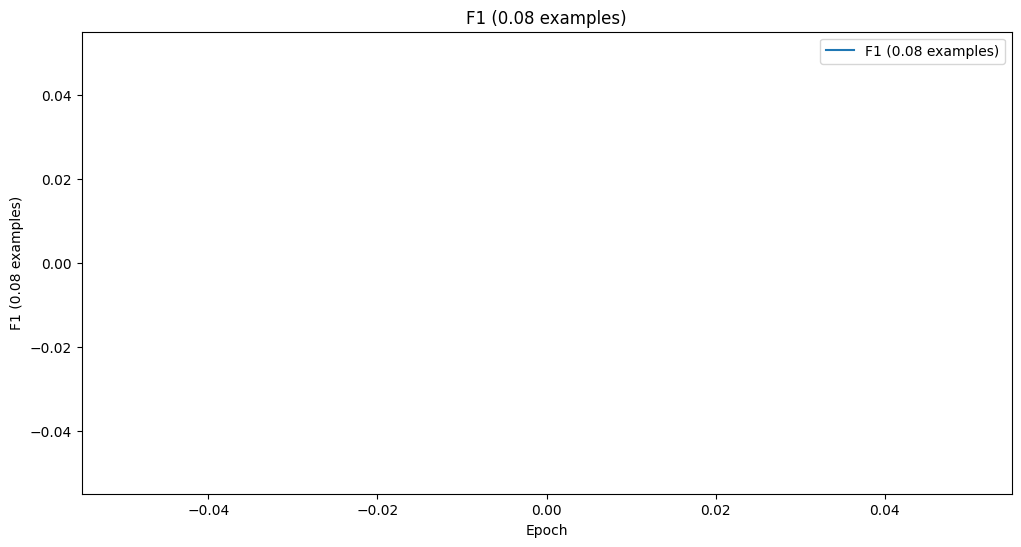

Predicting: |          | 0/? [00:00<?, ?it/s]

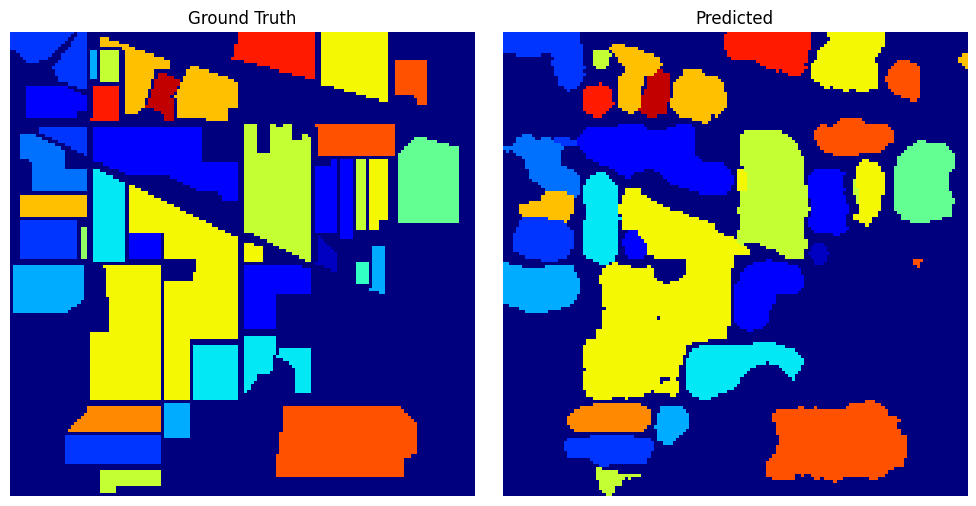

 44%|████▍     | 8/18 [14:52<23:21, 140.17s/it, id=0.08, val_average_accuracy=0.889, val_f1=0.881, val_kappa=nan, val_loss=0.305, val_overall_accuracy=0.794]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9047324657440186
         val_f1              0.902809739112854
        val_kappa                   nan
        val_loss            0.26681289076805115
  val_overall_accuracy      0.8110225796699524
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


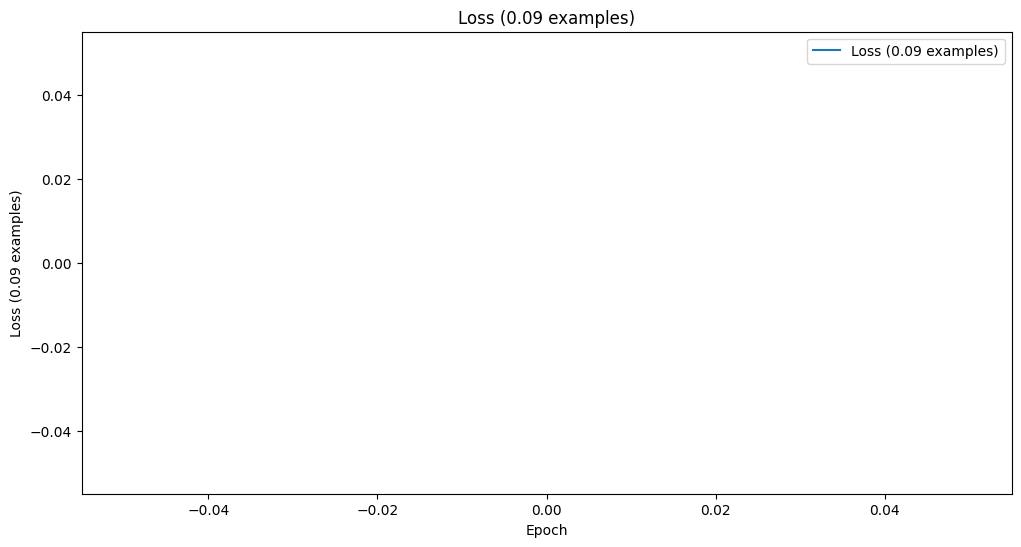

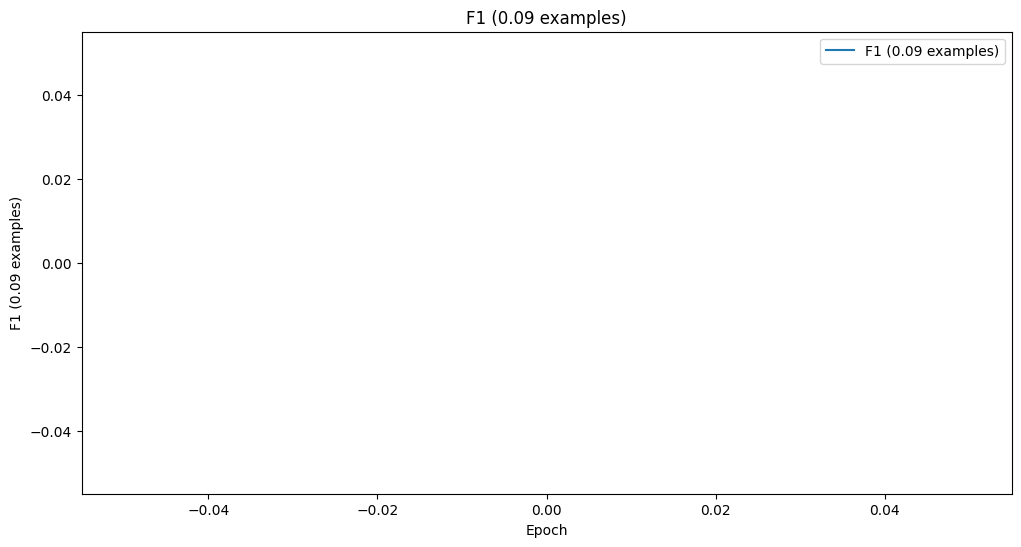

Predicting: |          | 0/? [00:00<?, ?it/s]

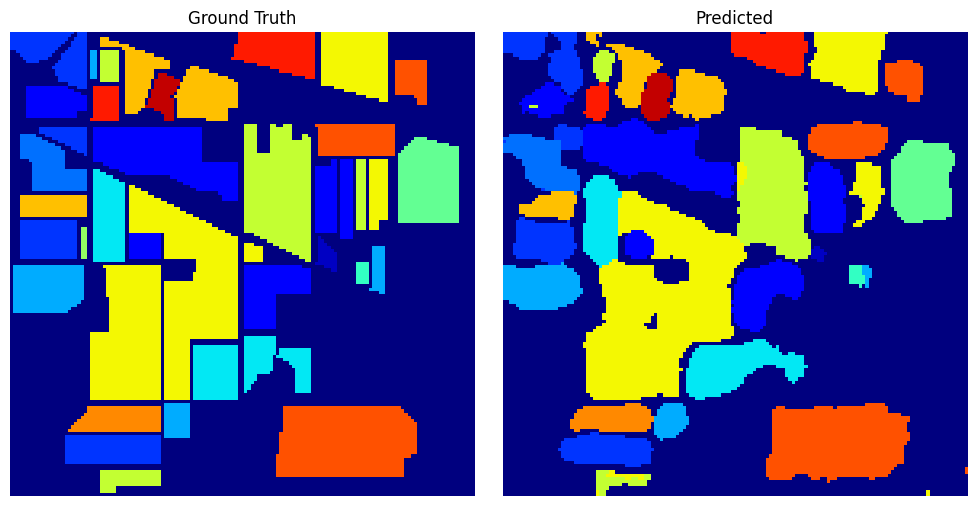

 50%|█████     | 9/18 [17:59<23:14, 154.90s/it, id=0.09, val_average_accuracy=0.905, val_f1=0.903, val_kappa=nan, val_loss=0.267, val_overall_accuracy=0.811]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9074435234069824
         val_f1             0.9054105877876282
        val_kappa                   nan
        val_loss             0.269185334444046
  val_overall_accuracy      0.8215442895889282
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


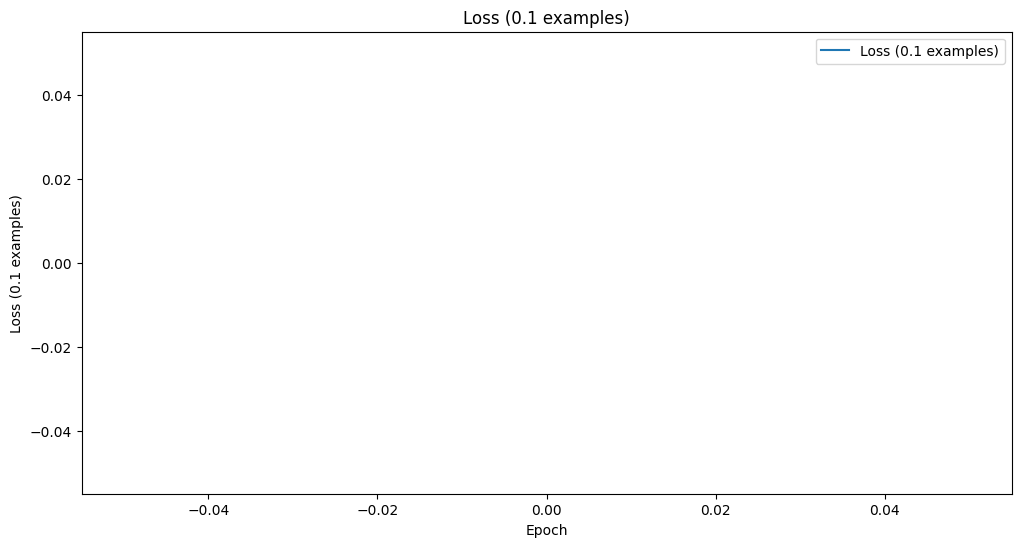

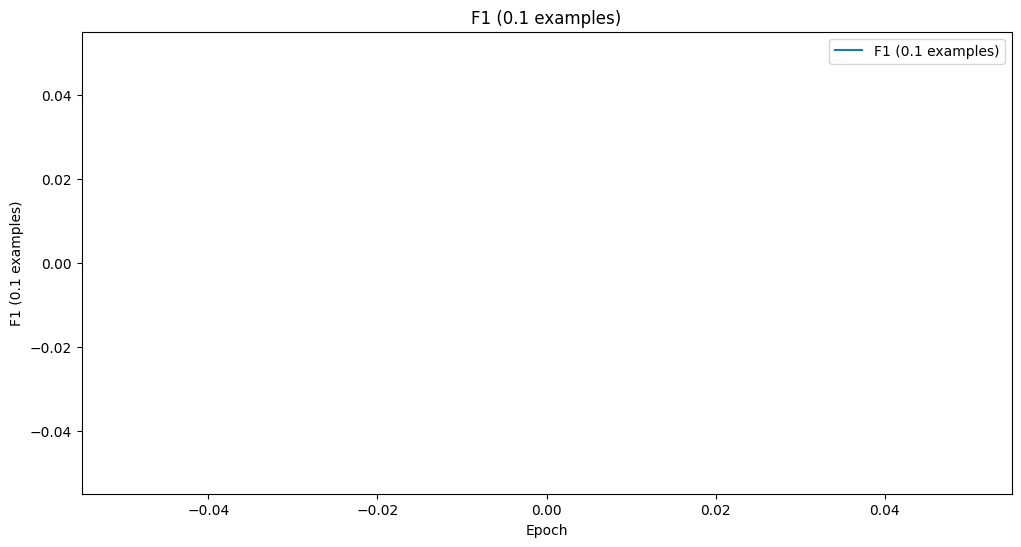

Predicting: |          | 0/? [00:00<?, ?it/s]

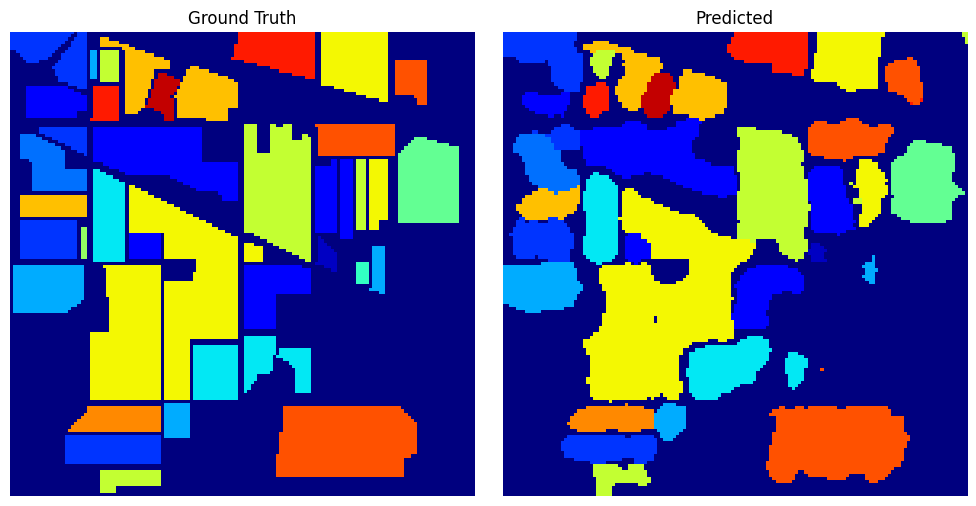

 56%|█████▌    | 10/18 [21:24<22:42, 170.36s/it, id=0.1, val_average_accuracy=0.907, val_f1=0.905, val_kappa=nan, val_loss=0.269, val_overall_accuracy=0.822]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9258025884628296
         val_f1             0.9230201244354248
        val_kappa                   nan
        val_loss            0.20691344141960144
  val_overall_accuracy      0.8458882570266724
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


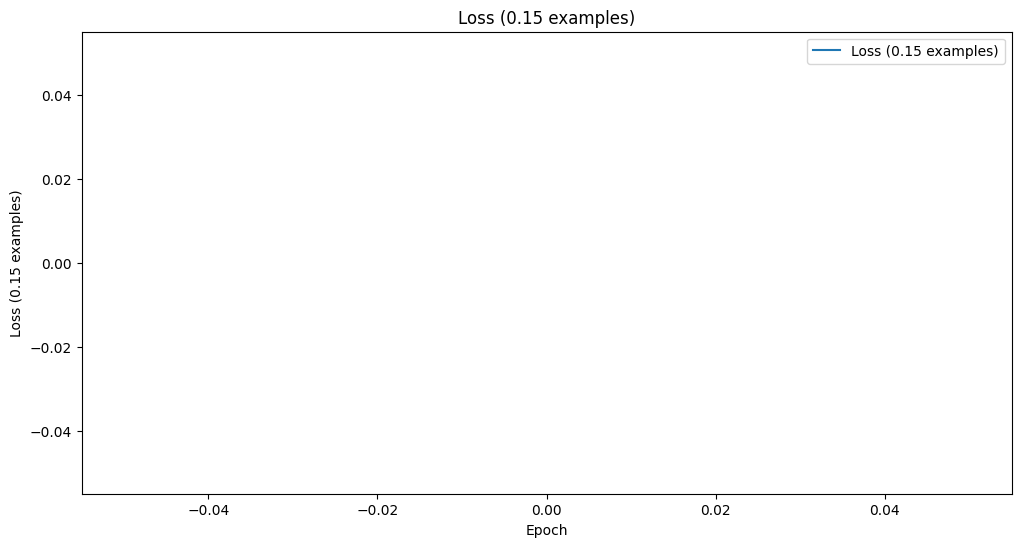

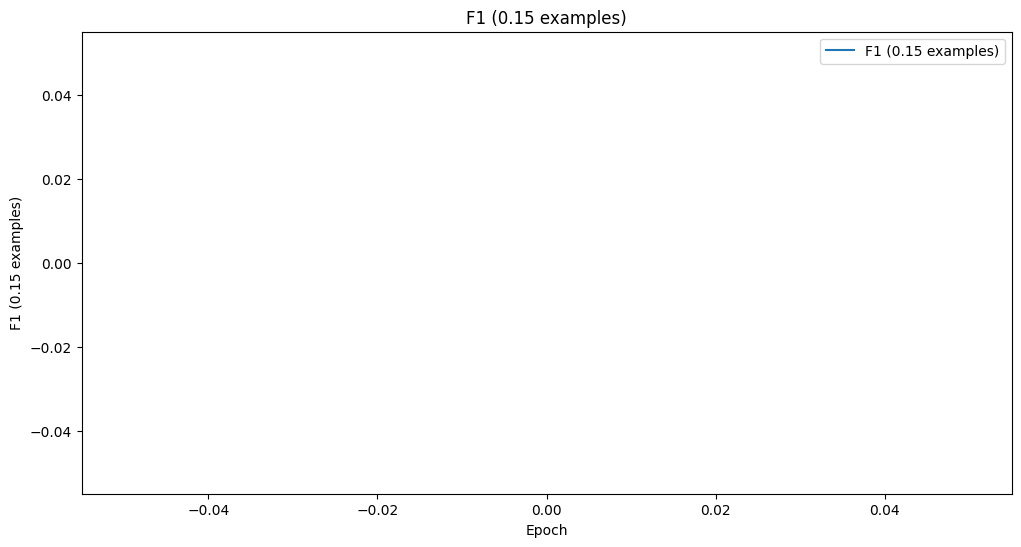

Predicting: |          | 0/? [00:00<?, ?it/s]

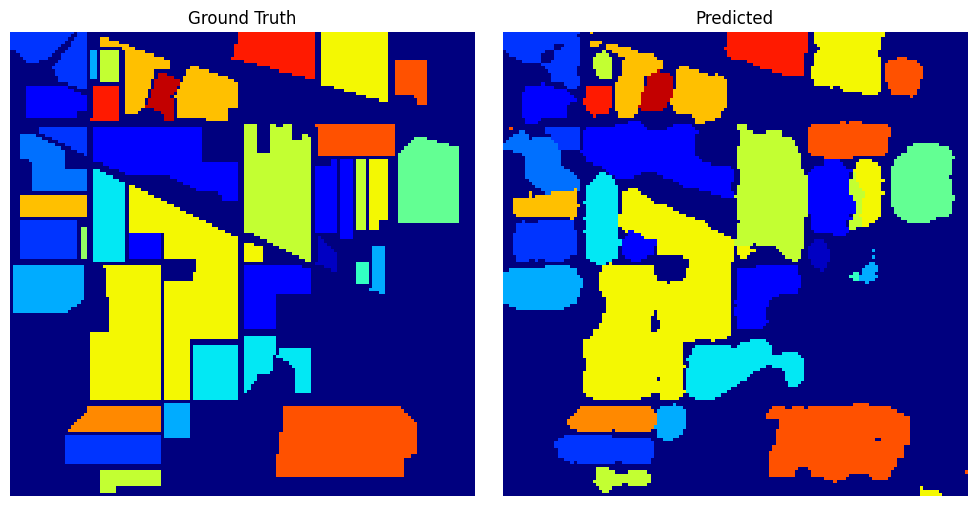

 61%|██████    | 11/18 [26:18<24:17, 208.16s/it, id=0.15, val_average_accuracy=0.926, val_f1=0.923, val_kappa=nan, val_loss=0.207, val_overall_accuracy=0.846]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9360285401344299
         val_f1             0.9355034232139587
        val_kappa                   nan
        val_loss            0.1923982948064804
  val_overall_accuracy      0.8720778822898865
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


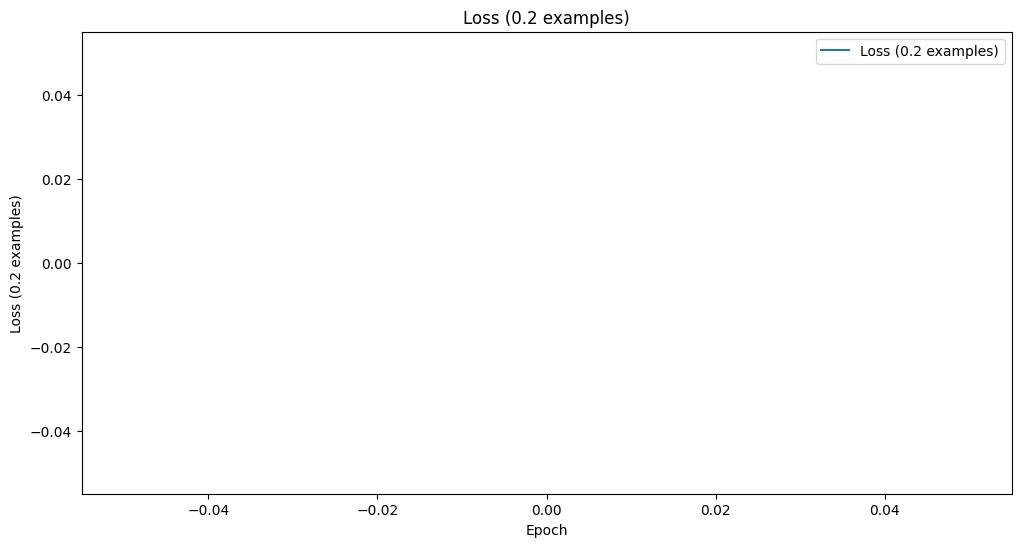

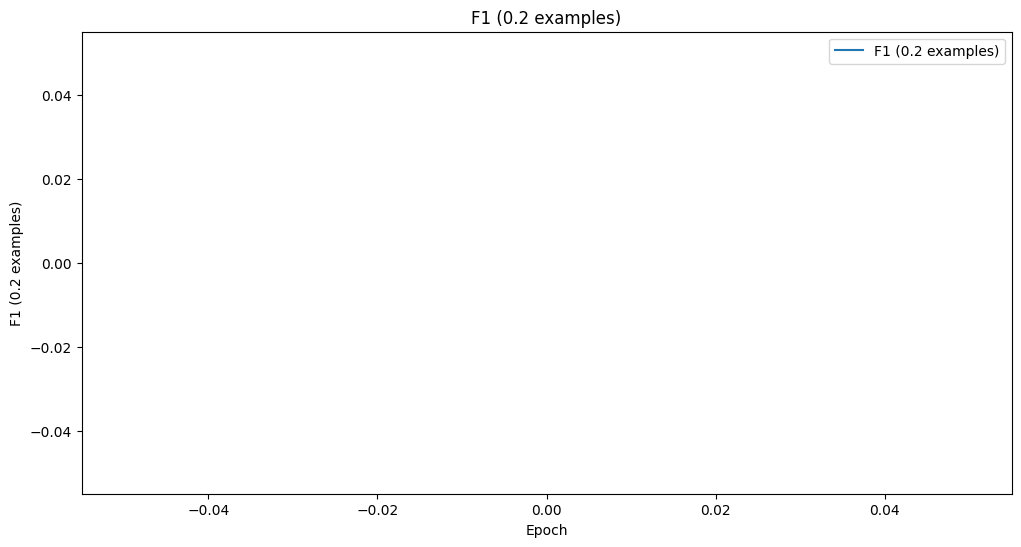

Predicting: |          | 0/? [00:00<?, ?it/s]

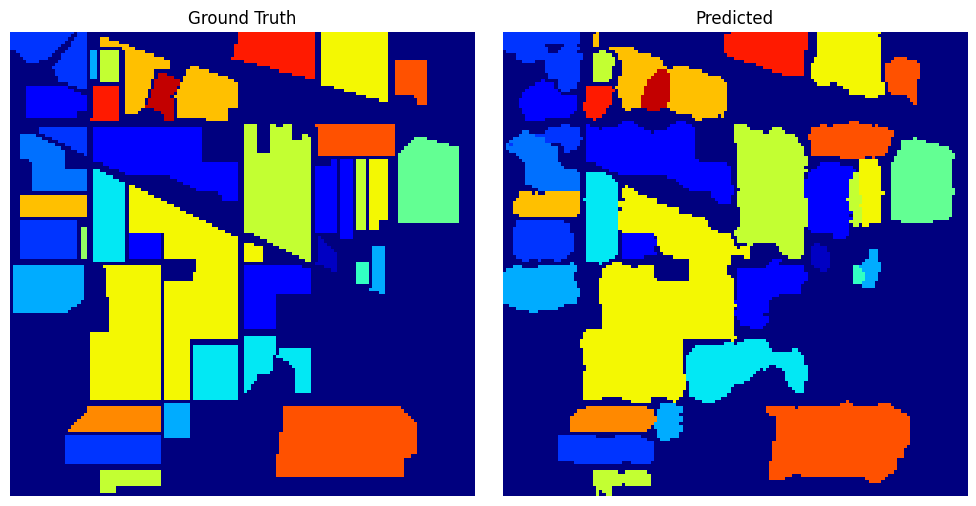

 67%|██████▋   | 12/18 [32:41<26:08, 261.46s/it, id=0.2, val_average_accuracy=0.936, val_f1=0.936, val_kappa=nan, val_loss=0.192, val_overall_accuracy=0.872] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9561949968338013
         val_f1             0.9557437896728516
        val_kappa                   nan
        val_loss            0.13011910021305084
  val_overall_accuracy      0.9055853486061096
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


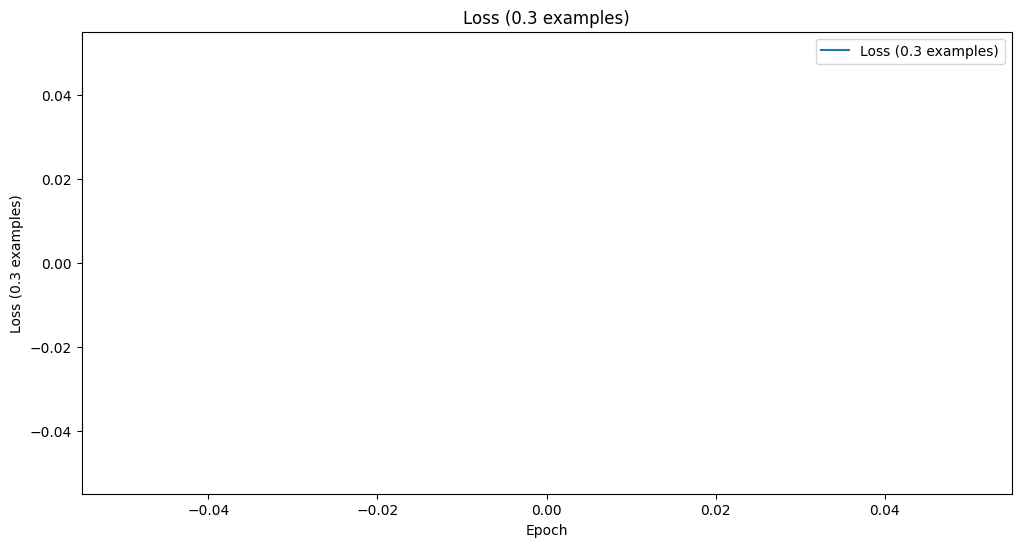

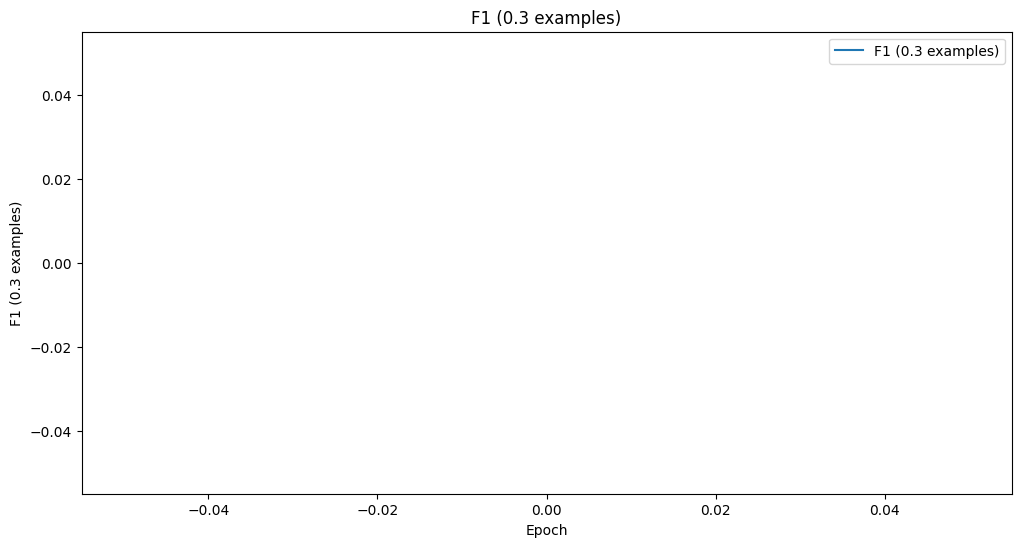

Predicting: |          | 0/? [00:00<?, ?it/s]

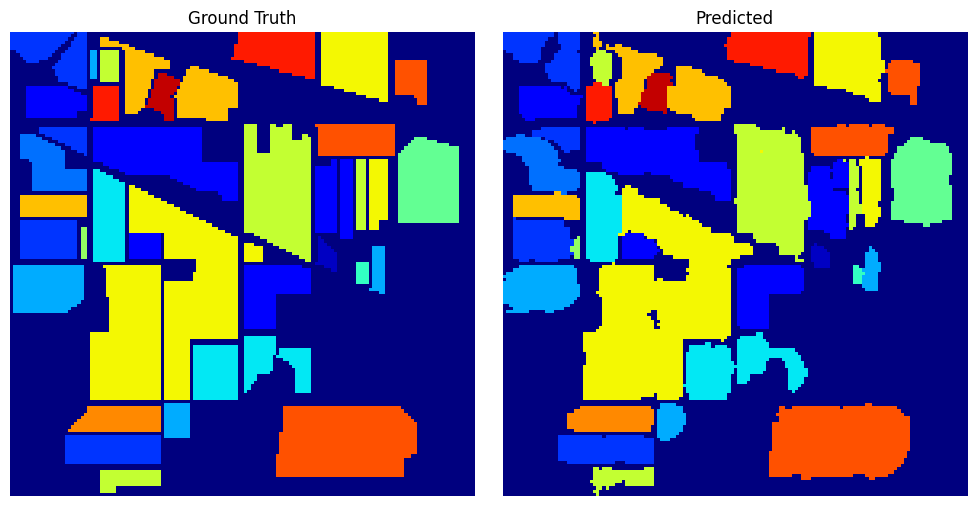

 72%|███████▏  | 13/18 [42:20<29:48, 357.66s/it, id=0.3, val_average_accuracy=0.956, val_f1=0.956, val_kappa=nan, val_loss=0.13, val_overall_accuracy=0.906] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9607134461402893
         val_f1             0.9609529972076416
        val_kappa                   nan
        val_loss            0.11335299164056778
  val_overall_accuracy      0.9141274094581604
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


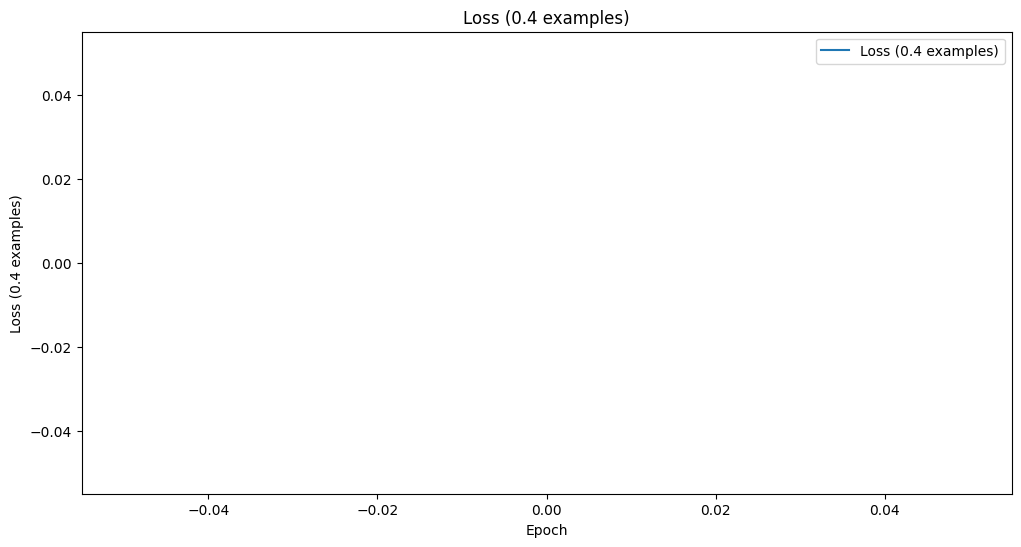

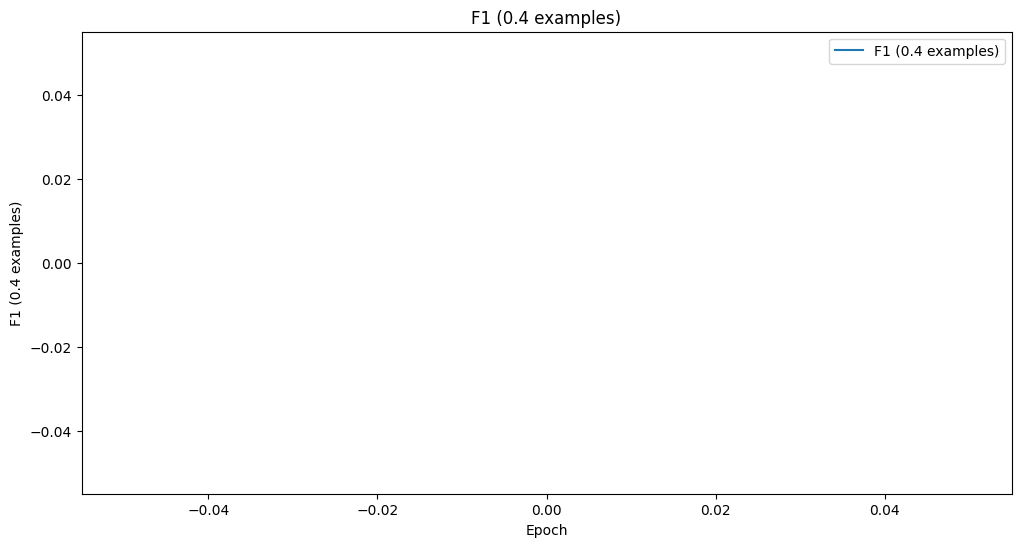

Predicting: |          | 0/? [00:00<?, ?it/s]

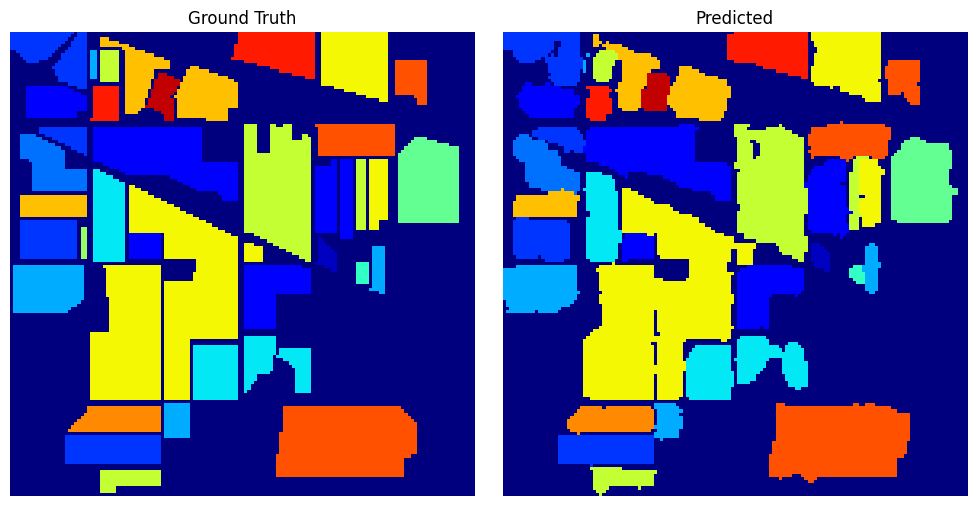

 78%|███████▊  | 14/18 [55:01<31:57, 479.37s/it, id=0.4, val_average_accuracy=0.961, val_f1=0.961, val_kappa=nan, val_loss=0.113, val_overall_accuracy=0.914]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9721283912658691
         val_f1             0.9727269411087036
        val_kappa                   nan
        val_loss            0.0829477459192276
  val_overall_accuracy      0.9388508796691895
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


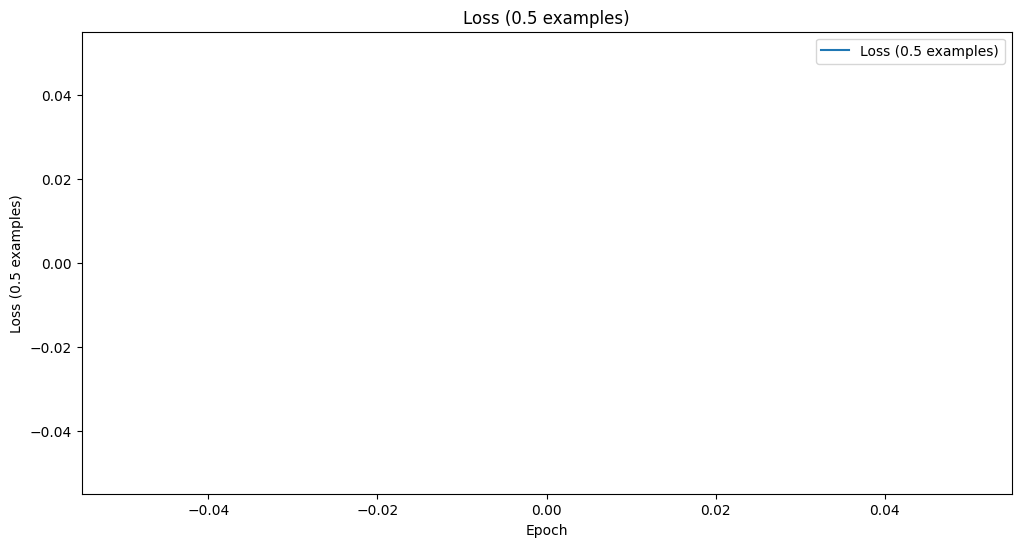

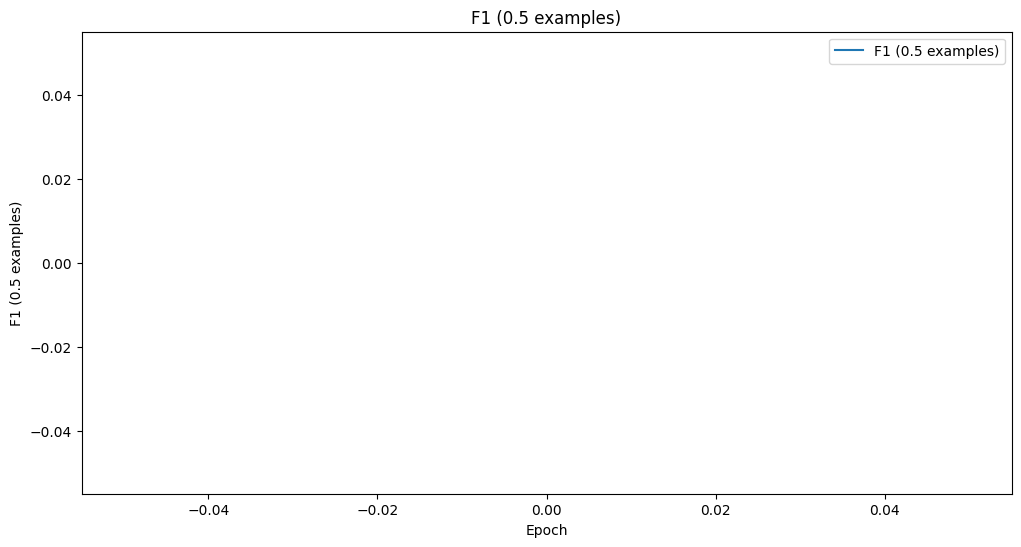

Predicting: |          | 0/? [00:00<?, ?it/s]

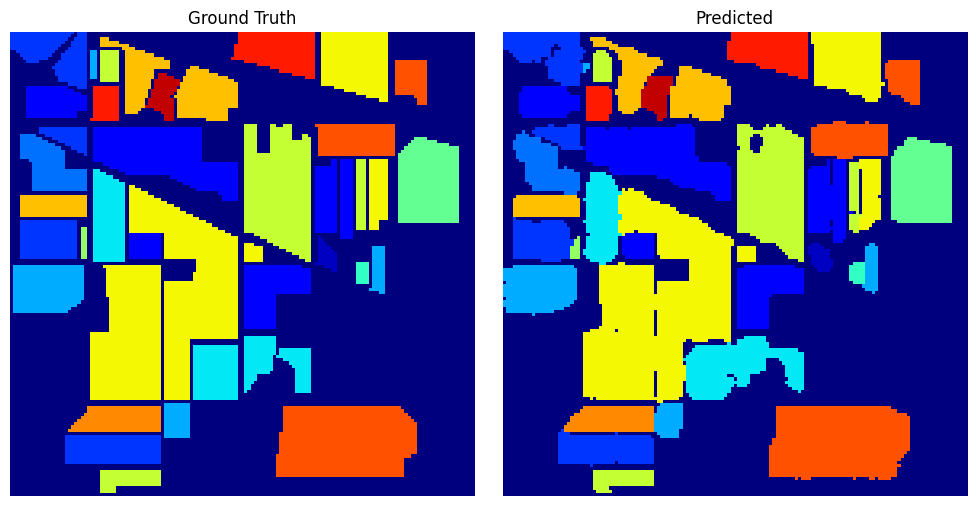

 83%|████████▎ | 15/18 [1:10:43<30:56, 618.81s/it, id=0.5, val_average_accuracy=0.972, val_f1=0.973, val_kappa=nan, val_loss=0.0829, val_overall_accuracy=0.939]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccur

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9806896448135376
         val_f1             0.9807169437408447
        val_kappa                   nan
        val_loss            0.06276184320449829
  val_overall_accuracy      0.9573227763175964
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


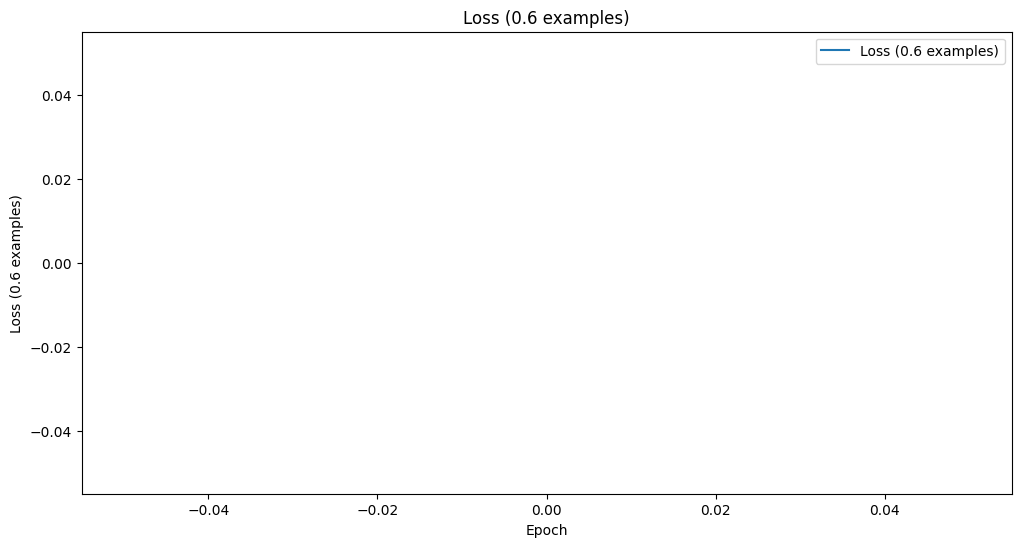

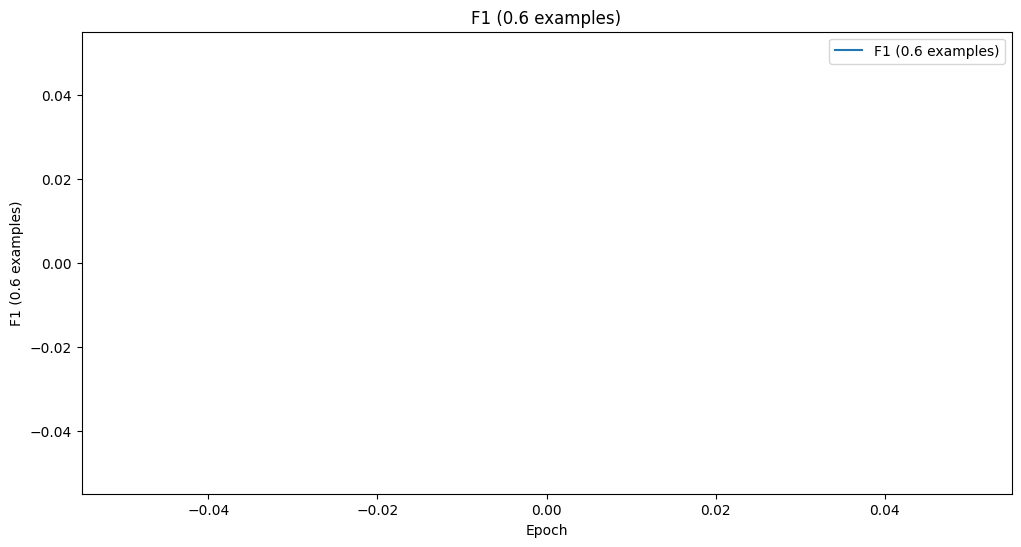

Predicting: |          | 0/? [00:00<?, ?it/s]

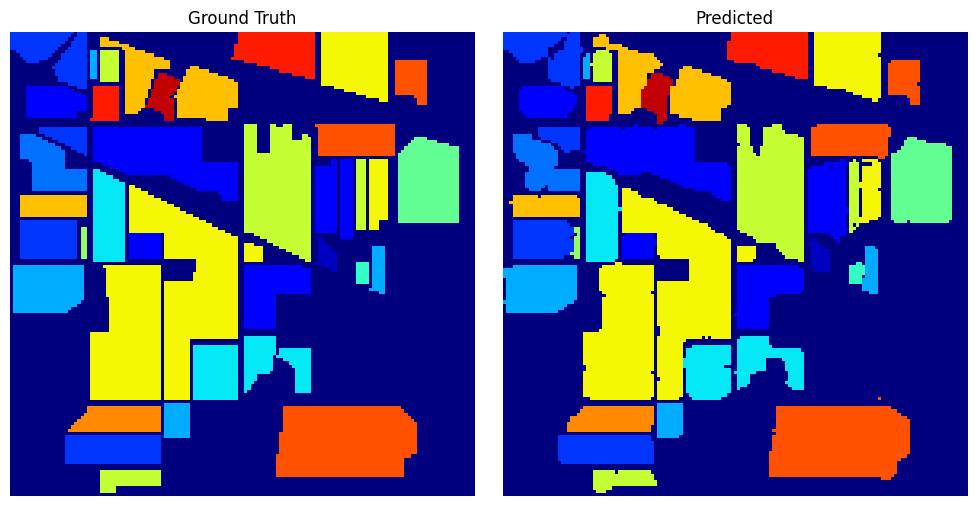

 89%|████████▉ | 16/18 [1:28:55<25:22, 761.42s/it, id=0.6, val_average_accuracy=0.981, val_f1=0.981, val_kappa=nan, val_loss=0.0628, val_overall_accuracy=0.957]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccur

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9848275780677795
         val_f1             0.9847556948661804
        val_kappa                   nan
        val_loss            0.04349309206008911
  val_overall_accuracy       0.965190052986145
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


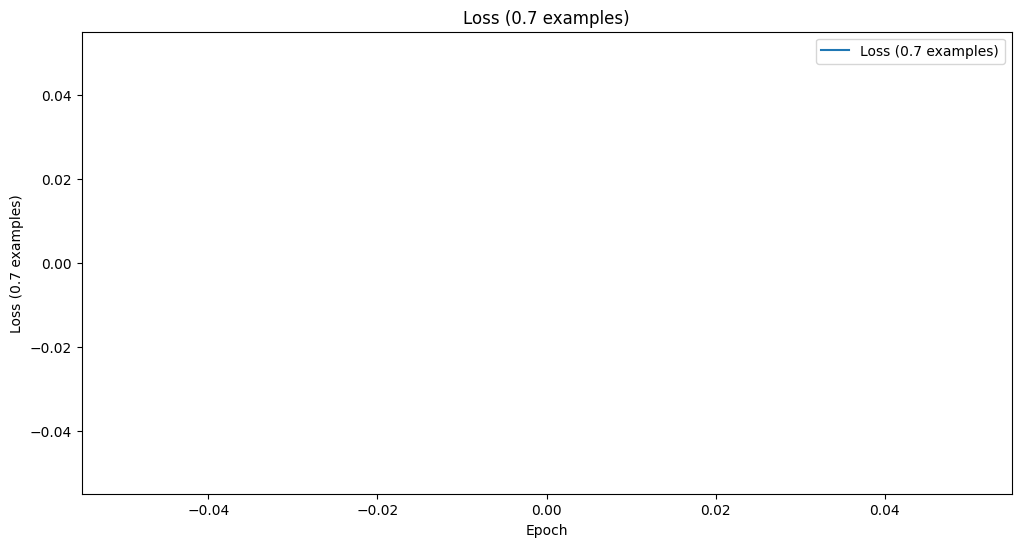

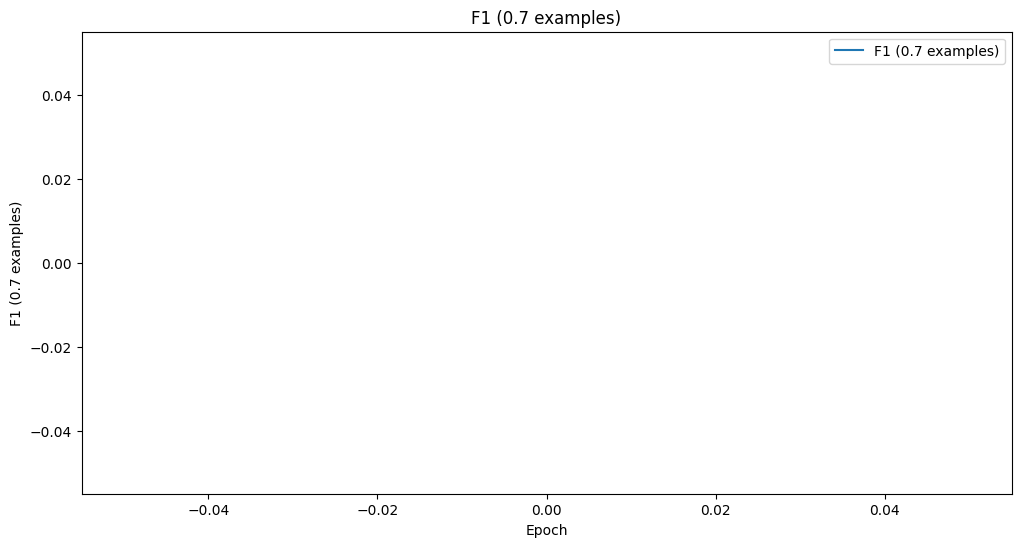

Predicting: |          | 0/? [00:00<?, ?it/s]

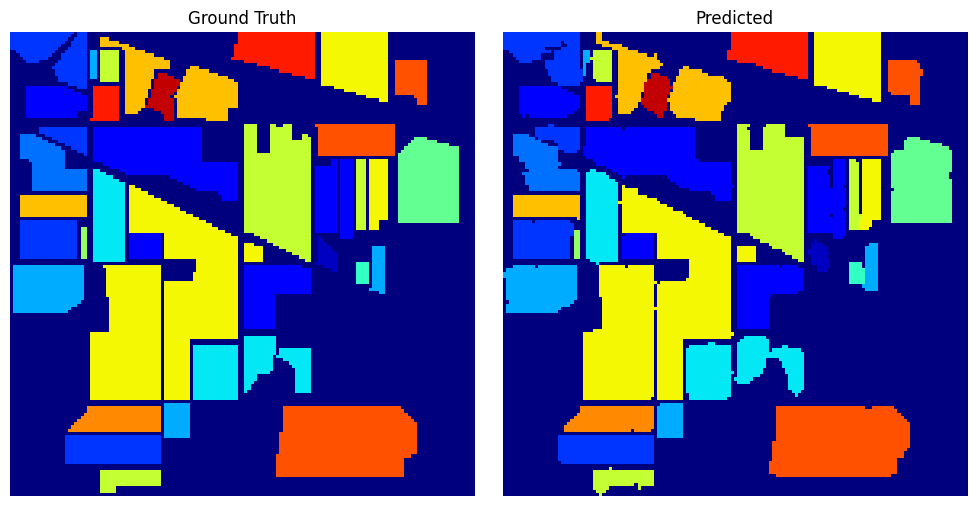

 94%|█████████▍| 17/18 [1:49:56<15:11, 911.51s/it, id=0.7, val_average_accuracy=0.985, val_f1=0.985, val_kappa=nan, val_loss=0.0435, val_overall_accuracy=0.965]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccur

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9892984628677368
         val_f1             0.9892408847808838
        val_kappa                   nan
        val_loss            0.03304096311330795
  val_overall_accuracy      0.9749787449836731
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


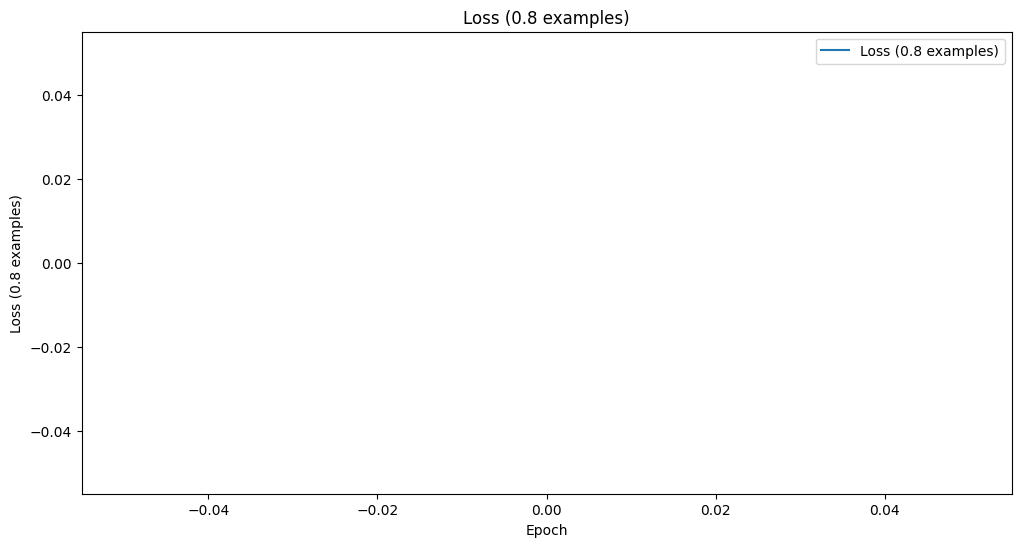

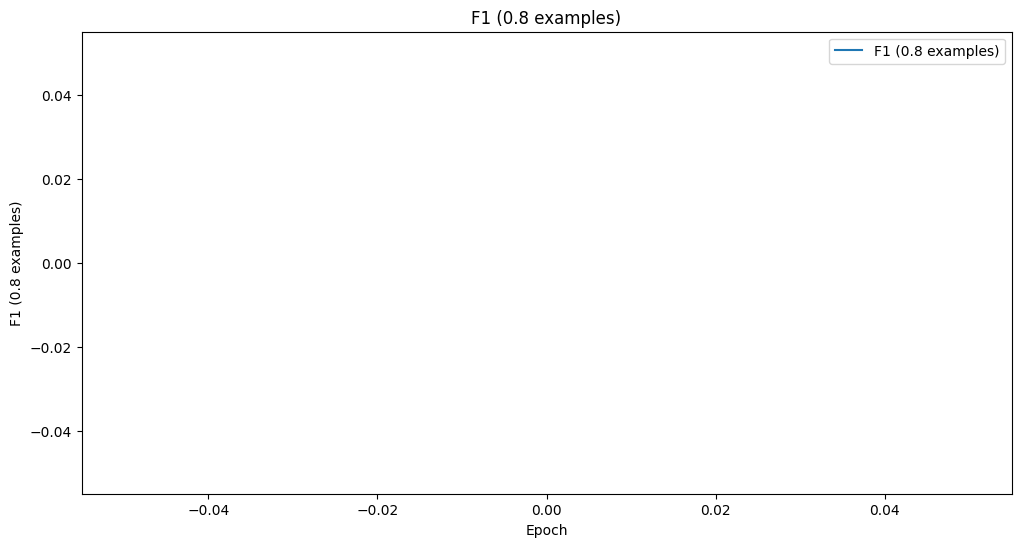

Predicting: |          | 0/? [00:00<?, ?it/s]

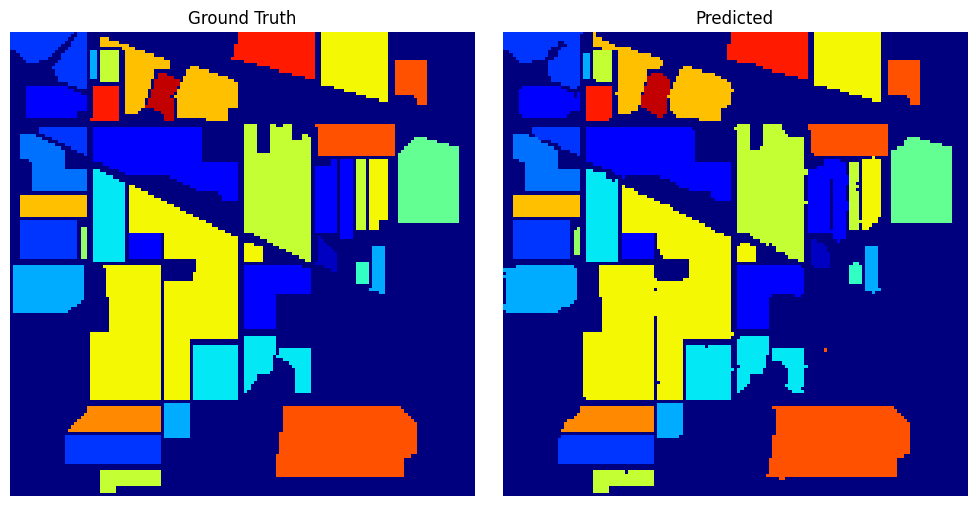

100%|██████████| 18/18 [2:56:00<00:00, 586.70s/it, id=0.8, val_average_accuracy=0.989, val_f1=0.989, val_kappa=nan, val_loss=0.033, val_overall_accuracy=0.975] 


In [22]:
stratified_random_sampled_search = RepresentativeDataPointsSearch(
    RandomSampleDataPointsSearch(True), log_dir, f"random-sample-stratified"
)

feedback = stratified_random_sampled_search.run()

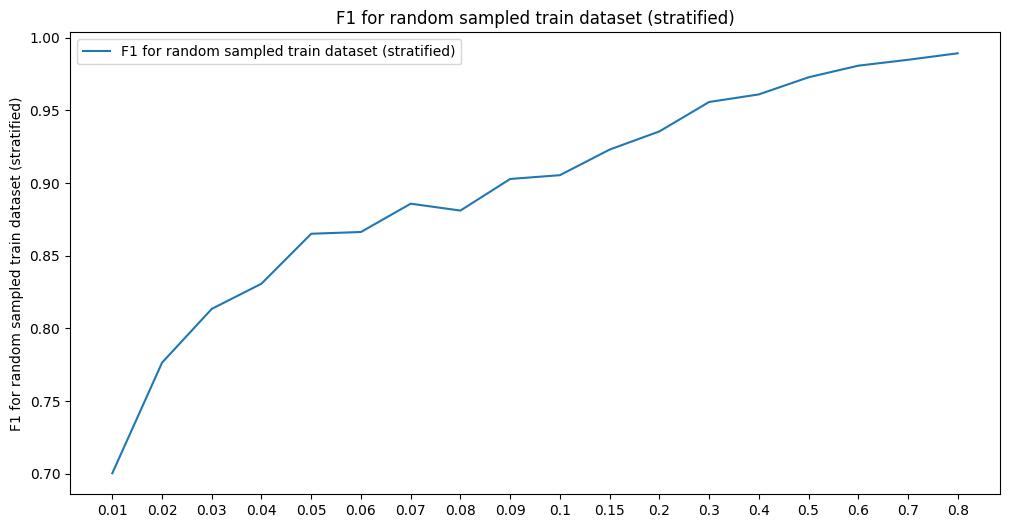

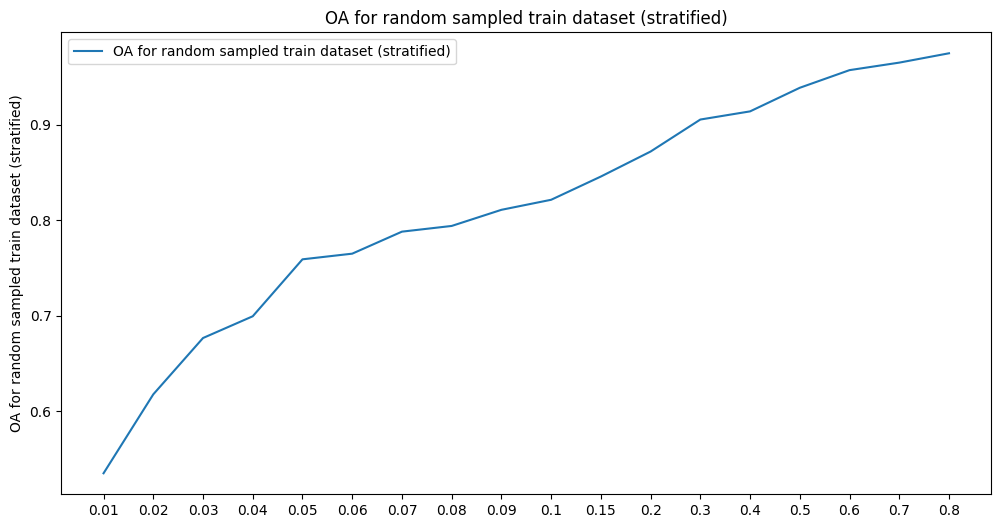

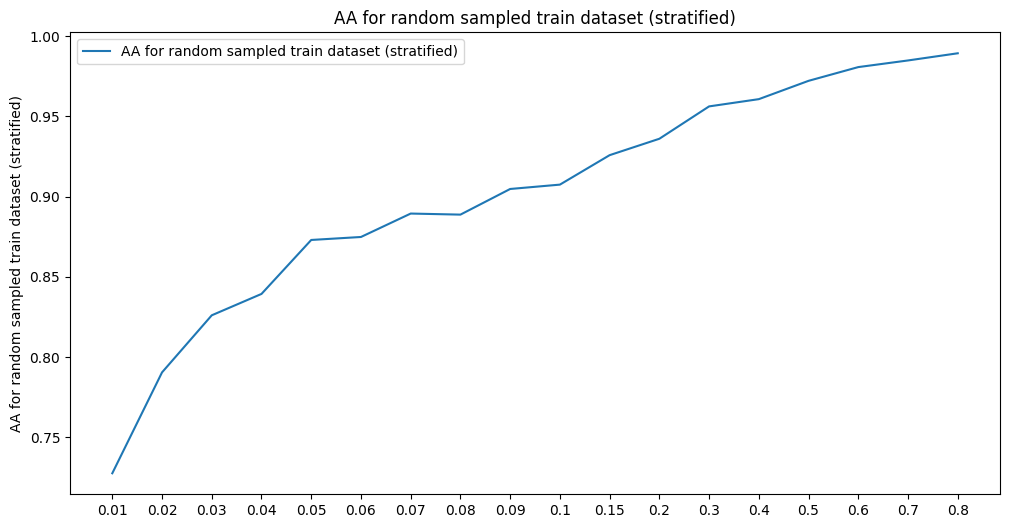

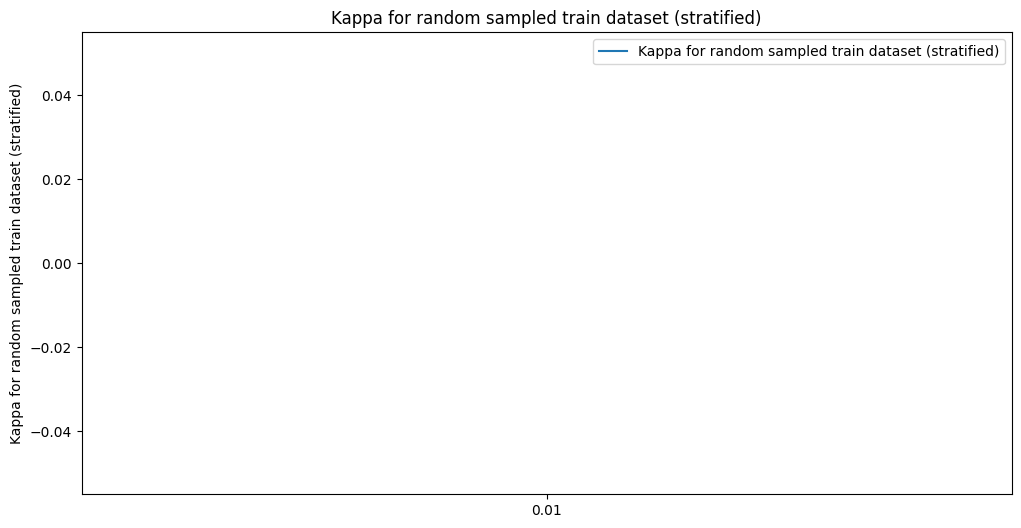

In [23]:
ids = [it.id for it in feedback]
stratified_random_f1s = [it.score["val_f1"] for it in feedback]
stratified_random_oas = [it.score["val_overall_accuracy"] for it in feedback]
stratified_random_aas = [it.score["val_average_accuracy"] for it in feedback]
stratified_random_kappas = [it.score["val_kappa"] for it in feedback]

plot_generic(ids, stratified_random_f1s, desc=f"F1 for random sampled train dataset (stratified)")
plot_generic(
    ids, stratified_random_oas, desc=f"OA for random sampled train dataset (stratified)"
)
plot_generic(
    ids, stratified_random_aas, desc=f"AA for random sampled train dataset (stratified)"
)
plot_generic(
    ids,
    stratified_random_kappas,
    desc=f"Kappa for random sampled train dataset (stratified)",
)

5. Train model on a random sampled dataset (not stratified).

  0%|          | 0/18 [00:00<?, ?it/s]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   | 0      | train
4 | average_accuracy | MulticlassAccuracy   | 0      | train
5 | kappa            | MulticlassCohen

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7384542226791382
         val_f1             0.7123171091079712
        val_kappa                   nan
        val_loss            0.8899217844009399
  val_overall_accuracy      0.5555318593978882
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


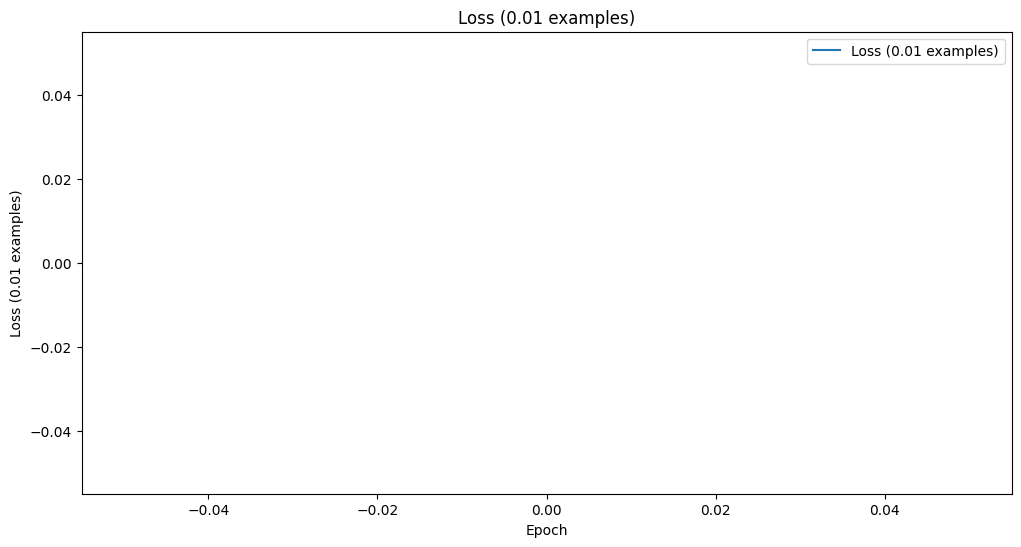

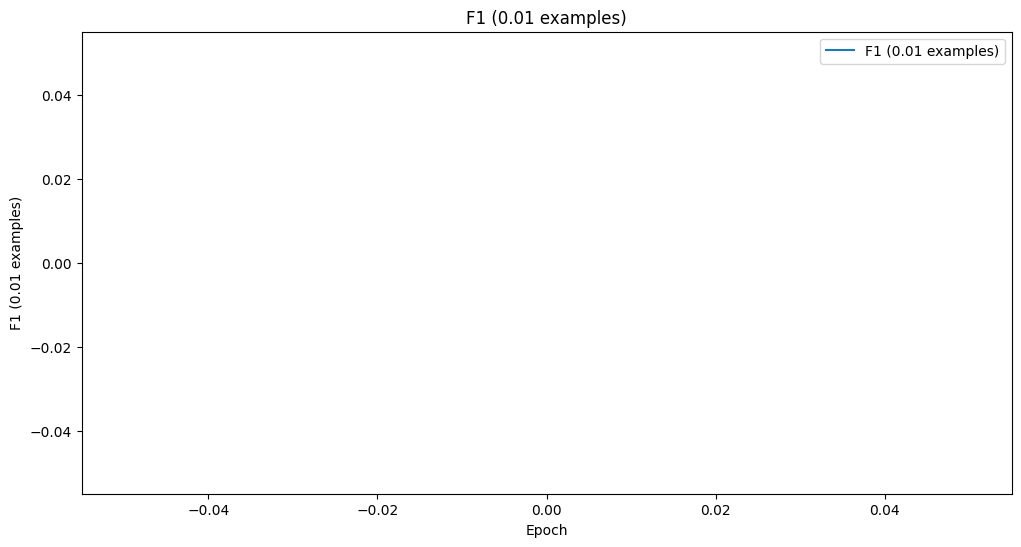

Predicting: |          | 0/? [00:00<?, ?it/s]

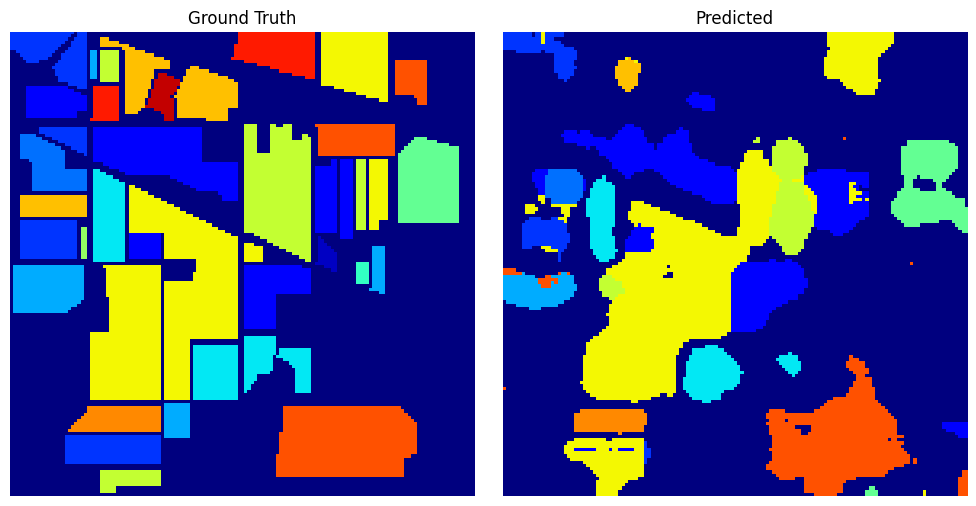

  6%|▌         | 1/18 [04:20<1:13:50, 260.63s/it, id=0.01, val_average_accuracy=0.738, val_f1=0.712, val_kappa=nan, val_loss=0.89, val_overall_accuracy=0.556]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7772651314735413
         val_f1              0.761622965335846
        val_kappa                   nan
        val_loss            0.6398462057113647
  val_overall_accuracy      0.6042734384536743
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


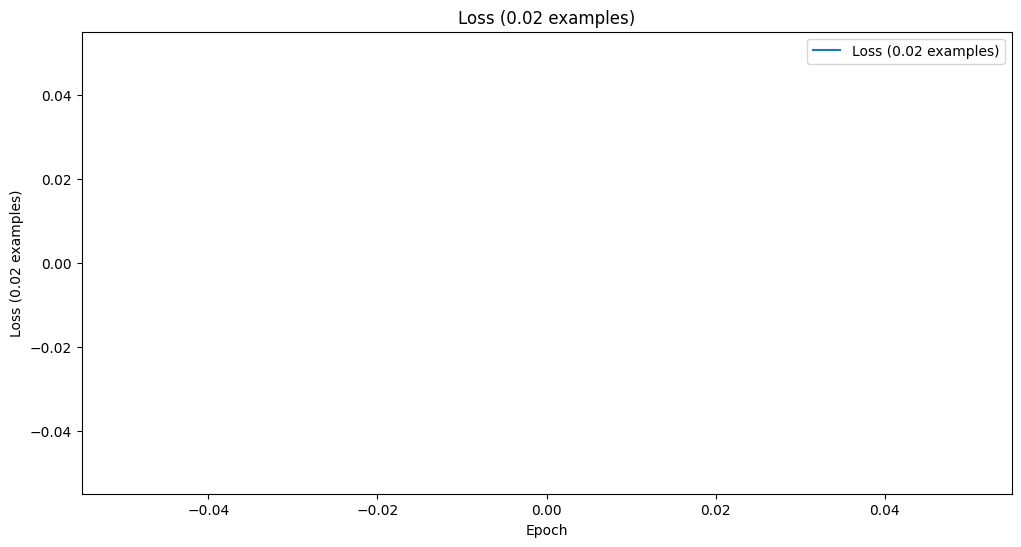

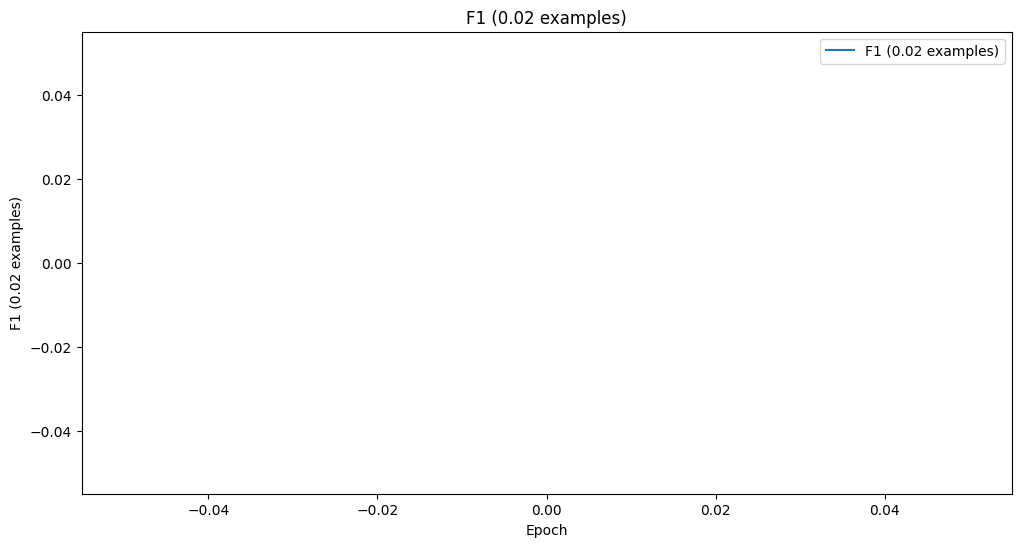

Predicting: |          | 0/? [00:00<?, ?it/s]

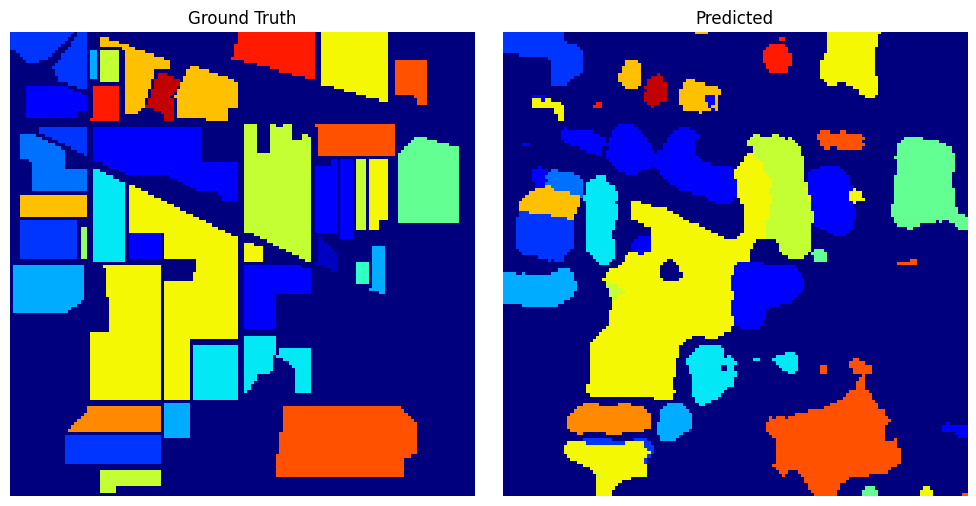

 11%|█         | 2/18 [23:00<3:24:18, 766.13s/it, id=0.02, val_average_accuracy=0.777, val_f1=0.762, val_kappa=nan, val_loss=0.64, val_overall_accuracy=0.604]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8218311667442322
         val_f1             0.8105465769767761
        val_kappa                   nan
        val_loss             0.512901246547699
  val_overall_accuracy      0.6557446122169495
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


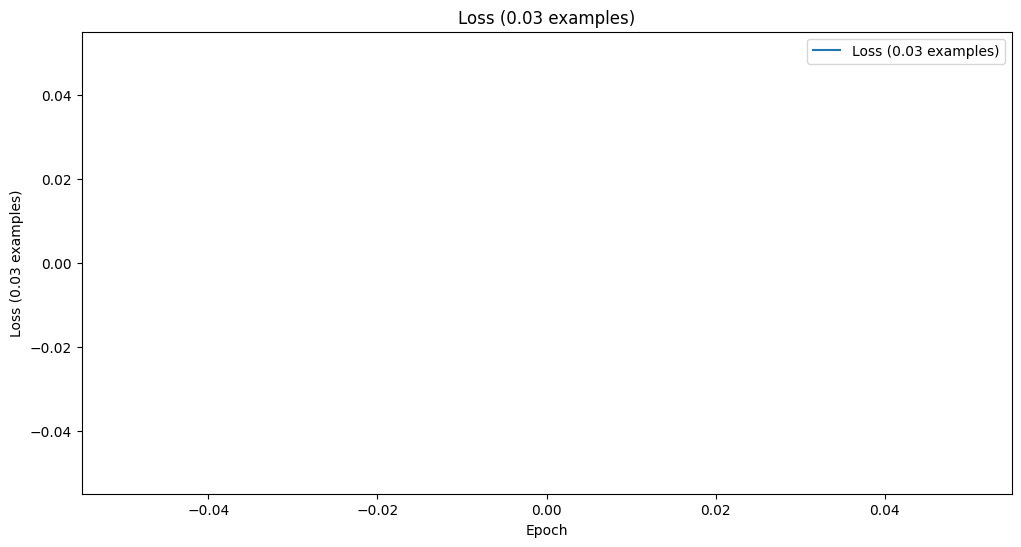

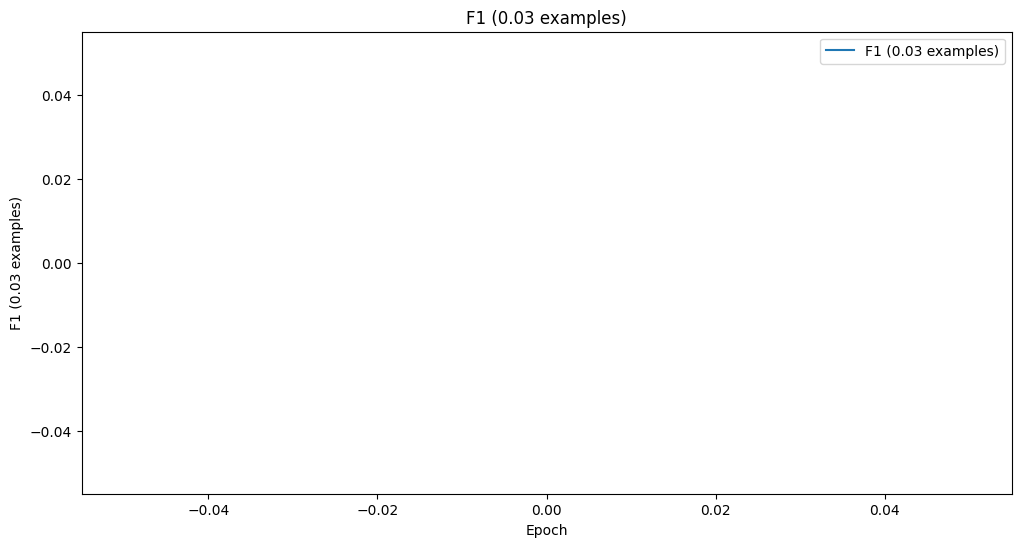

Predicting: |          | 0/? [00:00<?, ?it/s]

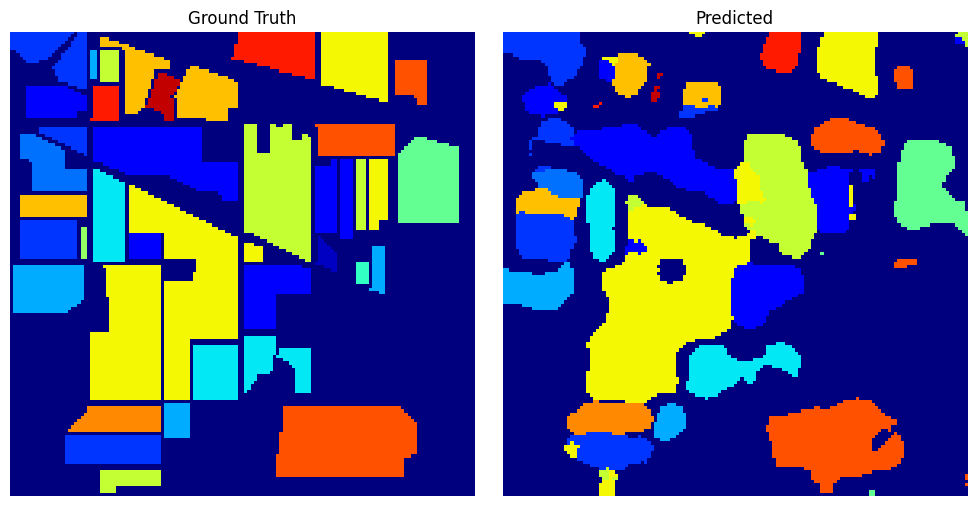

 17%|█▋        | 3/18 [24:21<1:53:19, 453.33s/it, id=0.03, val_average_accuracy=0.822, val_f1=0.811, val_kappa=nan, val_loss=0.513, val_overall_accuracy=0.656]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8312485218048096
         val_f1             0.8231320381164551
        val_kappa                   nan
        val_loss            0.48823192715644836
  val_overall_accuracy      0.6771851778030396
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


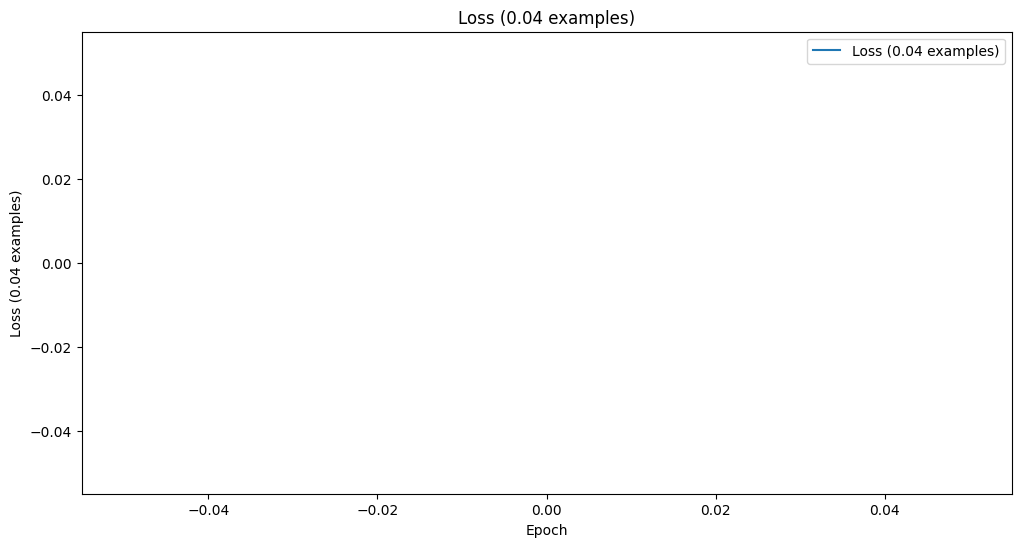

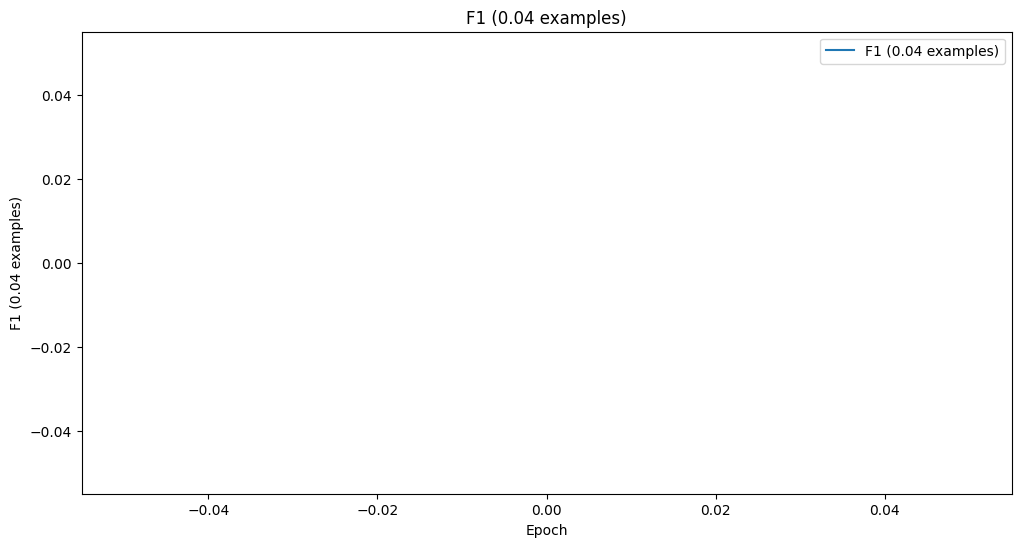

Predicting: |          | 0/? [00:00<?, ?it/s]

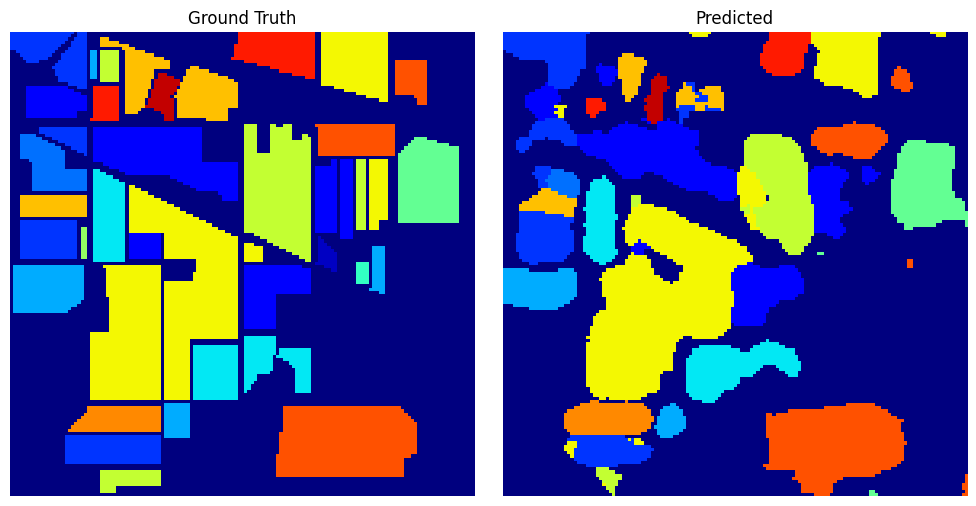

 22%|██▏       | 4/18 [33:24<1:54:01, 488.65s/it, id=0.04, val_average_accuracy=0.831, val_f1=0.823, val_kappa=nan, val_loss=0.488, val_overall_accuracy=0.677]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8588347434997559
         val_f1             0.8522512316703796
        val_kappa                   nan
        val_loss            0.40537744760513306
  val_overall_accuracy      0.7202237844467163
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


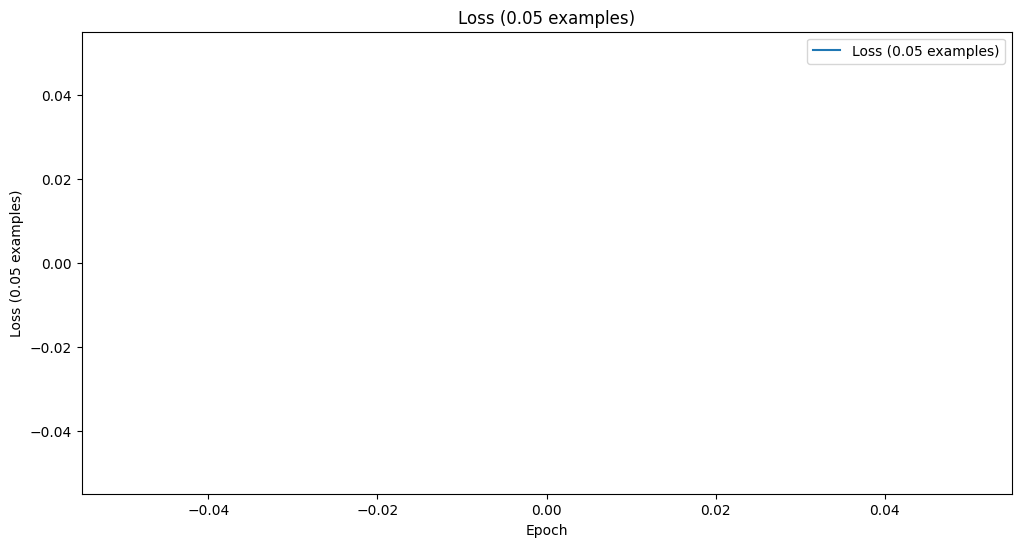

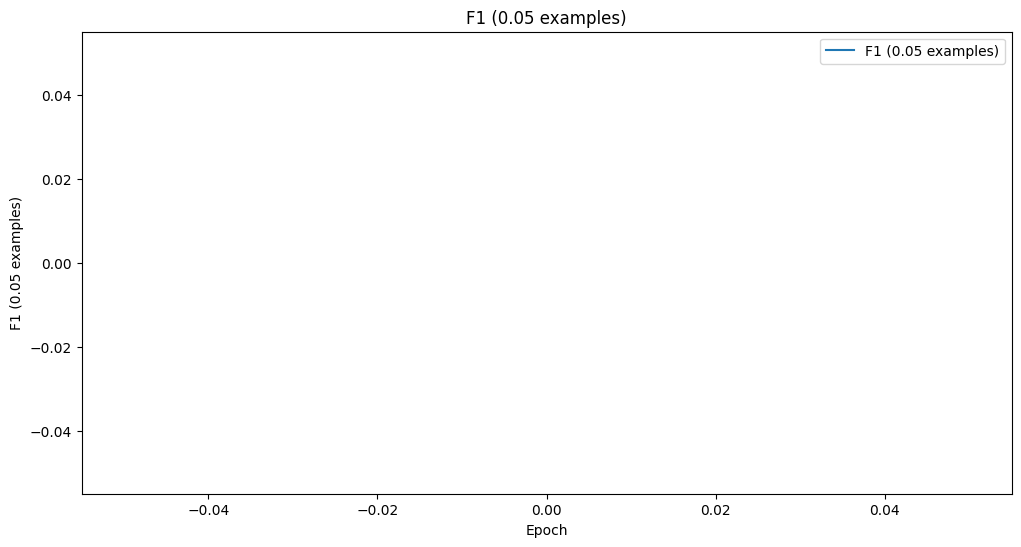

Predicting: |          | 0/? [00:00<?, ?it/s]

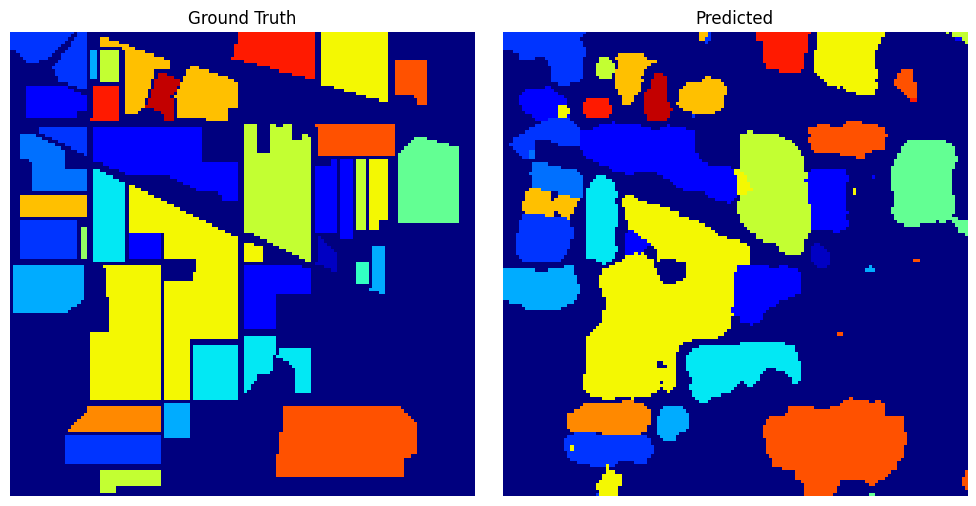

 28%|██▊       | 5/18 [35:22<1:16:53, 354.92s/it, id=0.05, val_average_accuracy=0.859, val_f1=0.852, val_kappa=nan, val_loss=0.405, val_overall_accuracy=0.72] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8758144974708557
         val_f1             0.8722267150878906
        val_kappa                   nan
        val_loss            0.37353208661079407
  val_overall_accuracy      0.7605461478233337
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


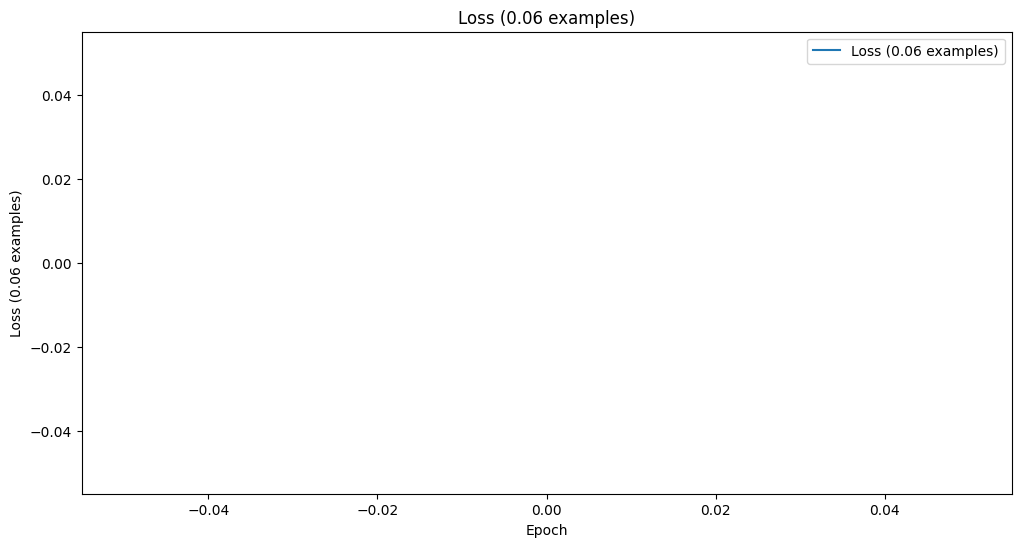

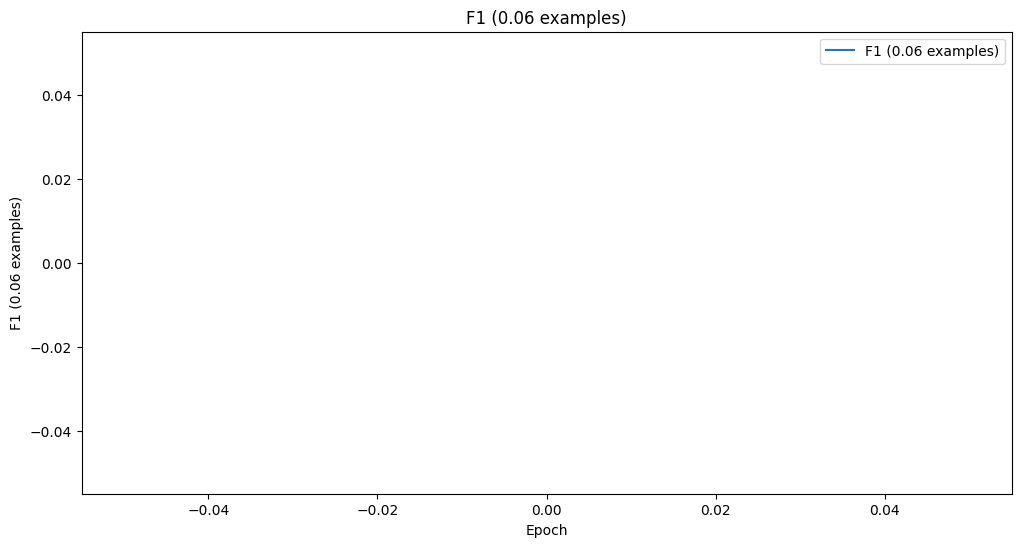

Predicting: |          | 0/? [00:00<?, ?it/s]

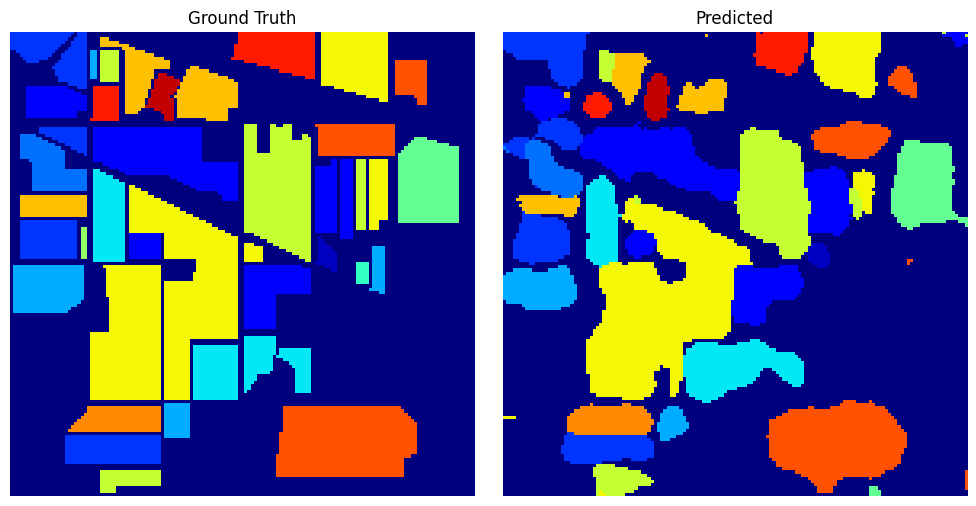

 33%|███▎      | 6/18 [37:39<56:09, 280.79s/it, id=0.06, val_average_accuracy=0.876, val_f1=0.872, val_kappa=nan, val_loss=0.374, val_overall_accuracy=0.761]  You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8902735114097595
         val_f1             0.8860108852386475
        val_kappa                   nan
        val_loss            0.3219548463821411
  val_overall_accuracy      0.7855178117752075
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


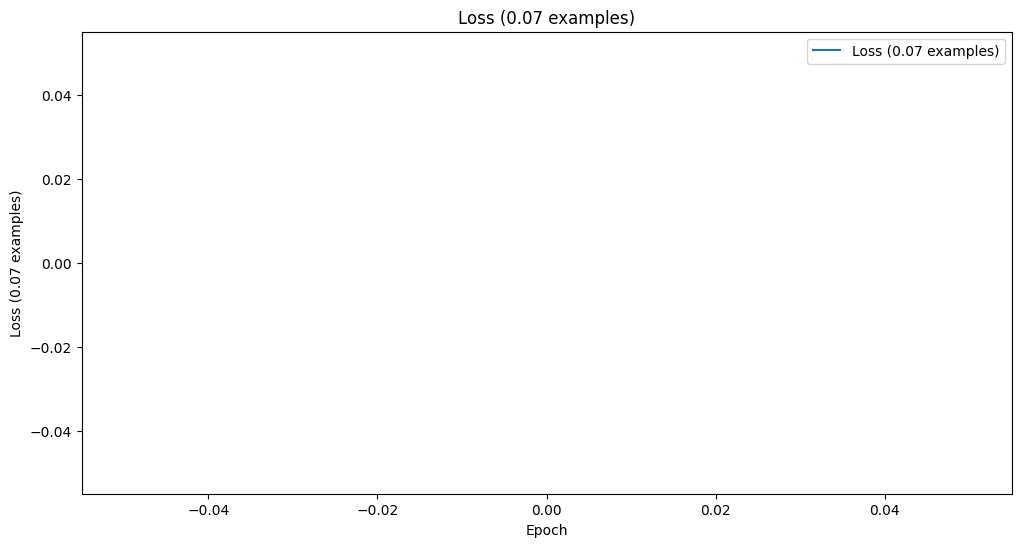

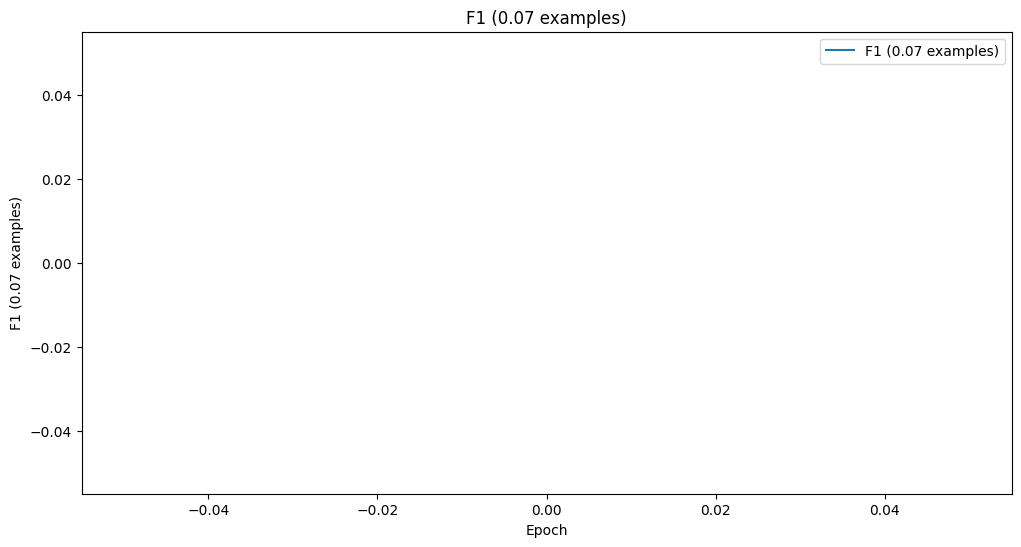

Predicting: |          | 0/? [00:00<?, ?it/s]

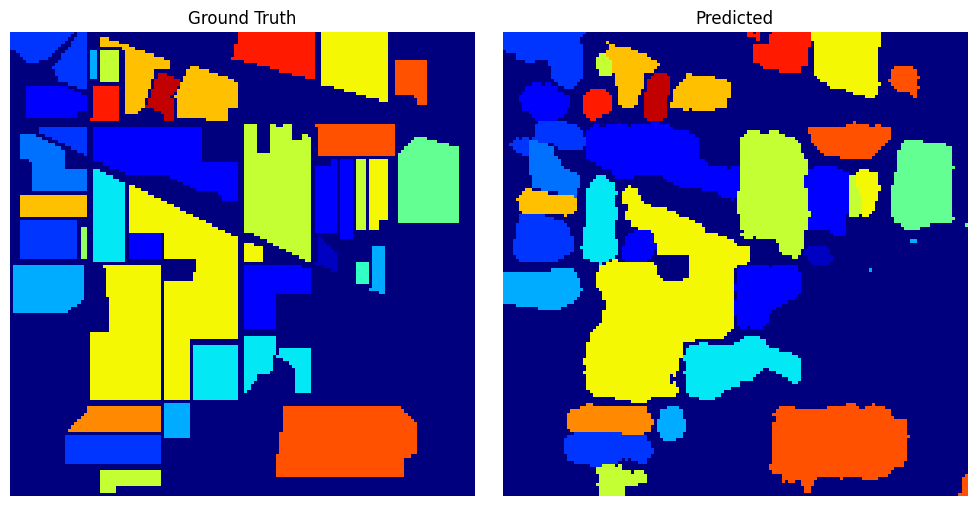

 39%|███▉      | 7/18 [40:18<44:13, 241.21s/it, id=0.07, val_average_accuracy=0.89, val_f1=0.886, val_kappa=nan, val_loss=0.322, val_overall_accuracy=0.786] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.895743191242218
         val_f1             0.8928017020225525
        val_kappa                   nan
        val_loss            0.3003914952278137
  val_overall_accuracy      0.8002044558525085
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


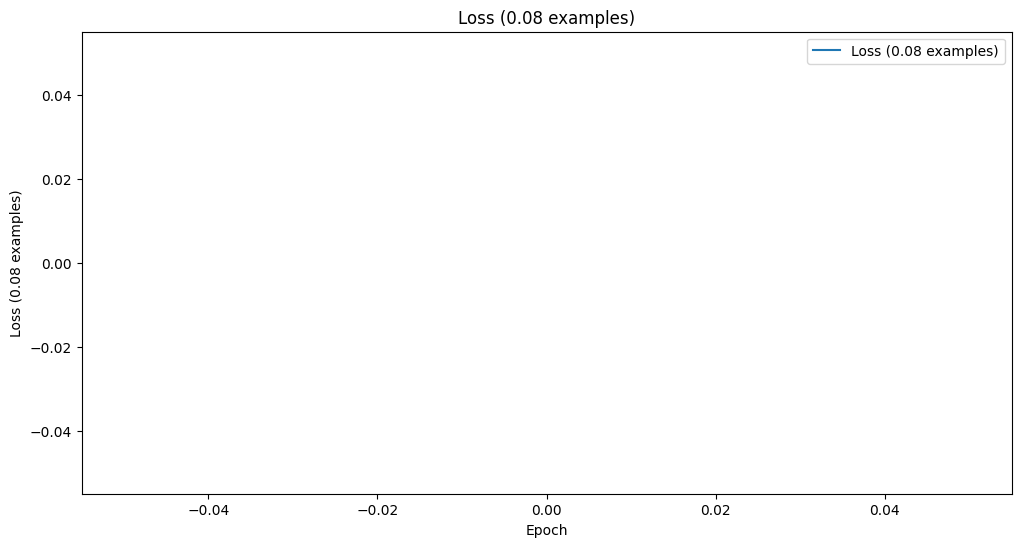

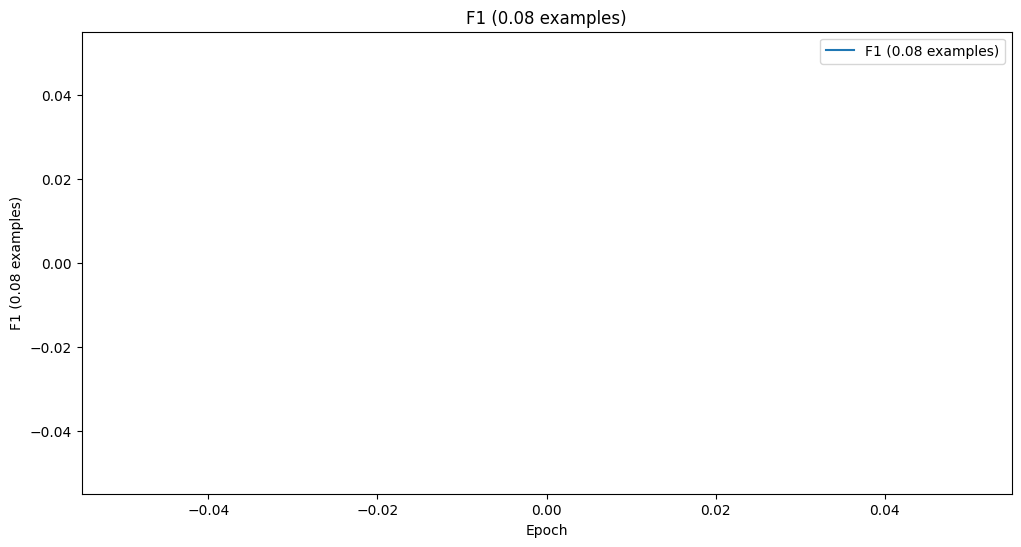

Predicting: |          | 0/? [00:00<?, ?it/s]

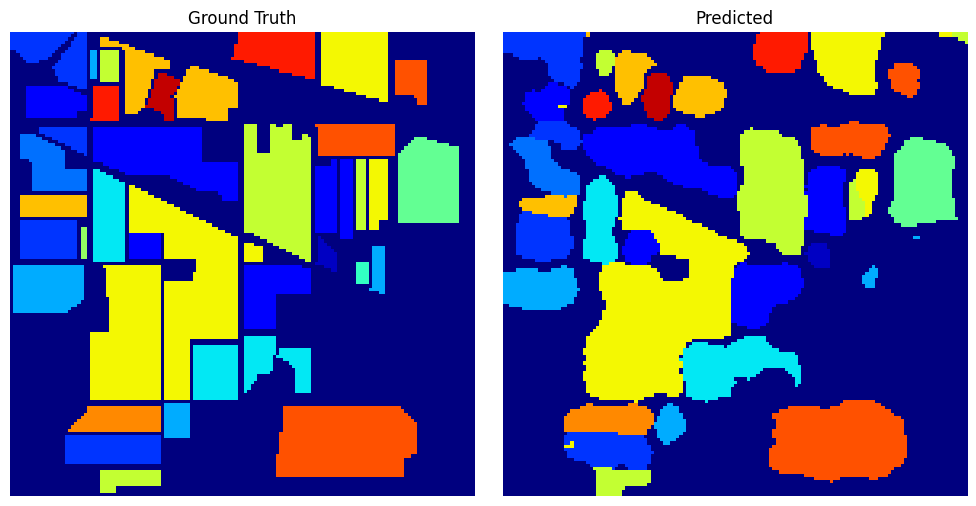

 44%|████▍     | 8/18 [50:18<59:11, 355.20s/it, id=0.08, val_average_accuracy=0.896, val_f1=0.893, val_kappa=nan, val_loss=0.3, val_overall_accuracy=0.8]   You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9002140164375305
         val_f1             0.8972183465957642
        val_kappa                   nan
        val_loss            0.27016034722328186
  val_overall_accuracy      0.8105176091194153
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


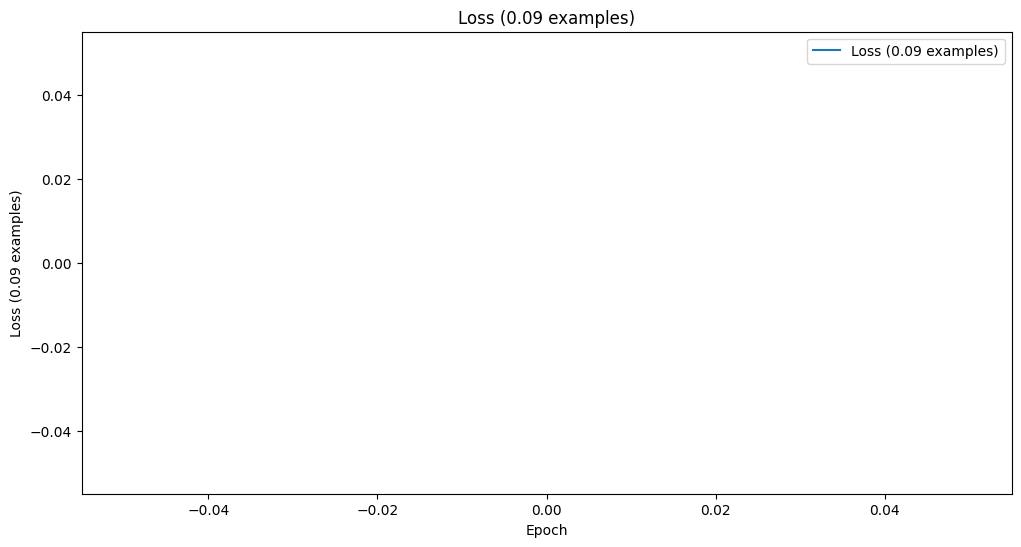

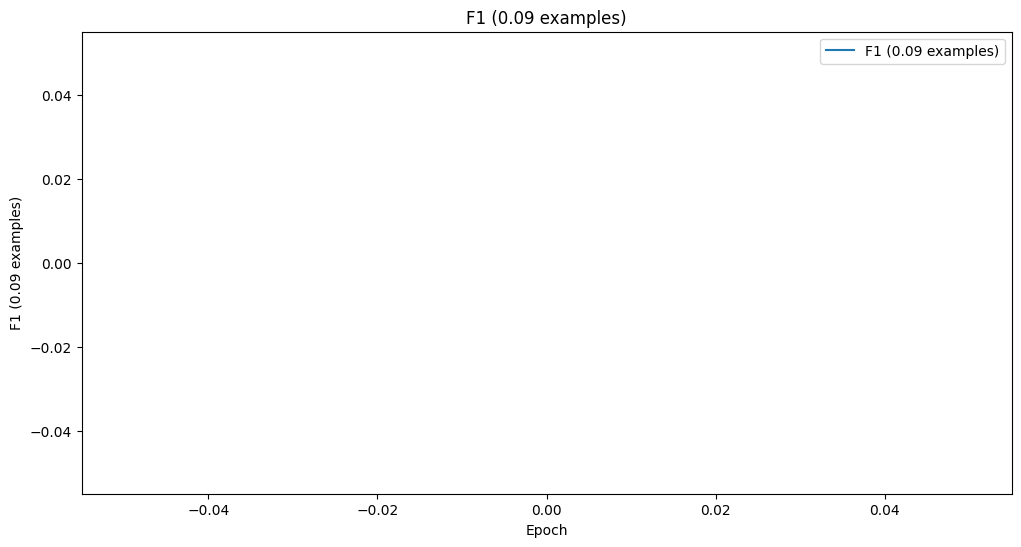

Predicting: |          | 0/? [00:00<?, ?it/s]

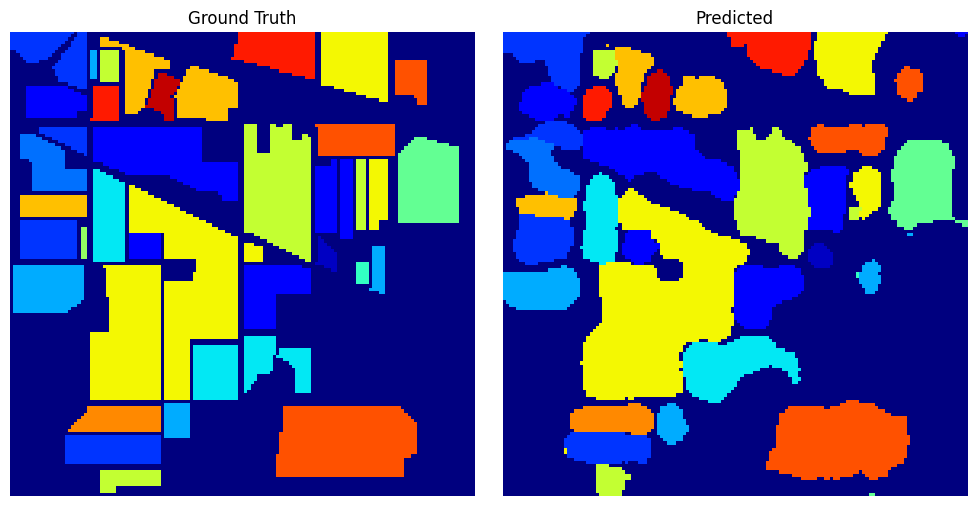

 50%|█████     | 9/18 [57:34<57:04, 380.46s/it, id=0.09, val_average_accuracy=0.9, val_f1=0.897, val_kappa=nan, val_loss=0.27, val_overall_accuracy=0.811]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9038763642311096
         val_f1             0.9017601013183594
        val_kappa                   nan
        val_loss             0.261255145072937
  val_overall_accuracy      0.8158025145530701
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


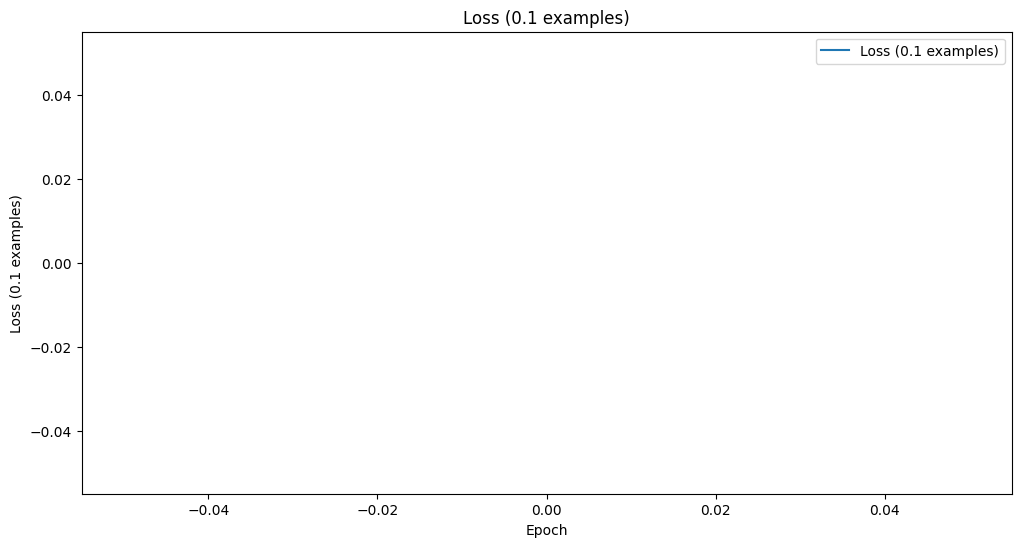

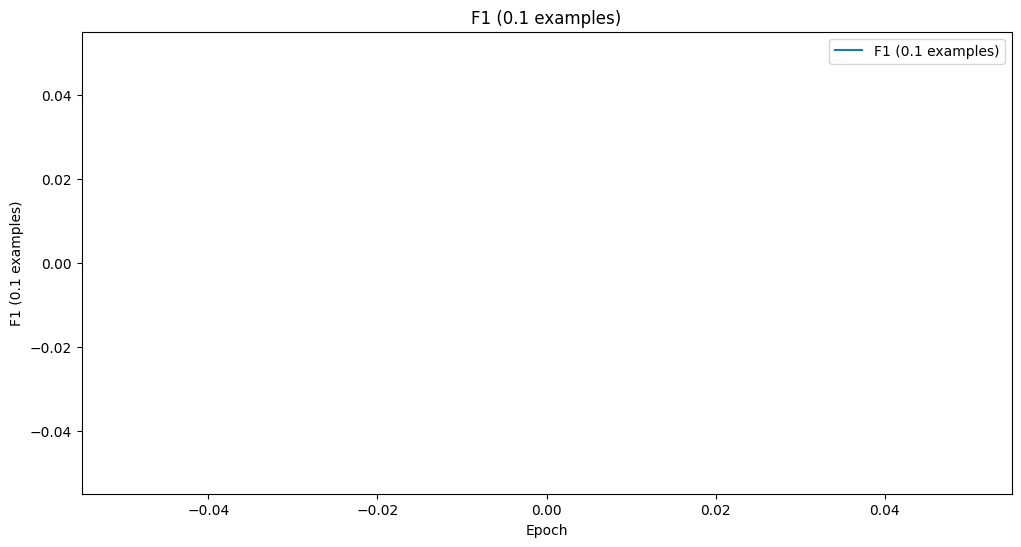

Predicting: |          | 0/? [00:00<?, ?it/s]

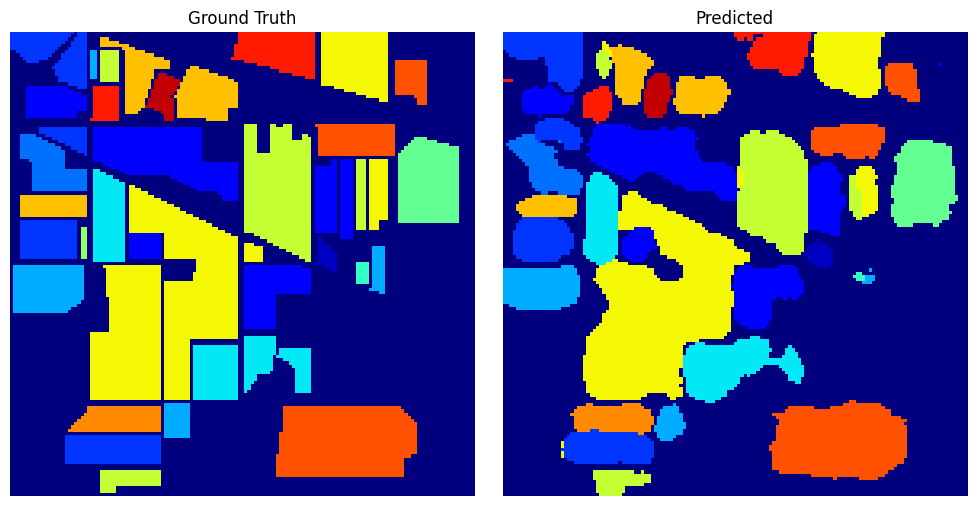

 56%|█████▌    | 10/18 [1:01:12<44:03, 330.48s/it, id=0.1, val_average_accuracy=0.904, val_f1=0.902, val_kappa=nan, val_loss=0.261, val_overall_accuracy=0.816]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9217122197151184
         val_f1              0.921686589717865
        val_kappa                   nan
        val_loss            0.25006598234176636
  val_overall_accuracy      0.8411932587623596
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


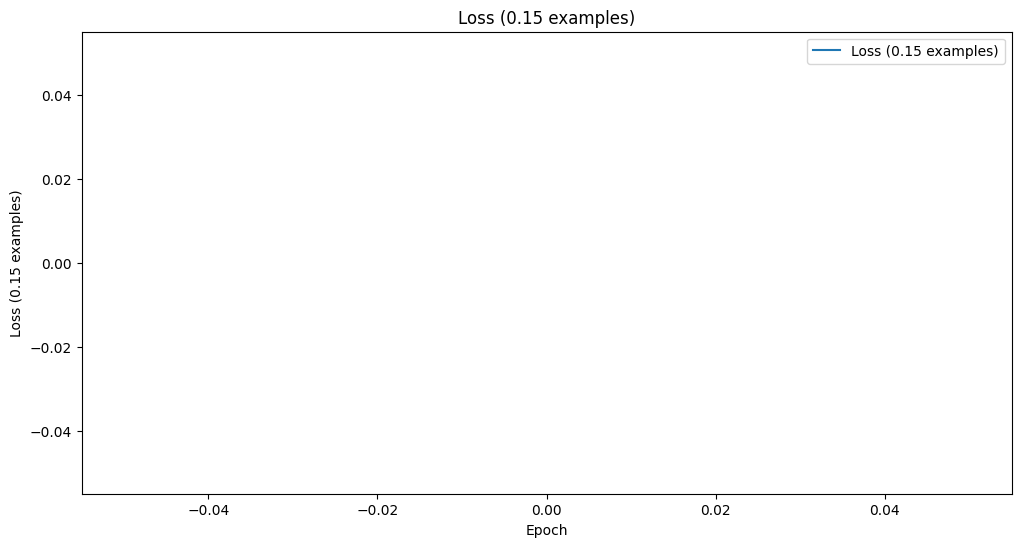

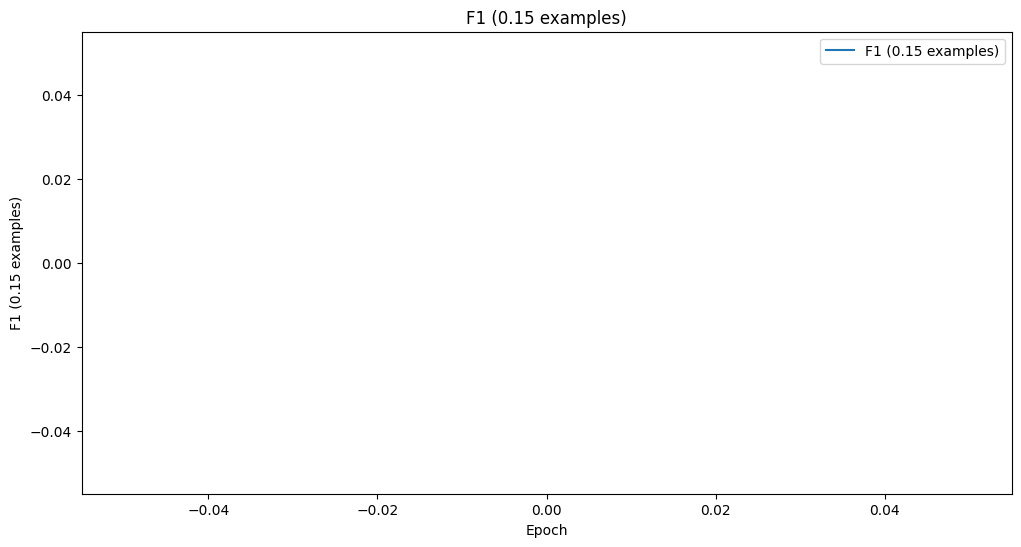

Predicting: |          | 0/? [00:00<?, ?it/s]

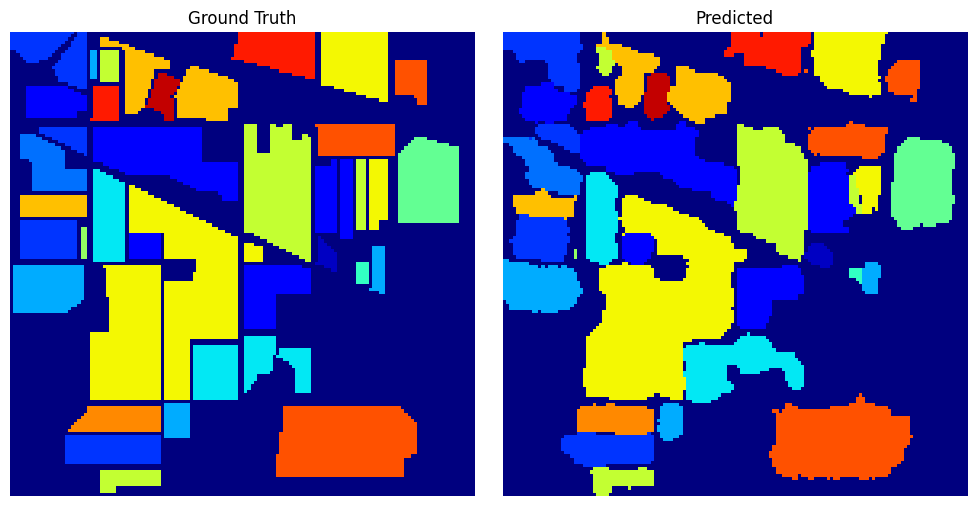

 61%|██████    | 11/18 [1:21:09<1:09:28, 595.56s/it, id=0.15, val_average_accuracy=0.922, val_f1=0.922, val_kappa=nan, val_loss=0.25, val_overall_accuracy=0.841]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9309869408607483
         val_f1              0.930837094783783
        val_kappa                   nan
        val_loss            0.20229846239089966
  val_overall_accuracy      0.8630783557891846
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


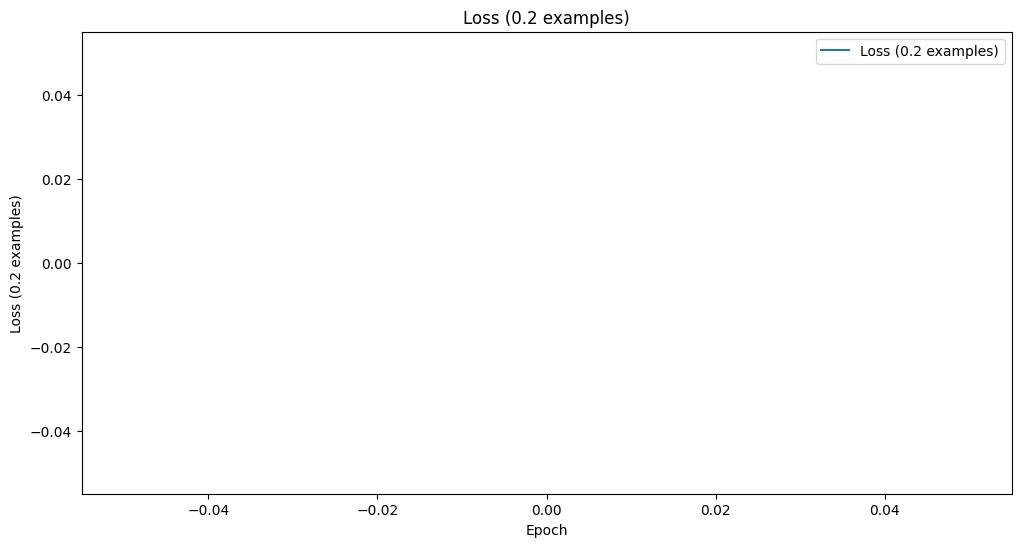

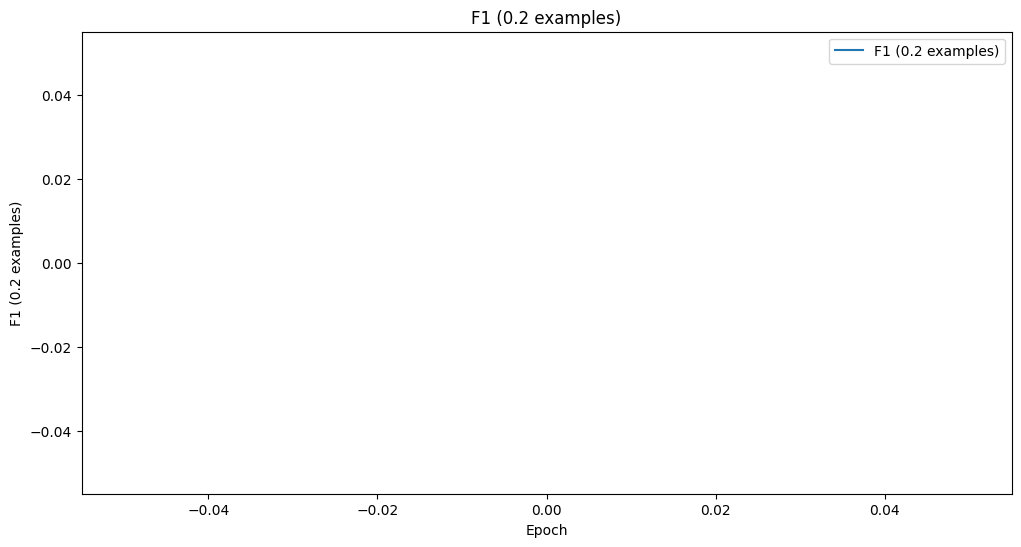

Predicting: |          | 0/? [00:00<?, ?it/s]

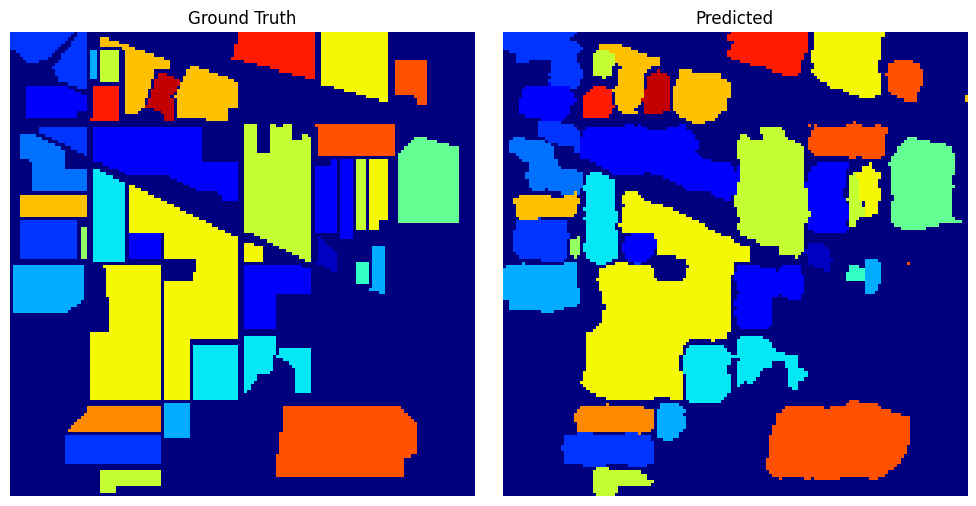

 67%|██████▋   | 12/18 [1:48:11<1:30:46, 907.81s/it, id=0.2, val_average_accuracy=0.931, val_f1=0.931, val_kappa=nan, val_loss=0.202, val_overall_accuracy=0.863]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9487752914428711
         val_f1             0.9497916102409363
        val_kappa                   nan
        val_loss            0.14979352056980133
  val_overall_accuracy      0.8968228697776794
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


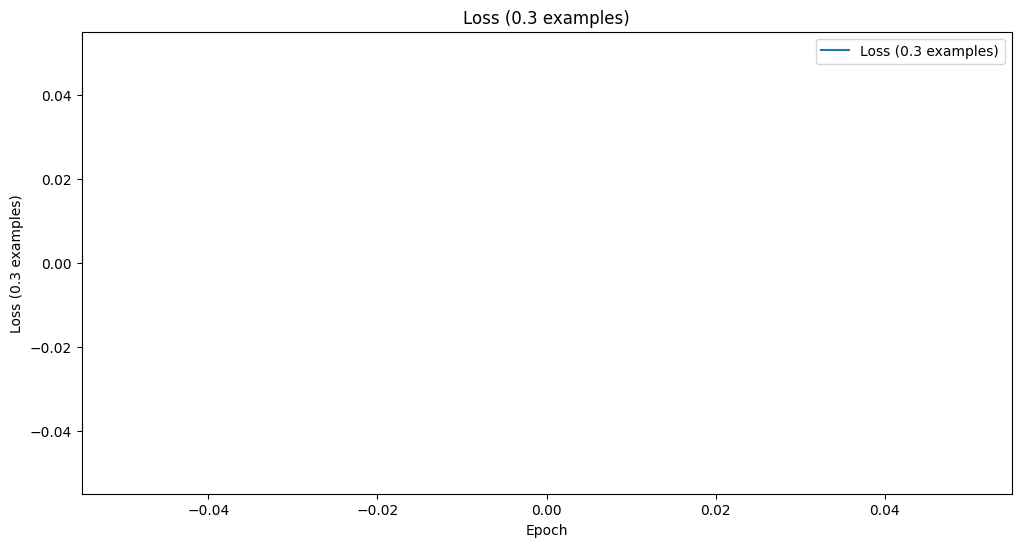

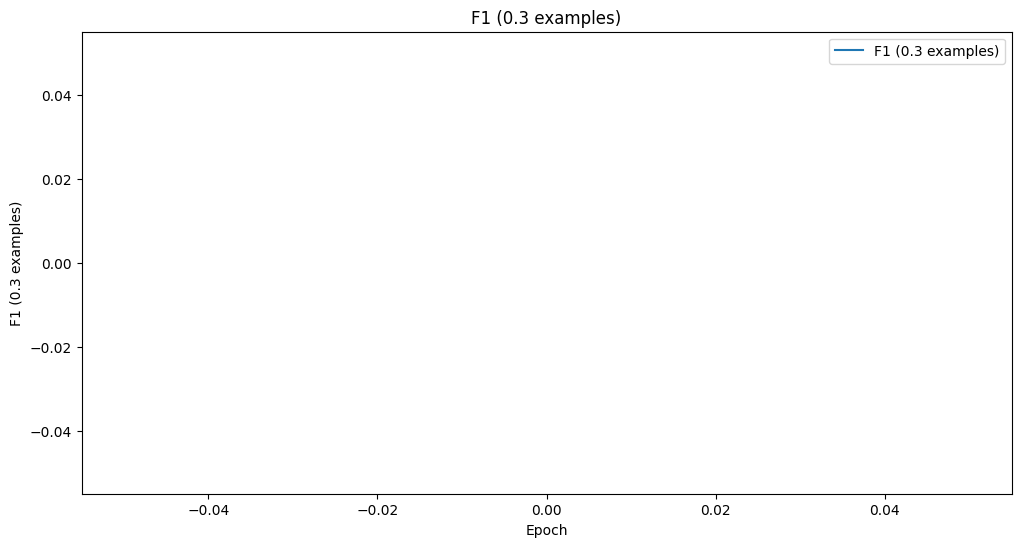

Predicting: |          | 0/? [00:00<?, ?it/s]

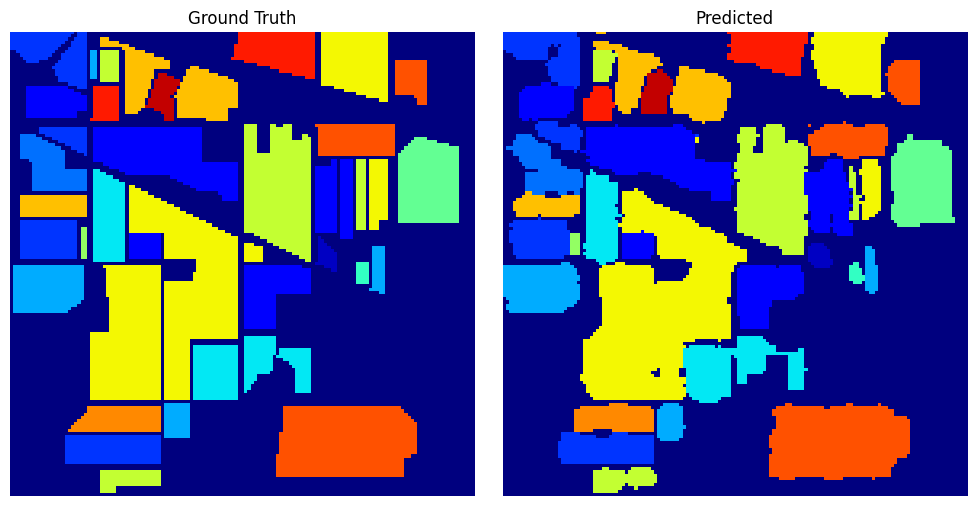

 72%|███████▏  | 13/18 [2:12:48<1:30:01, 1080.28s/it, id=0.3, val_average_accuracy=0.949, val_f1=0.95, val_kappa=nan, val_loss=0.15, val_overall_accuracy=0.897] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9574791789054871
         val_f1              0.958378255367279
        val_kappa                   nan
        val_loss            0.11467742919921875
  val_overall_accuracy      0.9093116521835327
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


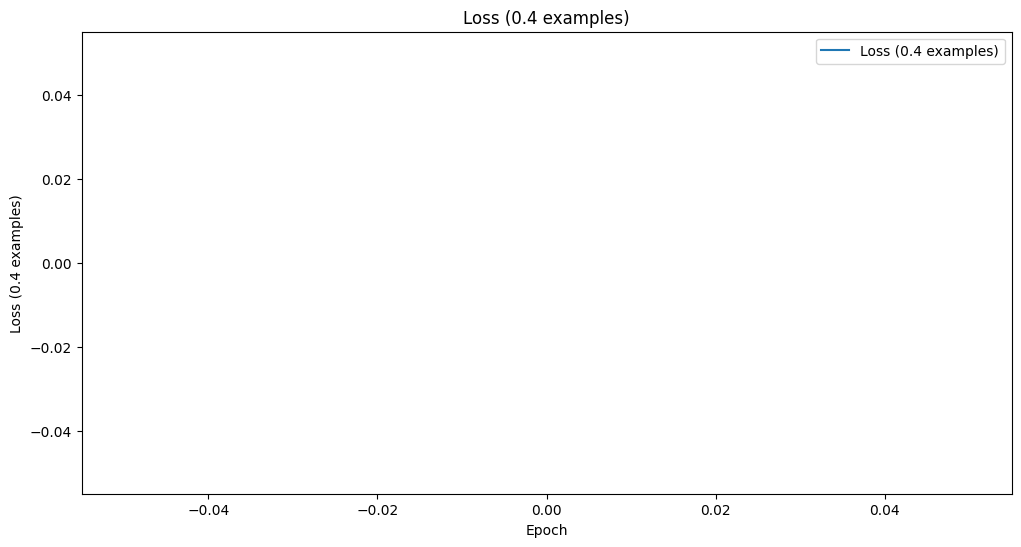

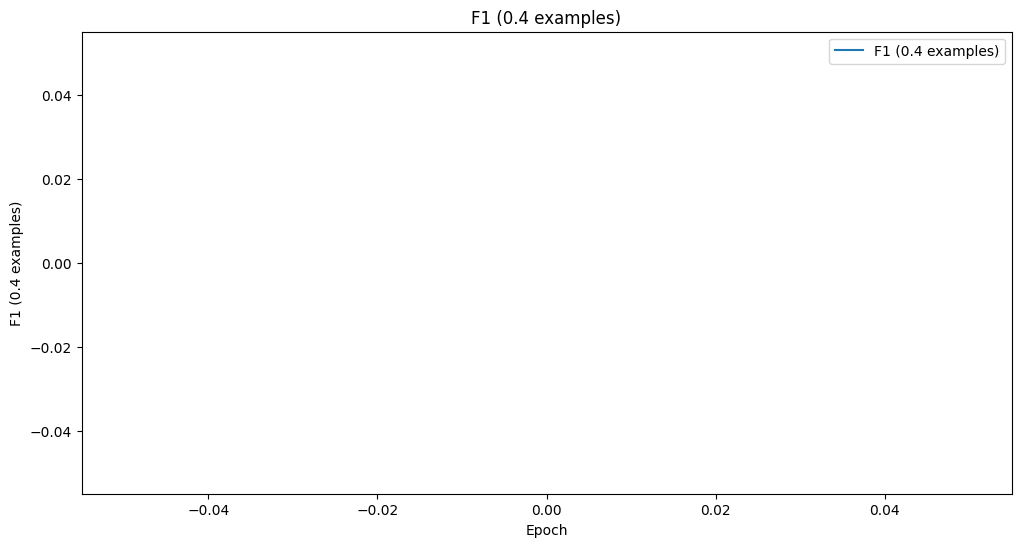

Predicting: |          | 0/? [00:00<?, ?it/s]

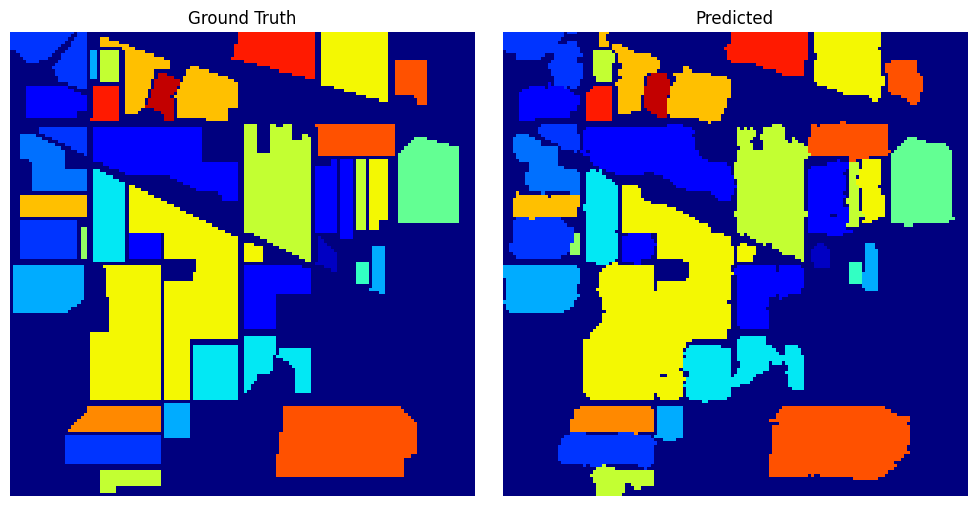

 78%|███████▊  | 14/18 [2:44:14<1:28:14, 1323.56s/it, id=0.4, val_average_accuracy=0.957, val_f1=0.958, val_kappa=nan, val_loss=0.115, val_overall_accuracy=0.909]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAcc

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9689893126487732
         val_f1             0.9691789746284485
        val_kappa                   nan
        val_loss            0.08594443649053574
  val_overall_accuracy      0.9308905005455017
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


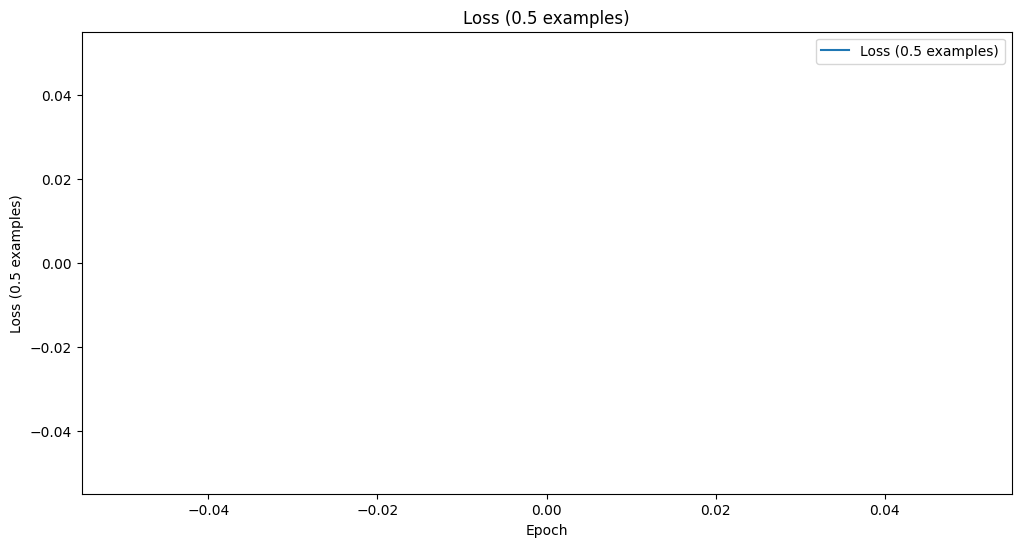

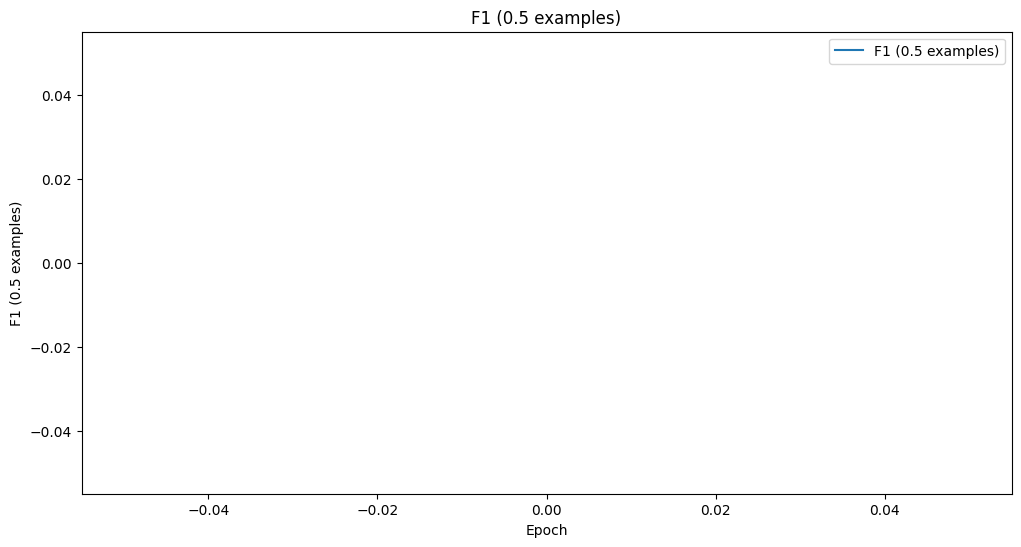

Predicting: |          | 0/? [00:00<?, ?it/s]

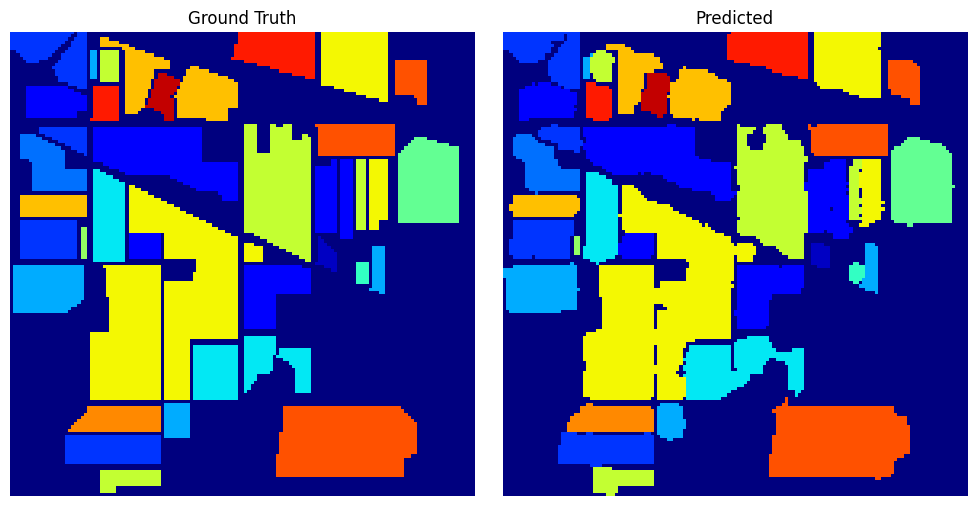

 83%|████████▎ | 15/18 [2:59:17<59:50, 1196.81s/it, id=0.5, val_average_accuracy=0.969, val_f1=0.969, val_kappa=nan, val_loss=0.0859, val_overall_accuracy=0.931]  You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAc

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9788823127746582
         val_f1             0.9789628386497498
        val_kappa                   nan
        val_loss           0.061583563685417175
  val_overall_accuracy      0.9483866095542908
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


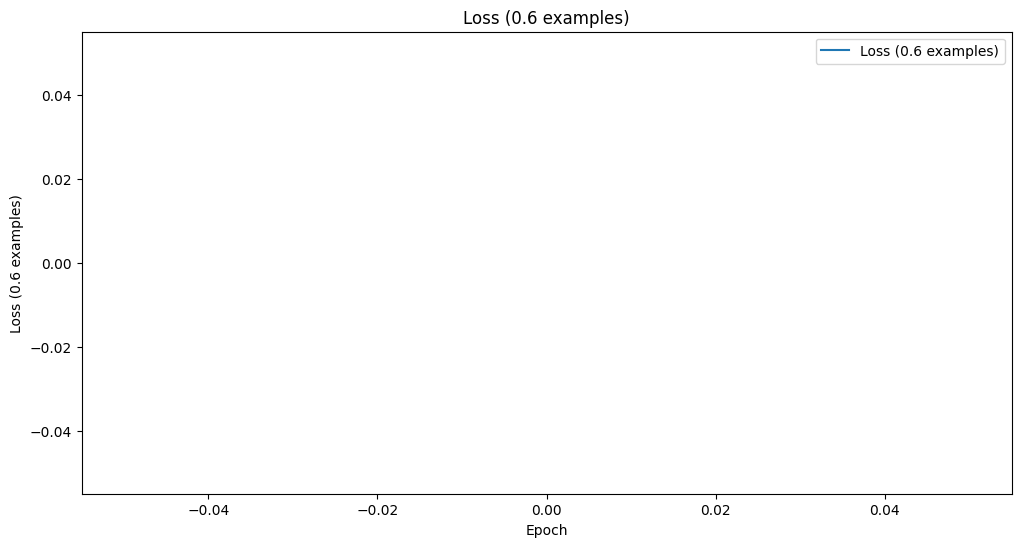

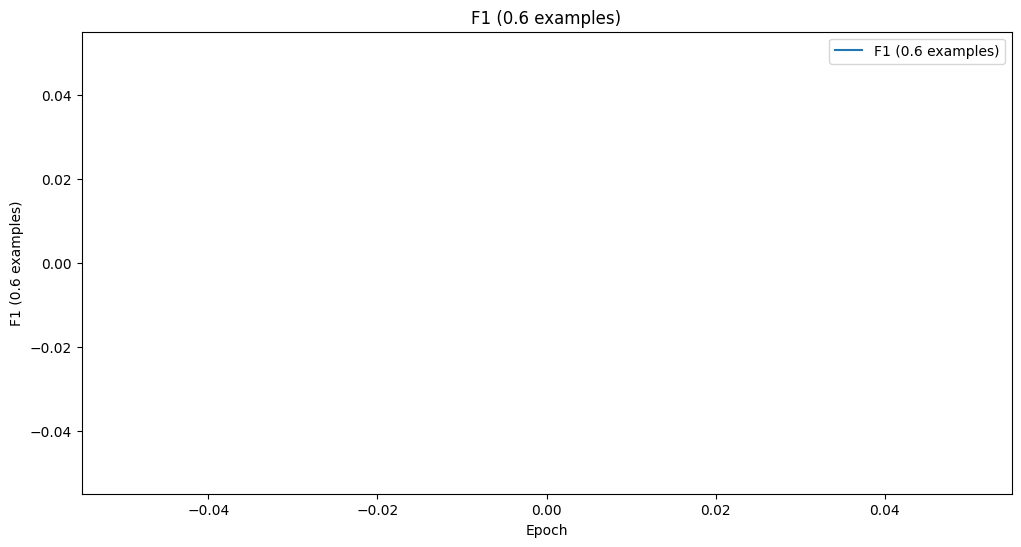

Predicting: |          | 0/? [00:00<?, ?it/s]

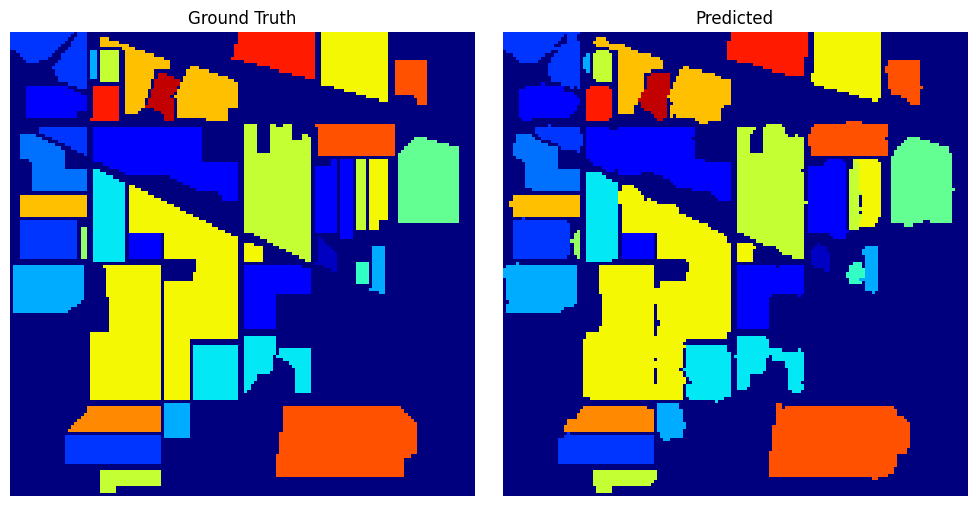

 89%|████████▉ | 16/18 [3:17:11<38:40, 1160.02s/it, id=0.6, val_average_accuracy=0.979, val_f1=0.979, val_kappa=nan, val_loss=0.0616, val_overall_accuracy=0.948]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9843519330024719
         val_f1             0.9841797351837158
        val_kappa                   nan
        val_loss            0.04653622955083847
  val_overall_accuracy      0.9638329744338989
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


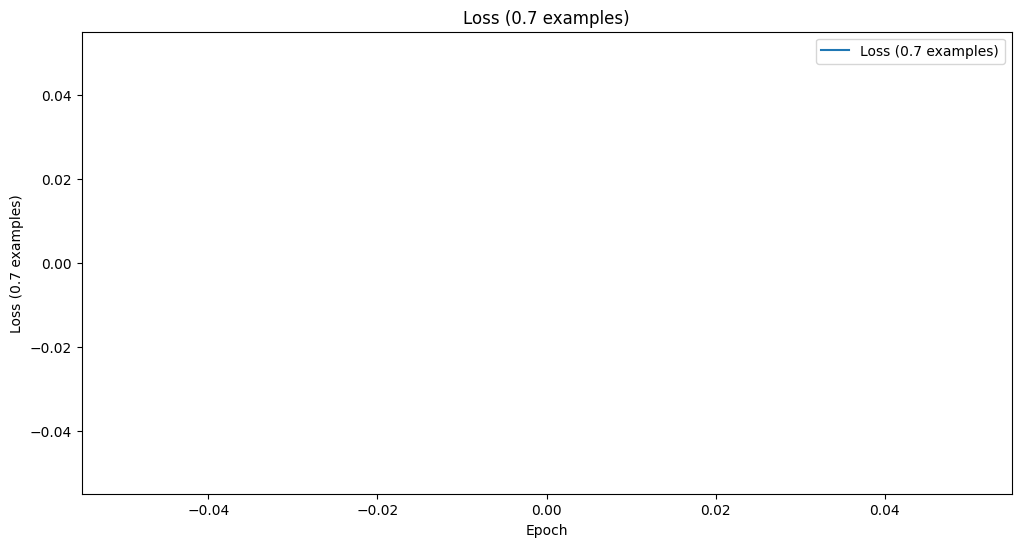

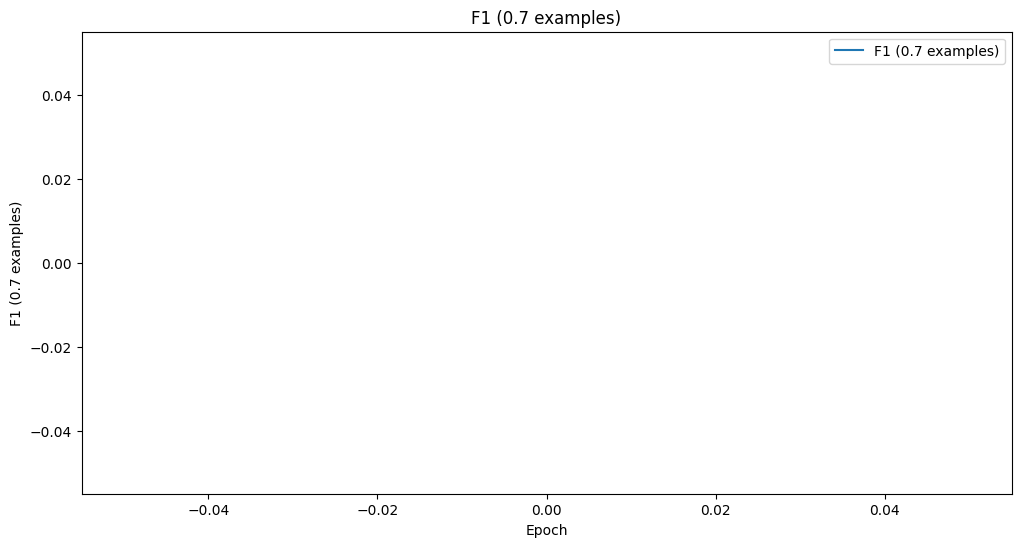

Predicting: |          | 0/? [00:00<?, ?it/s]

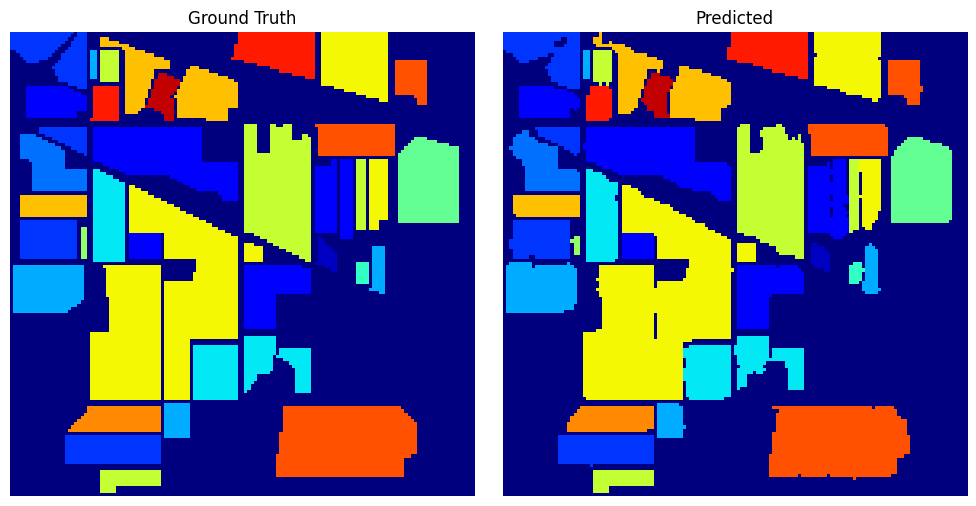

 94%|█████████▍| 17/18 [3:38:00<19:46, 1186.59s/it, id=0.7, val_average_accuracy=0.984, val_f1=0.984, val_kappa=nan, val_loss=0.0465, val_overall_accuracy=0.964]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccu

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9881094098091125
         val_f1             0.9879351258277893
        val_kappa                   nan
        val_loss           0.035553157329559326
  val_overall_accuracy      0.9676064848899841
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


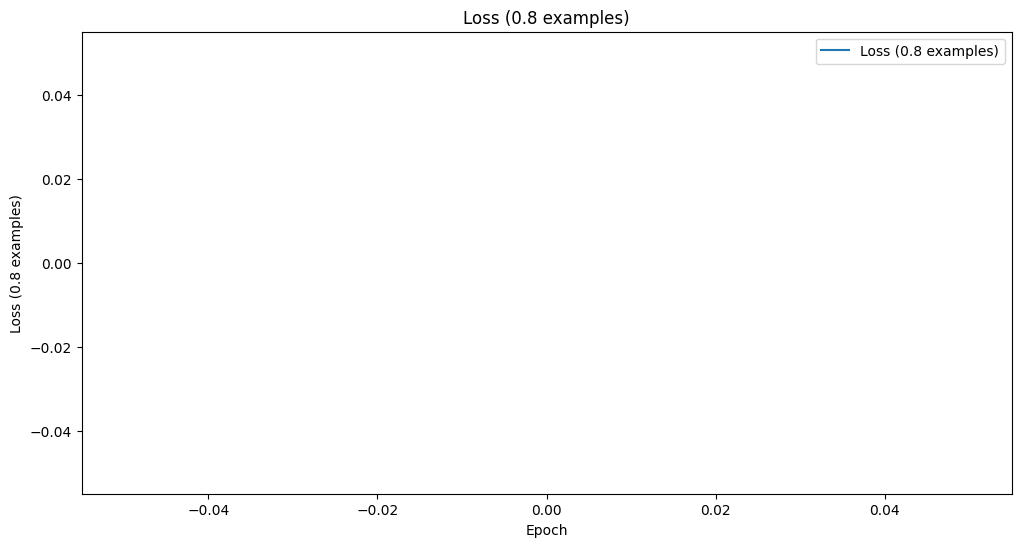

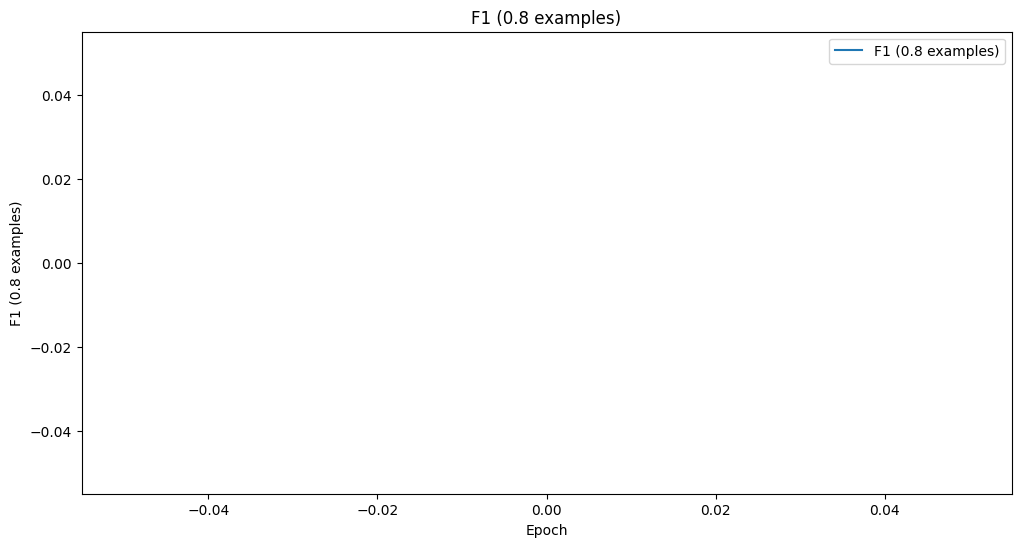

Predicting: |          | 0/? [00:00<?, ?it/s]

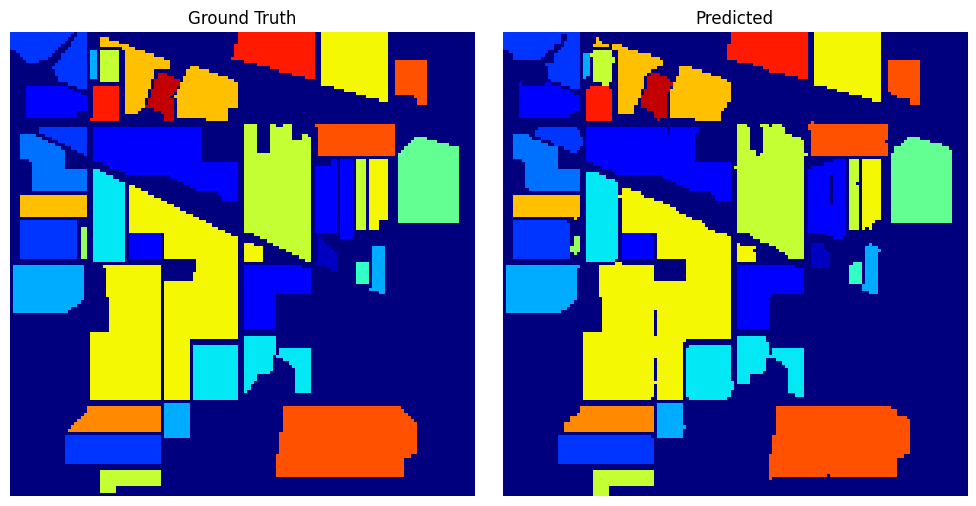

100%|██████████| 18/18 [4:01:42<00:00, 805.71s/it, id=0.8, val_average_accuracy=0.988, val_f1=0.988, val_kappa=nan, val_loss=0.0356, val_overall_accuracy=0.968] 


In [24]:
not_stratified_random_sampled_search = RepresentativeDataPointsSearch(
    RandomSampleDataPointsSearch(False), log_dir, f"random-sample-not-stratified"
)

feedback = not_stratified_random_sampled_search.run()

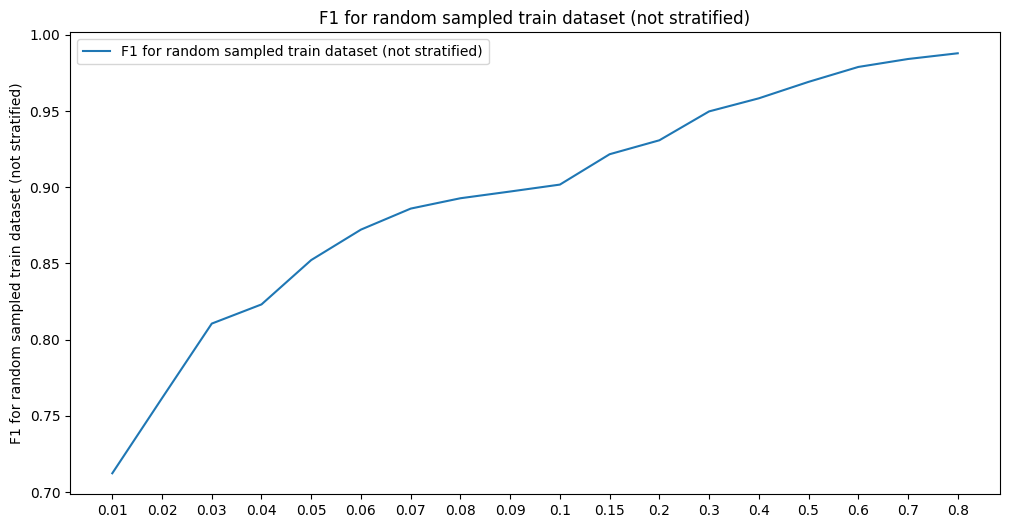

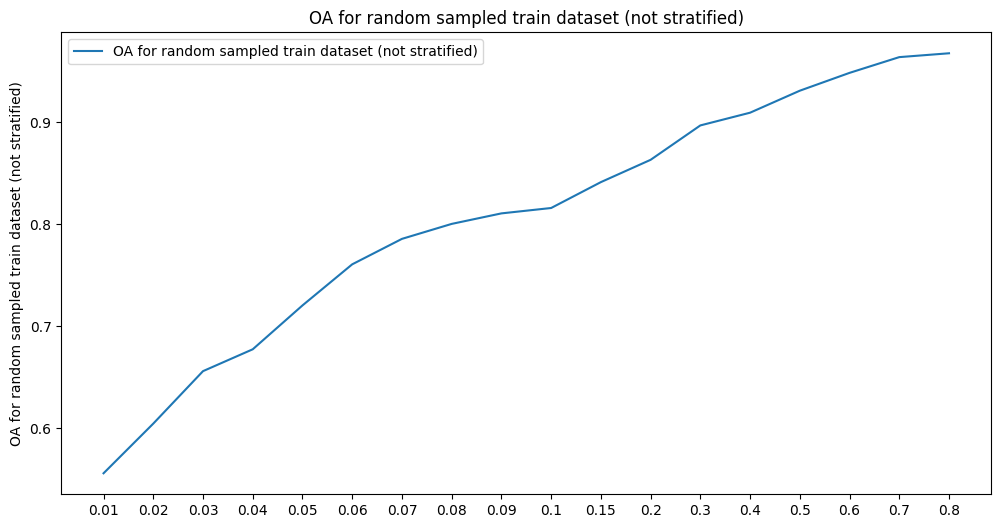

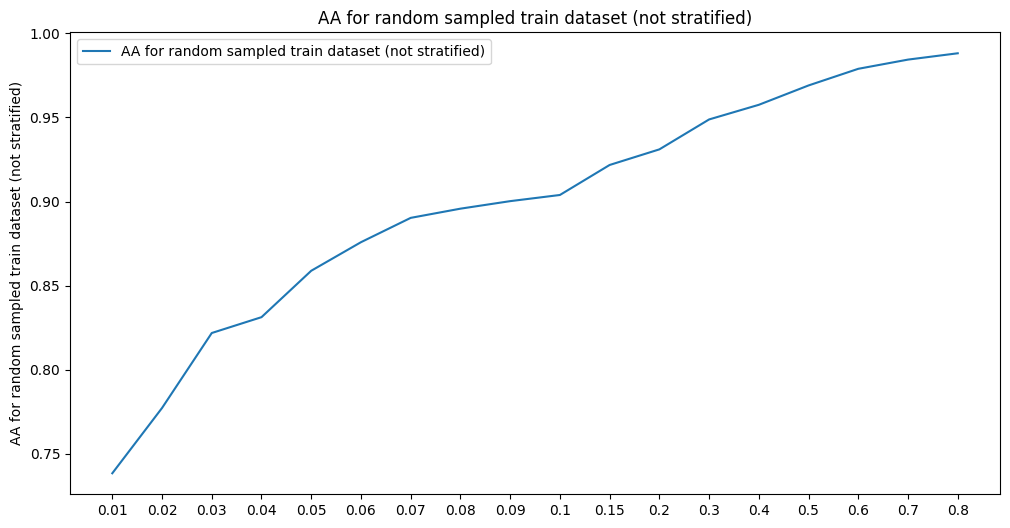

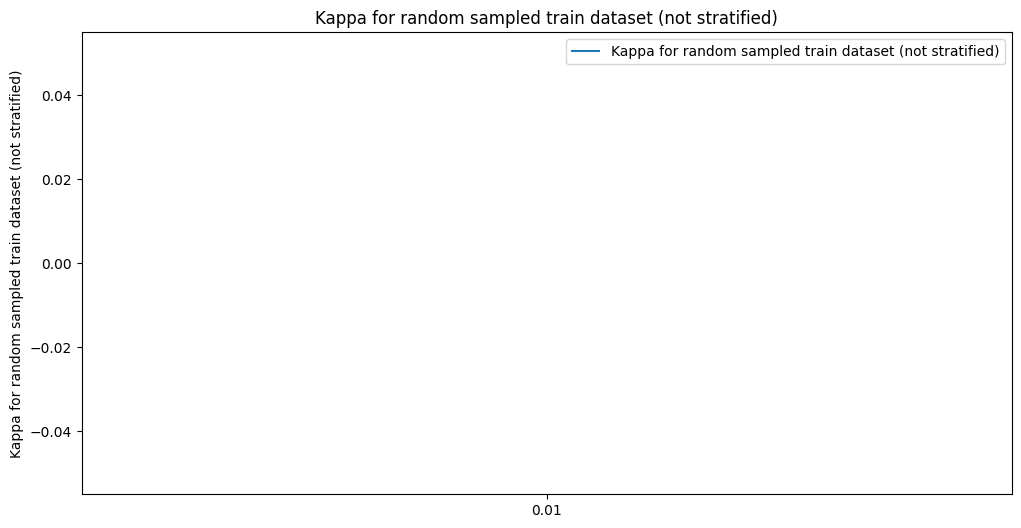

In [25]:
ids = [it.id for it in feedback]
not_stratified_random_f1s = [it.score["val_f1"] for it in feedback]
not_stratified_random_oas = [it.score["val_overall_accuracy"] for it in feedback]
not_stratified_random_aas = [it.score["val_average_accuracy"] for it in feedback]
not_stratified_random_kappas = [it.score["val_kappa"] for it in feedback]

plot_generic(
    ids,
    not_stratified_random_f1s,
    desc=f"F1 for random sampled train dataset (not stratified)",
)
plot_generic(
    ids,
    not_stratified_random_oas,
    desc=f"OA for random sampled train dataset (not stratified)",
)
plot_generic(
    ids,
    not_stratified_random_aas,
    desc=f"AA for random sampled train dataset (not stratified)",
)
plot_generic(
    ids,
    not_stratified_random_kappas,
    desc=f"Kappa for random sampled train dataset (not stratified)",
)

6. Train model on a k-medoids dataset (not stratified).

In [26]:
class KMedoidsSampleDataPointsSearch(
    RepresentativeDataPointsSearchAdapter[HyperSpectralImageClassifier]
):


    def get_run_params(
        self,
    ) -> Sequence[
        tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
    ]:
        params = {
            "num_epochs": num_epochs,
            "learning_rate": learning_rate,
            "t_initial": num_epochs,
            "weight_decay": weight_decay,
            "lr_min": learning_rate * 0.01,
            "warmup_lr_init": learning_rate * 0.01,
            "warmup_t": int(np.ceil(0.1 * num_epochs)),
        }

        return [self.create_run_params(id, path, params) for id, path in mask_arr]

    def init_model(self, params: dict[str, float]) -> HyperSpectralImageClassifier:
        return HyperSpectralImageClassifier(
            DBDA(band=target_dim, classes=num_classes),
            num_classes,
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
            scheduler=lambda optimizer: CosineLRSchedulerWrapper(
                optimizer,
                t_initial=params["num_epochs"],
                lr_min=params["lr_min"],
                warmup_t=params["warmup_t"],
                warmup_lr_init=params["warmup_lr_init"],
            ),
        )

    def fit_model(
        self,
        model: HyperSpectralImageClassifier,
        loader: data.DataLoader,
        eval_loader: Optional[data.DataLoader],
        params: dict[str, float],
    ):
        trainer = Trainer(accelerator="auto", max_epochs=params["num_epochs"])

        trainer.fit(model, loader, eval_loader)

        return [asdict(it) for it in model.val_metrics]

    def score_model(
        self, model: HyperSpectralImageClassifier
    ) -> list[dict[str, float]]:
        trainer = Trainer(accelerator="auto", max_epochs=0)

        return trainer.validate(model, full_loader)[0]

    def on_scored_model(
        self,
        id: str,
        params: dict[str, float],
        model: HyperSpectralImageClassifier,
        model_history: list[dict[str, float]],
        score: dict[str, float],
    ):
        trainer = Trainer(accelerator="auto", max_epochs=0)

        losses = [it["loss"].cpu() for it in model_history]
        f1s = [it["f1"].cpu() for it in model_history]
        plot_epoch_generic(losses, desc=f"Loss ({id} examples)")
        plot_epoch_generic(f1s, desc=f"F1 ({id} examples)")

        y_pred = trainer.predict(model, predict_loader)
        y_pred = torch.cat(y_pred, dim=0)
        y_pred = torch.argmax(y_pred, dim=1)
        y_pred = y_pred.reshape(image_h, image_w)

        plot_segmentation_comparison(y.reshape(image_h, image_w), y_pred.numpy())

        model_labels_count = {
            key: int(value * float(id)) for key, value in labels_per_class.items()
        }
        model_name = create_model_name(f"indian_pines", model_labels_count)
        model_category = "dbda"

        run_params = {
            **params,
            "batch_size": batch_size,
            "patch_size": patch_size,
            "target_dim": target_dim,
            "pre_process_type": str(pre_process_type),
            "dim_reduction_type": str(dim_reduction_type),
        }

        report_run(
            model_name=model_name,
            model_category=model_category,
            run_desc=f"Train model with a k-medoids sampled dataset (with PCA and STANDARTIZATION)",
            run_params=run_params | model.get_params(),
            run_metrics=lightning_metrics(score),
        )

        read_report_to_show(model_name, sort_by_metric="f1")

    def create_dataloader_from_mask_file(
        self, path: Path
    ) -> tuple[data.DataLoader, data.DataLoader]:
        mask = read_fixed_labels_mask_from_path(path)

        x_train, y_train, x_test, y_test = train_test_split_by_mask(x, y, mask)

        x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
        y_train_tensor = torch.tensor(y_train, dtype=torch.long)
        x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 3, 1, 2)
        y_test_tensor = torch.tensor(y_test, dtype=torch.long)

        train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
        test_dataset = data.TensorDataset(x_test_tensor, y_test_tensor)

        train_loader = data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=cpu_count,
            persistent_workers=True,
        )
        test_loader = data.DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=cpu_count,
            persistent_workers=True,
        )

        return train_loader, None

    def create_run_params(
        self, id: float, mask_path: Path, params: dict[str, float]
    ) -> tuple[str, data.DataLoader, data.DataLoader, dict[str, float]]:
        loader, eval_loader = self.create_dataloader_from_mask_file(mask_path)

        return str(id), loader, eval_loader, params

  0%|          | 0/18 [00:00<?, ?it/s]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   | 0      | train
4 | average_accuracy | MulticlassAccuracy   | 0      | train
5 | kappa            | MulticlassCohen

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.6158382892608643
         val_f1             0.5589839220046997
        val_kappa                   nan
        val_loss             2.416264772415161
  val_overall_accuracy      0.4403653144836426
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


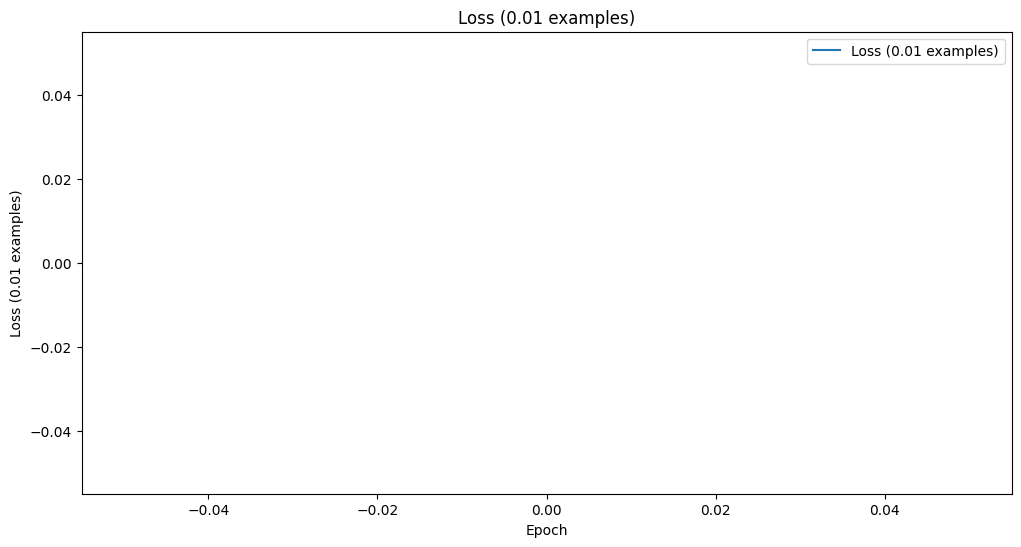

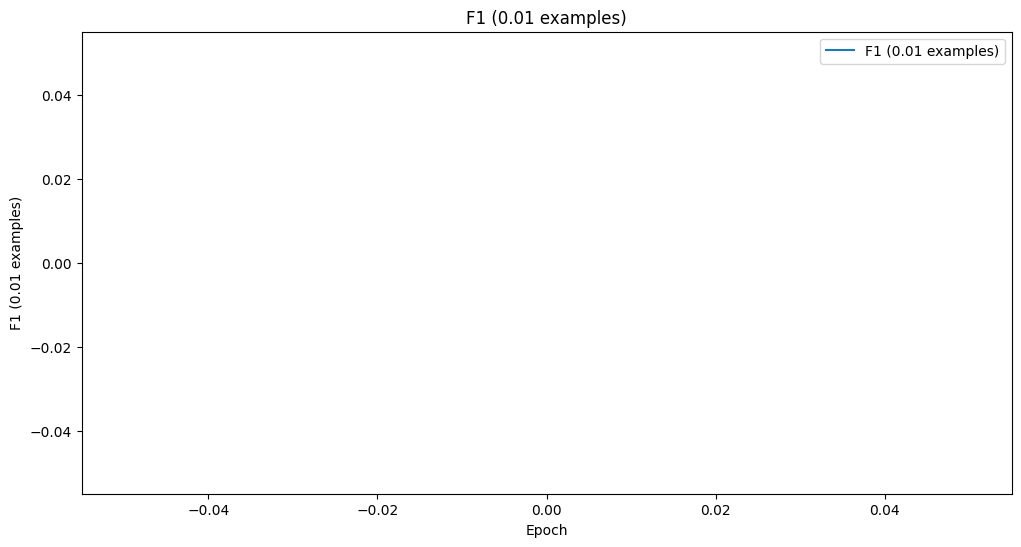

Predicting: |          | 0/? [00:00<?, ?it/s]

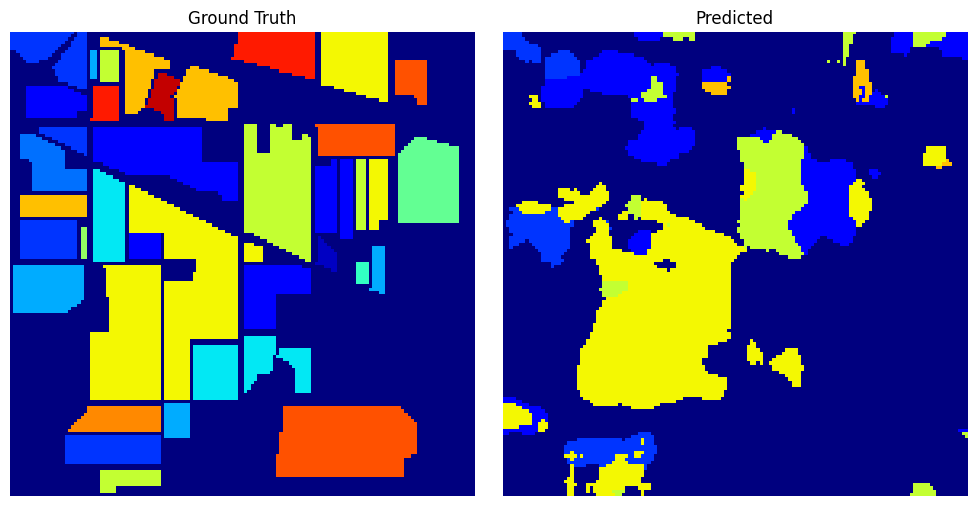

  6%|▌         | 1/18 [00:47<13:24, 47.33s/it, id=0.01, val_average_accuracy=0.616, val_f1=0.559, val_kappa=nan, val_loss=2.42, val_overall_accuracy=0.44]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy   

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.6659690737724304
         val_f1             0.6228559017181396
        val_kappa                   nan
        val_loss             2.81789231300354
  val_overall_accuracy      0.4932962954044342
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


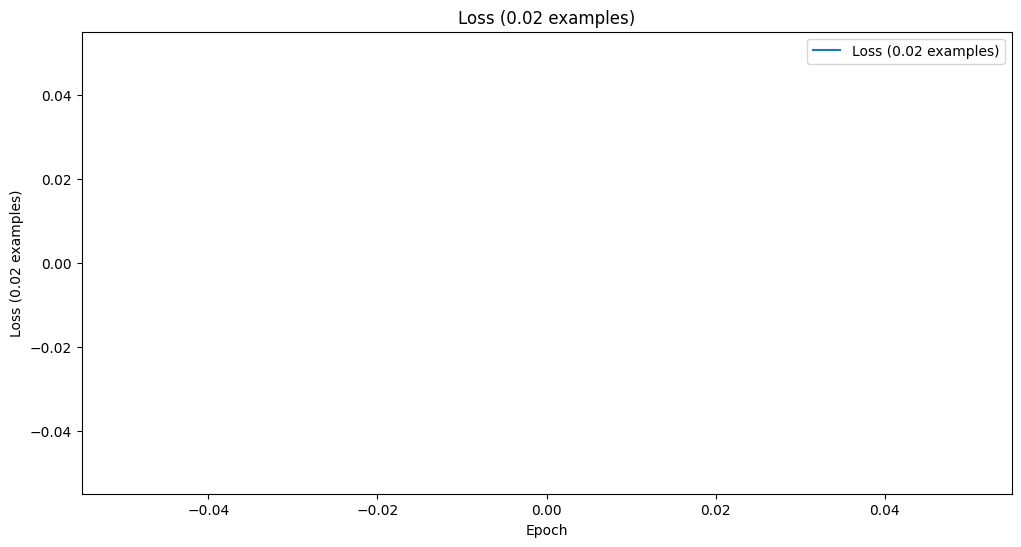

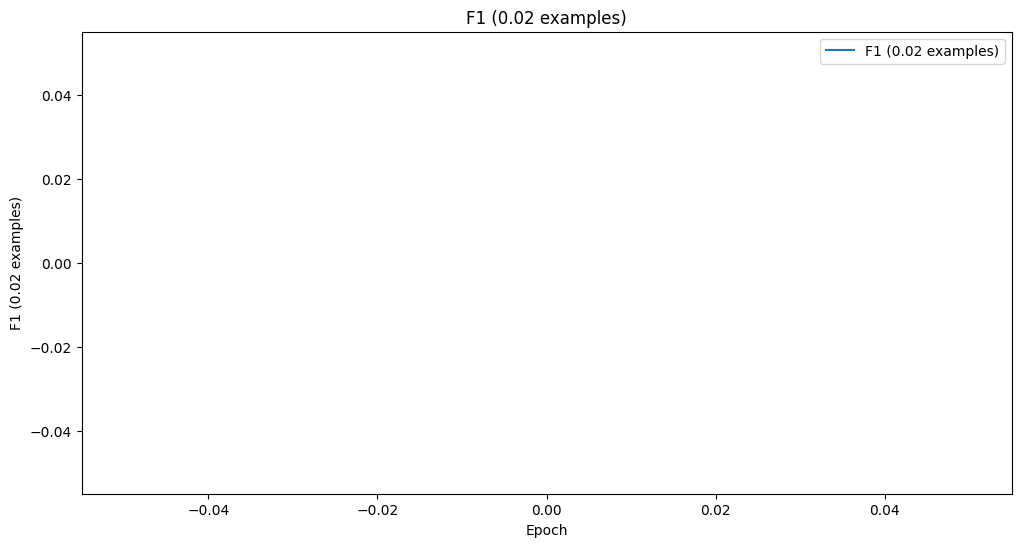

Predicting: |          | 0/? [00:00<?, ?it/s]

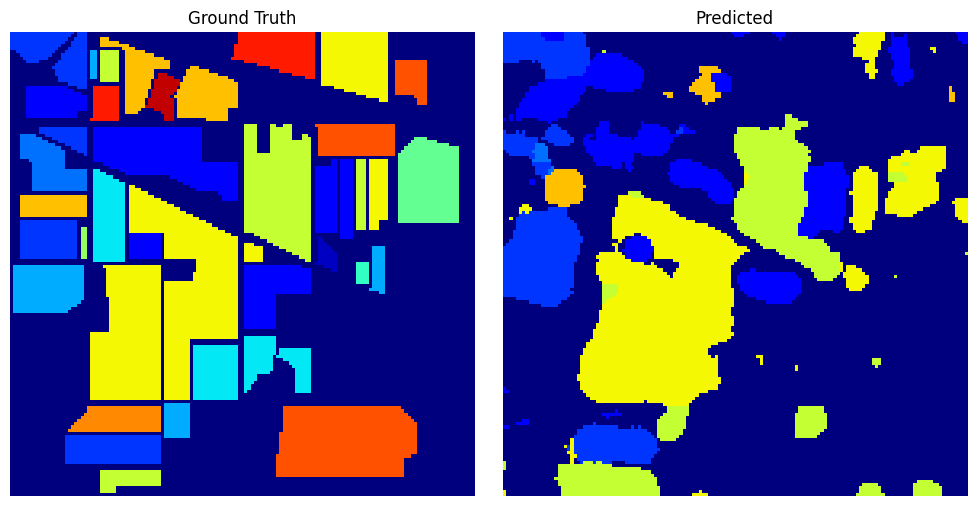

 11%|█         | 2/18 [01:51<15:18, 57.39s/it, id=0.02, val_average_accuracy=0.666, val_f1=0.623, val_kappa=nan, val_loss=2.82, val_overall_accuracy=0.493]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy  

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.6847086548805237
         val_f1             0.6335514187812805
        val_kappa                   nan
        val_loss            3.1571240425109863
  val_overall_accuracy      0.5300678014755249
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


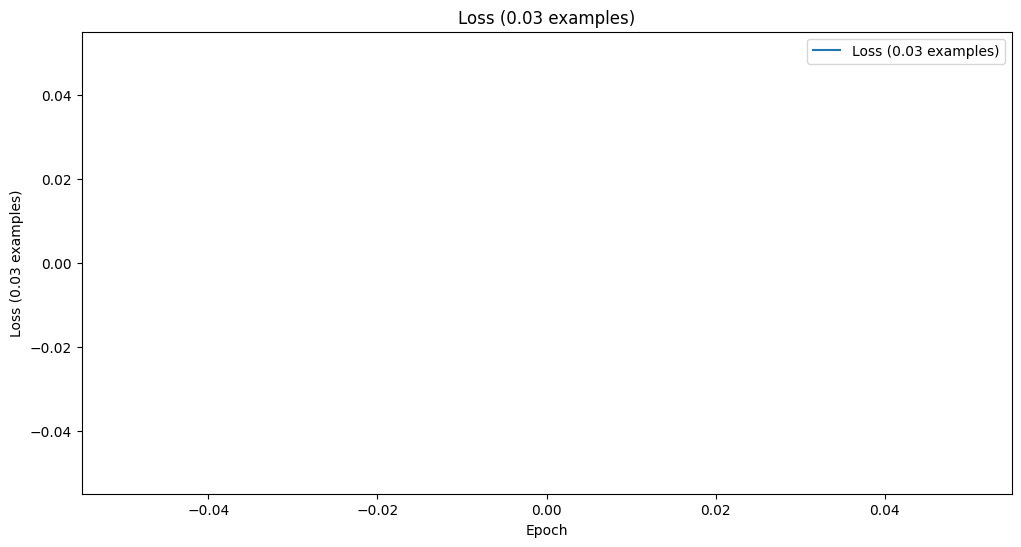

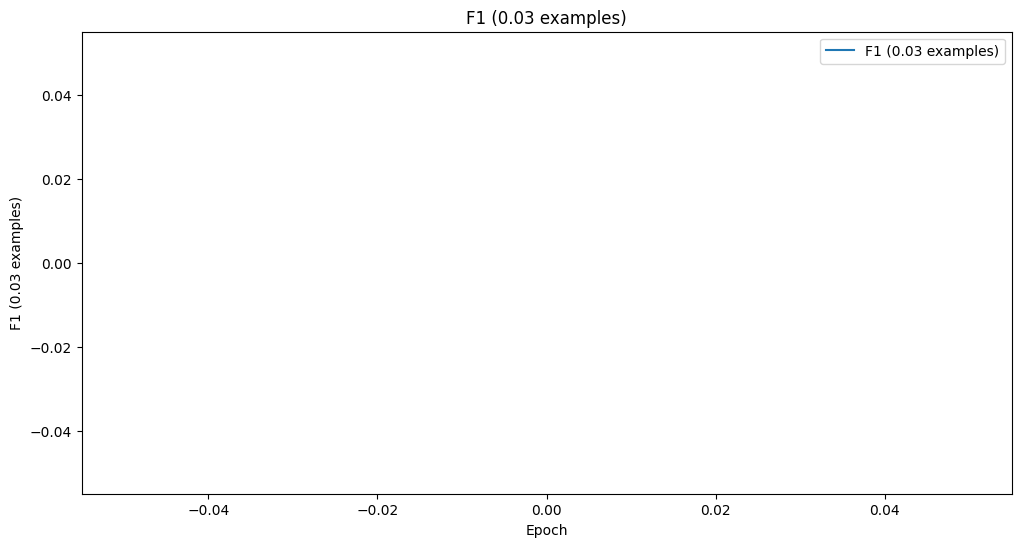

Predicting: |          | 0/? [00:00<?, ?it/s]

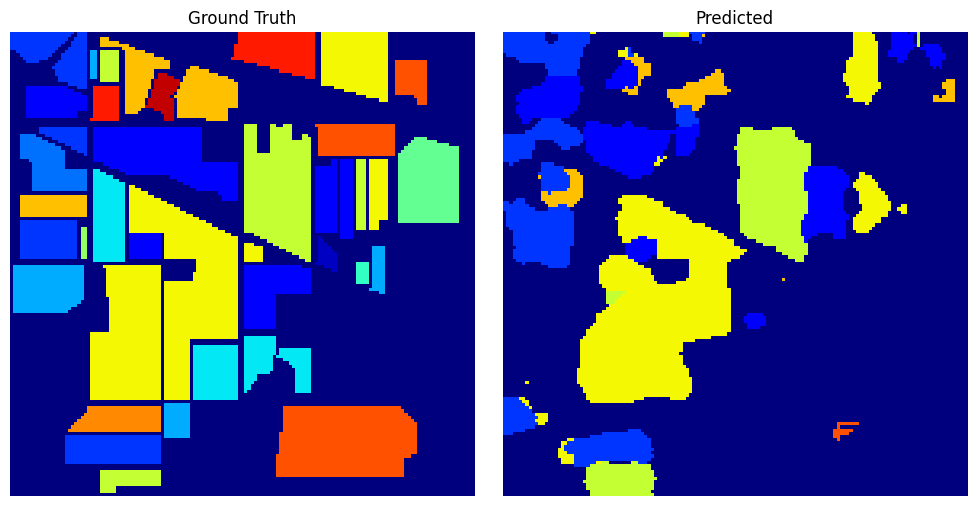

 17%|█▋        | 3/18 [03:13<17:08, 68.57s/it, id=0.03, val_average_accuracy=0.685, val_f1=0.634, val_kappa=nan, val_loss=3.16, val_overall_accuracy=0.53] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy  

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7138168811798096
         val_f1              0.663571298122406
        val_kappa                   nan
        val_loss            1.4747313261032104
  val_overall_accuracy      0.5746793150901794
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


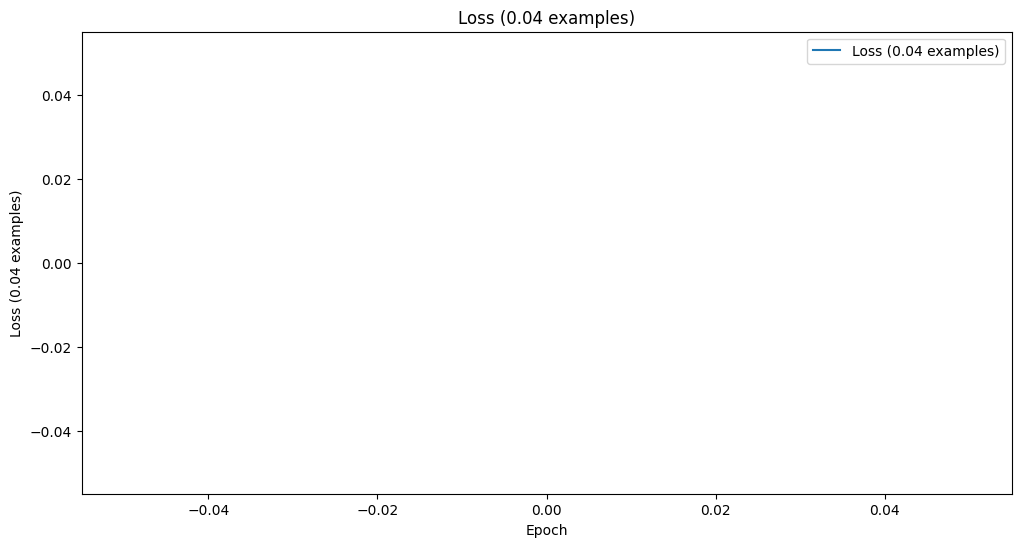

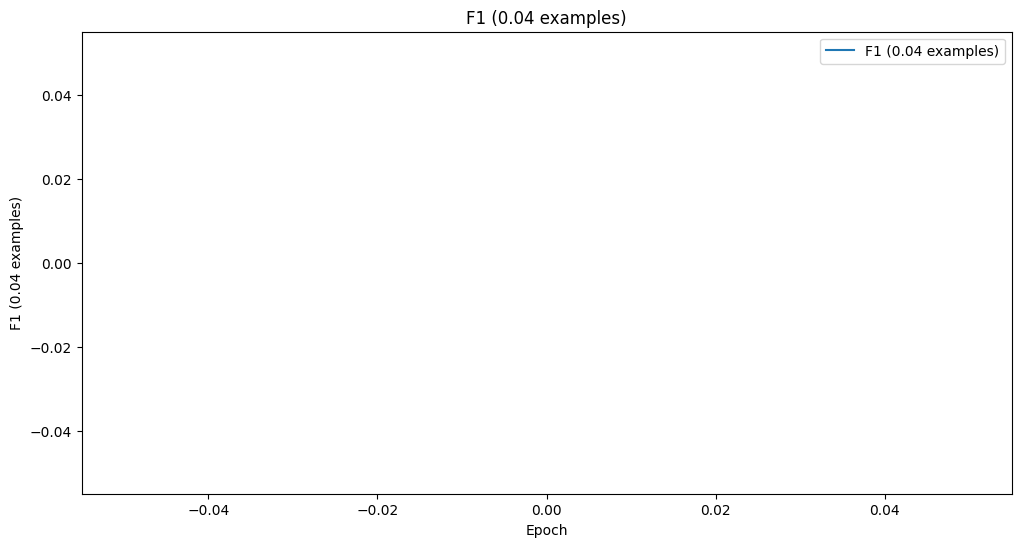

Predicting: |          | 0/? [00:00<?, ?it/s]

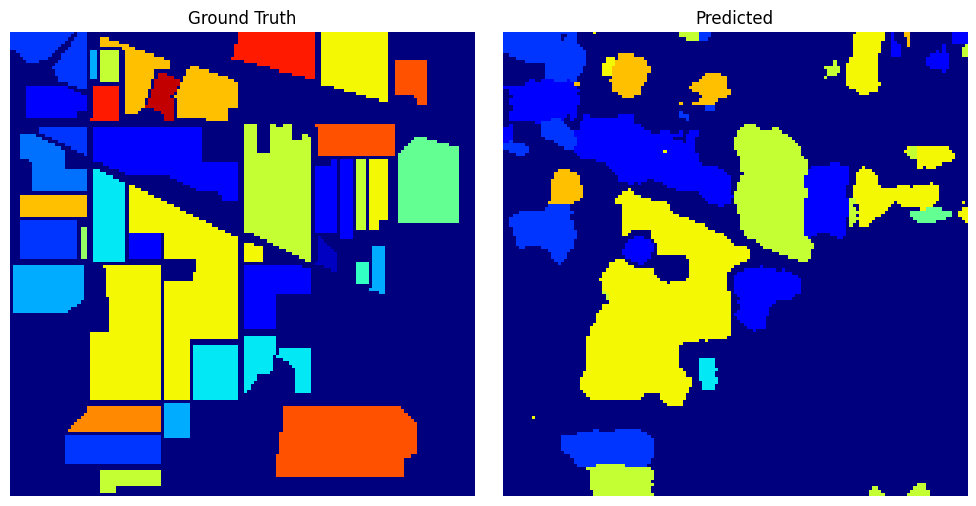

 22%|██▏       | 4/18 [17:03<1:26:05, 369.00s/it, id=0.04, val_average_accuracy=0.714, val_f1=0.664, val_kappa=nan, val_loss=1.47, val_overall_accuracy=0.575]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7549583911895752
         val_f1             0.7144724130630493
        val_kappa                   nan
        val_loss             1.372134804725647
  val_overall_accuracy      0.6308541297912598
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


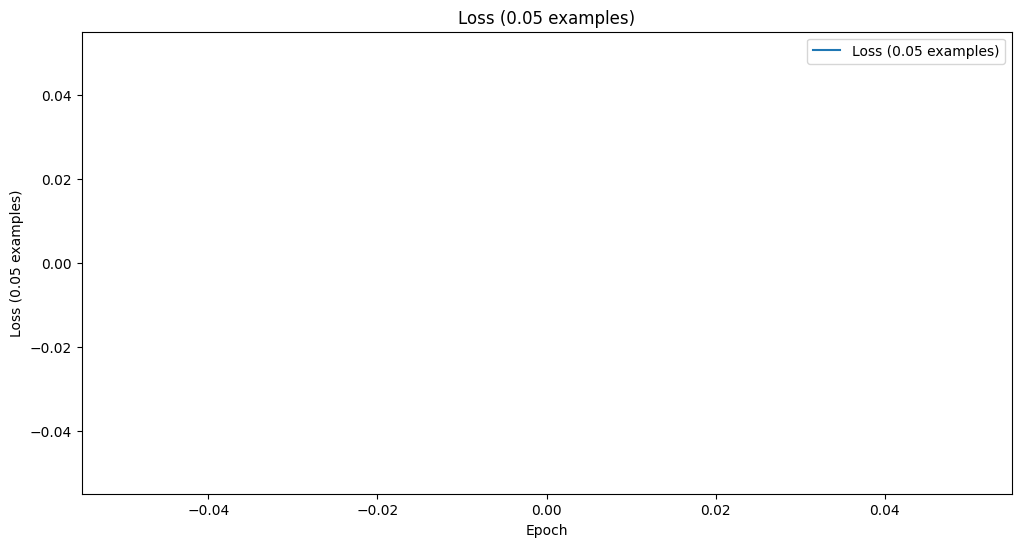

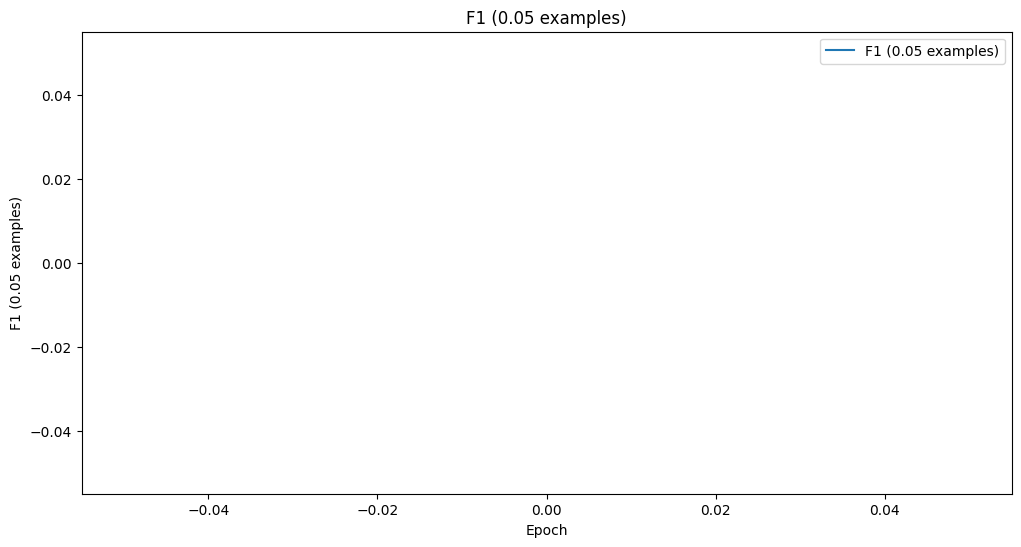

Predicting: |          | 0/? [00:00<?, ?it/s]

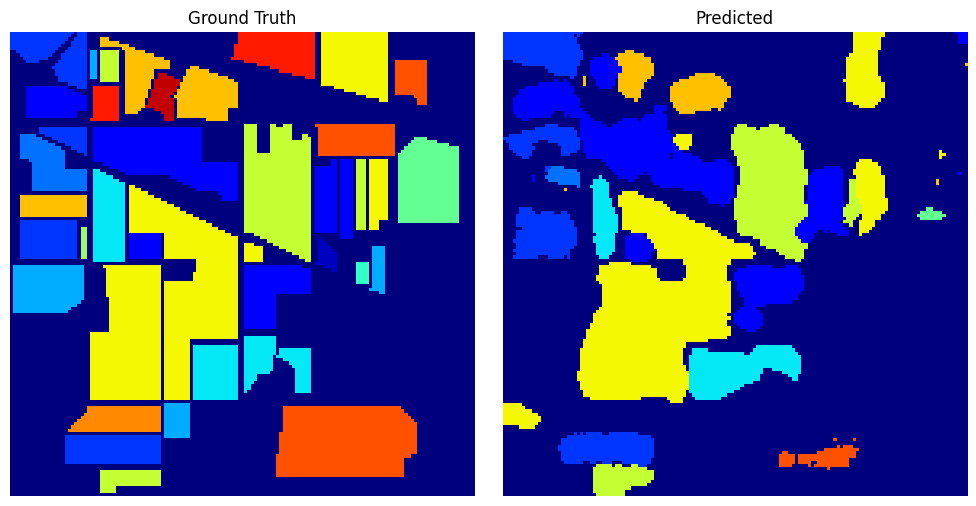

 28%|██▊       | 5/18 [18:59<1:00:14, 278.04s/it, id=0.05, val_average_accuracy=0.755, val_f1=0.714, val_kappa=nan, val_loss=1.37, val_overall_accuracy=0.631]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.7912960648536682
         val_f1             0.7645242214202881
        val_kappa                   nan
        val_loss            0.8789041042327881
  val_overall_accuracy      0.6654794216156006
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


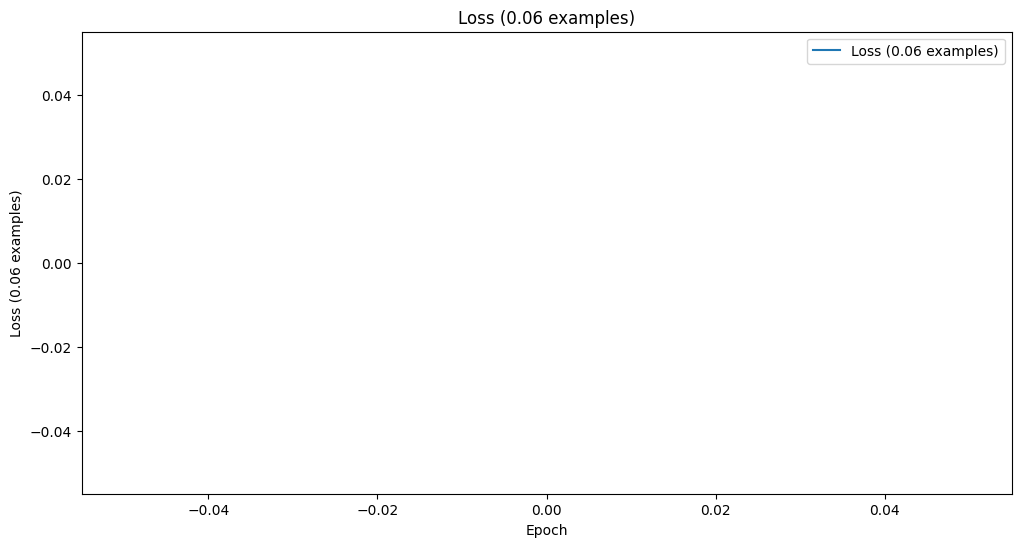

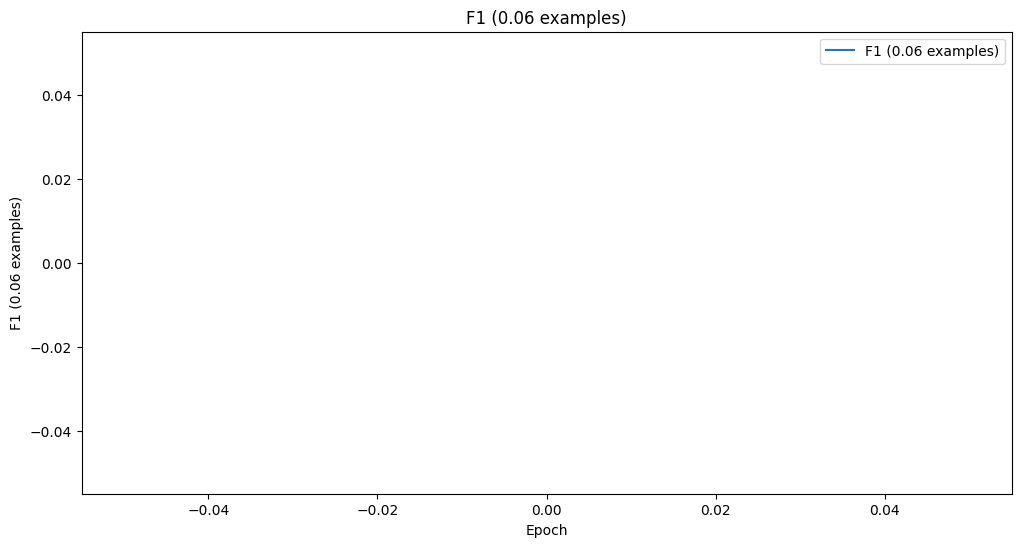

Predicting: |          | 0/? [00:00<?, ?it/s]

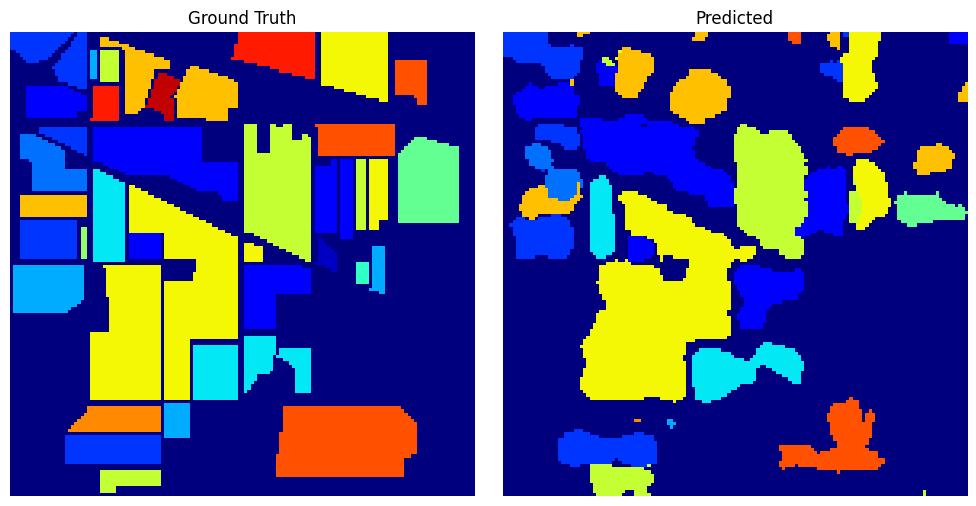

 33%|███▎      | 6/18 [21:14<45:50, 229.22s/it, id=0.06, val_average_accuracy=0.791, val_f1=0.765, val_kappa=nan, val_loss=0.879, val_overall_accuracy=0.665]  You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8097503185272217
         val_f1              0.796932578086853
        val_kappa                   nan
        val_loss             1.127603530883789
  val_overall_accuracy      0.6566977500915527
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


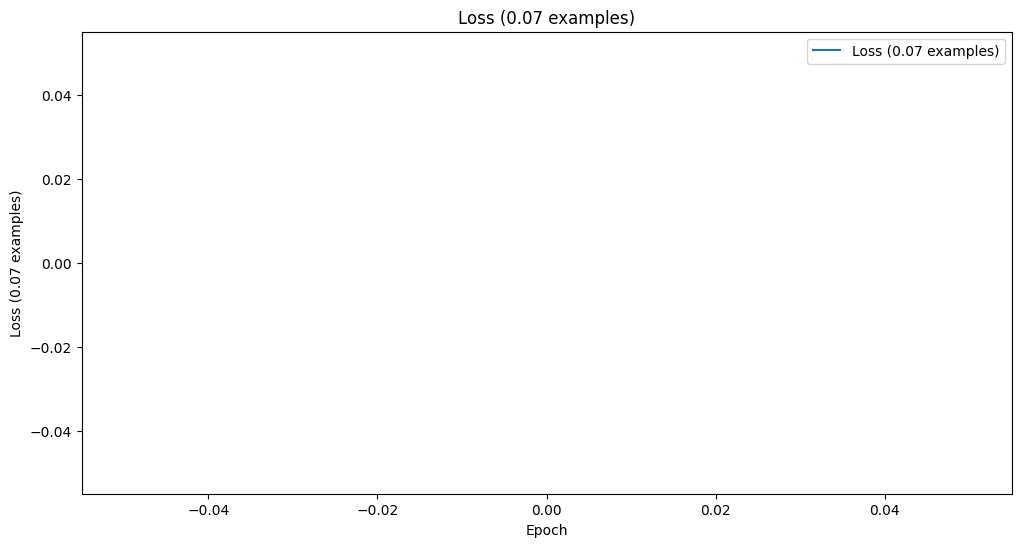

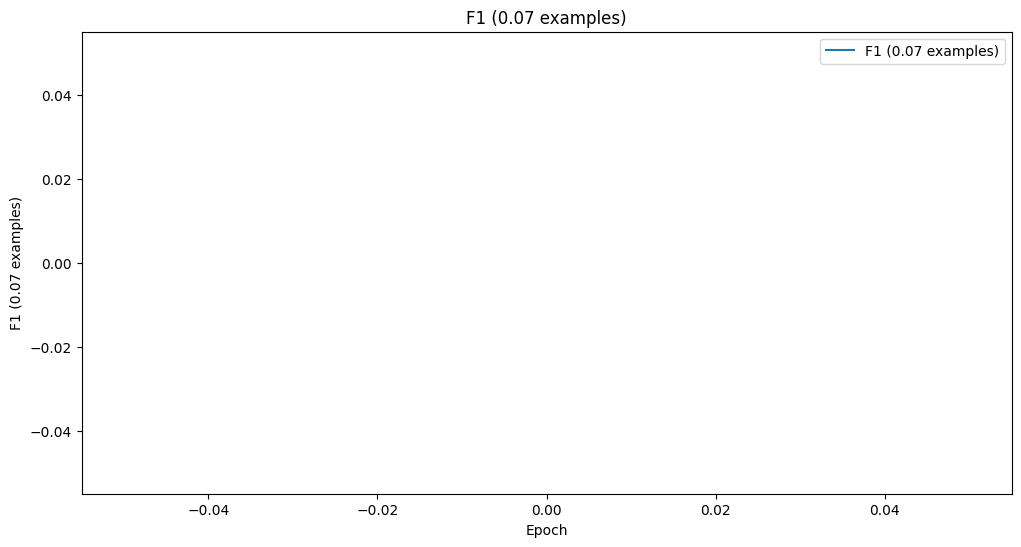

Predicting: |          | 0/? [00:00<?, ?it/s]

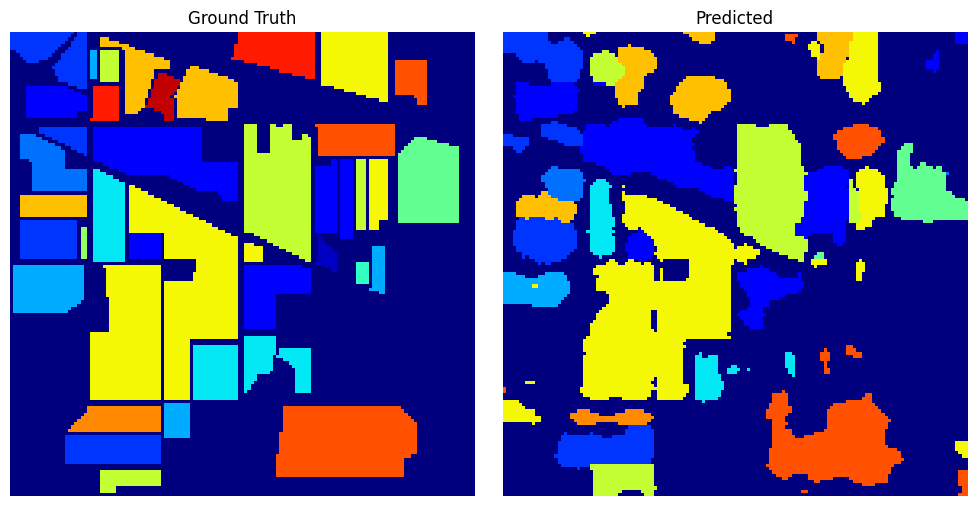

 39%|███▉      | 7/18 [24:00<38:13, 208.53s/it, id=0.07, val_average_accuracy=0.81, val_f1=0.797, val_kappa=nan, val_loss=1.13, val_overall_accuracy=0.657]  You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8191201090812683
         val_f1              0.801060676574707
        val_kappa                   nan
        val_loss            1.0411772727966309
  val_overall_accuracy       0.689439594745636
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


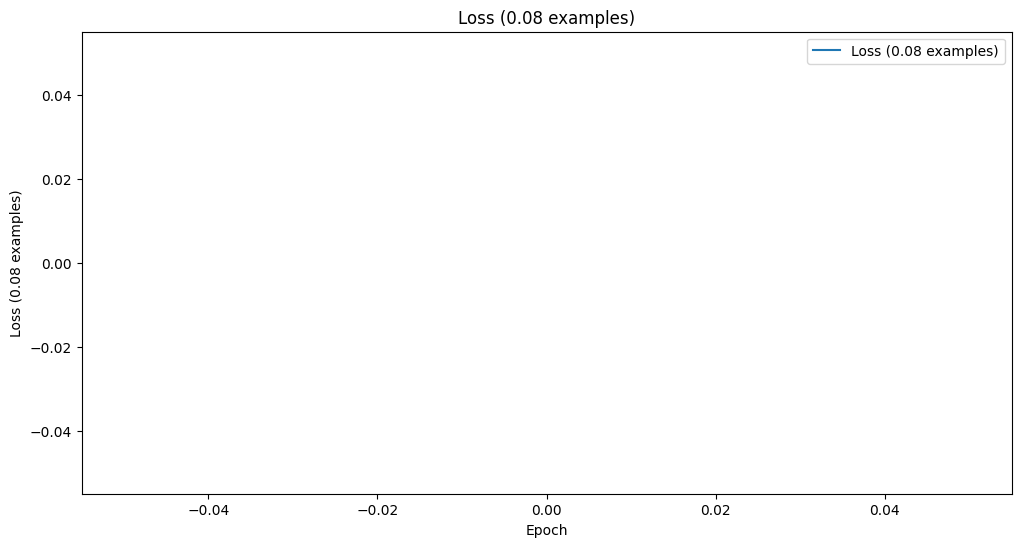

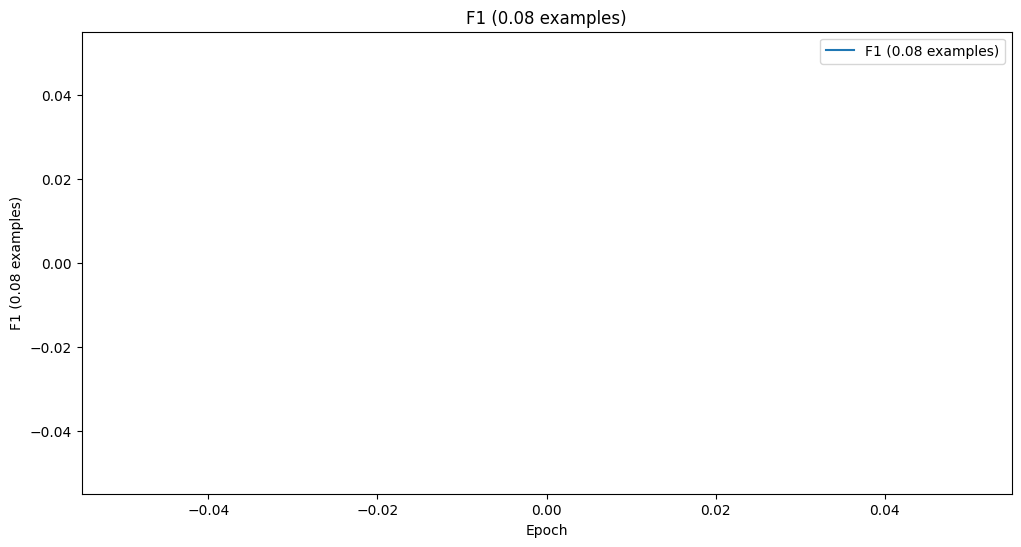

Predicting: |          | 0/? [00:00<?, ?it/s]

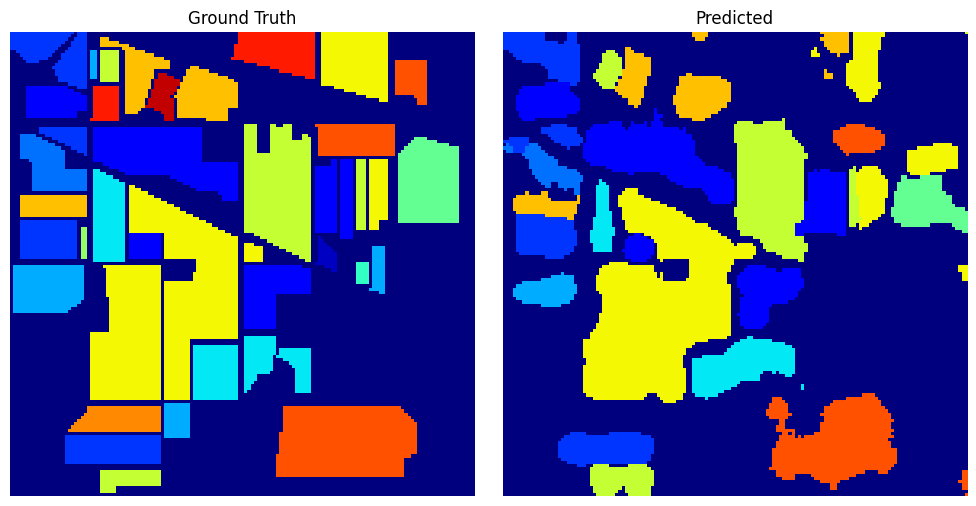

 44%|████▍     | 8/18 [26:54<32:57, 197.73s/it, id=0.08, val_average_accuracy=0.819, val_f1=0.801, val_kappa=nan, val_loss=1.04, val_overall_accuracy=0.689]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8219262957572937
         val_f1              0.799440860748291
        val_kappa                   nan
        val_loss            0.8829689621925354
  val_overall_accuracy      0.6891079545021057
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


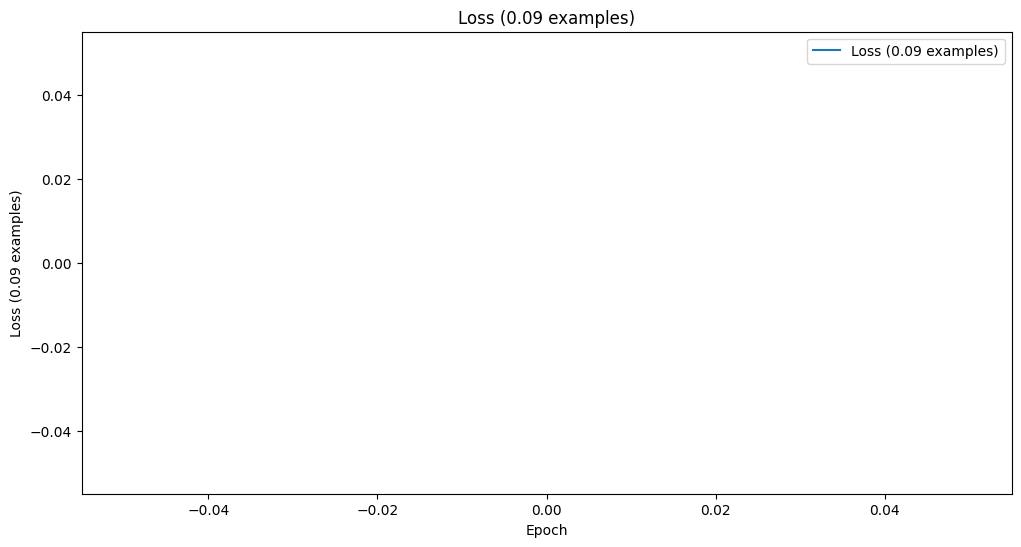

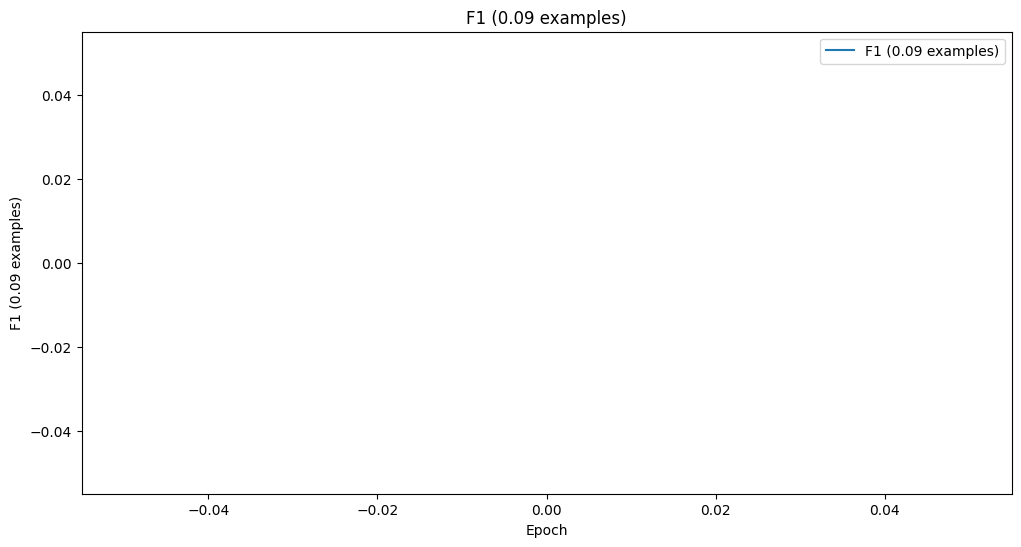

Predicting: |          | 0/? [00:00<?, ?it/s]

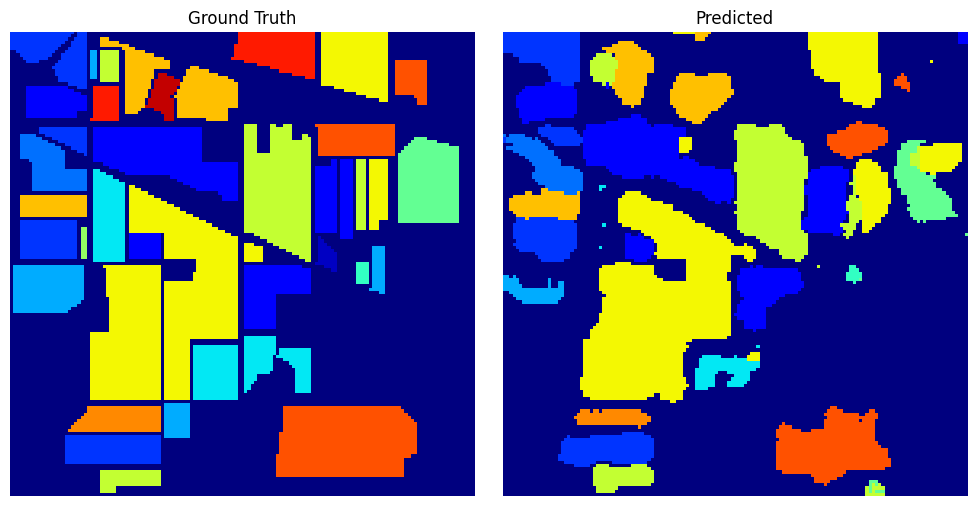

 50%|█████     | 9/18 [30:04<29:15, 195.02s/it, id=0.09, val_average_accuracy=0.822, val_f1=0.799, val_kappa=nan, val_loss=0.883, val_overall_accuracy=0.689]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.851605236530304
         val_f1             0.8345122933387756
        val_kappa                   nan
        val_loss            0.5227240324020386
  val_overall_accuracy      0.7374059557914734
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


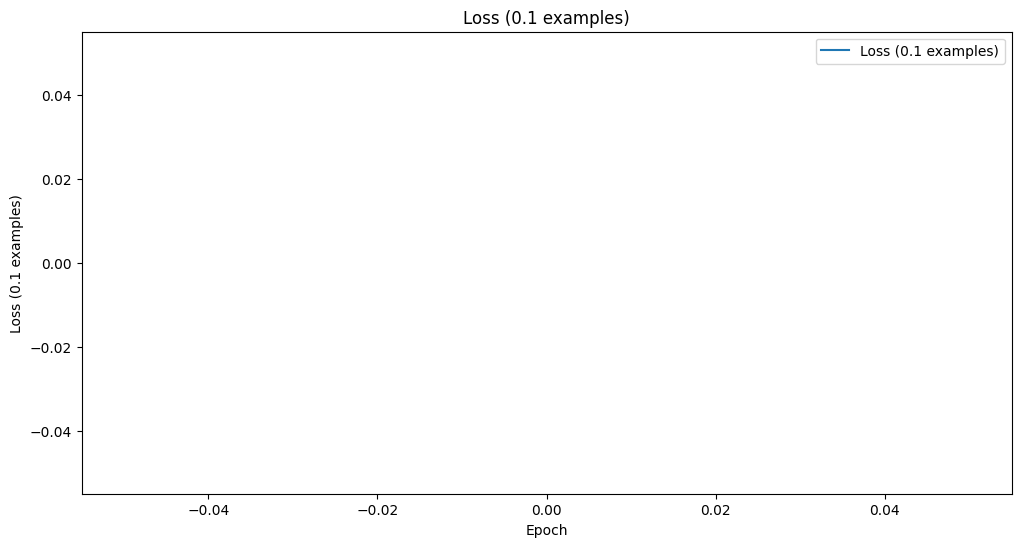

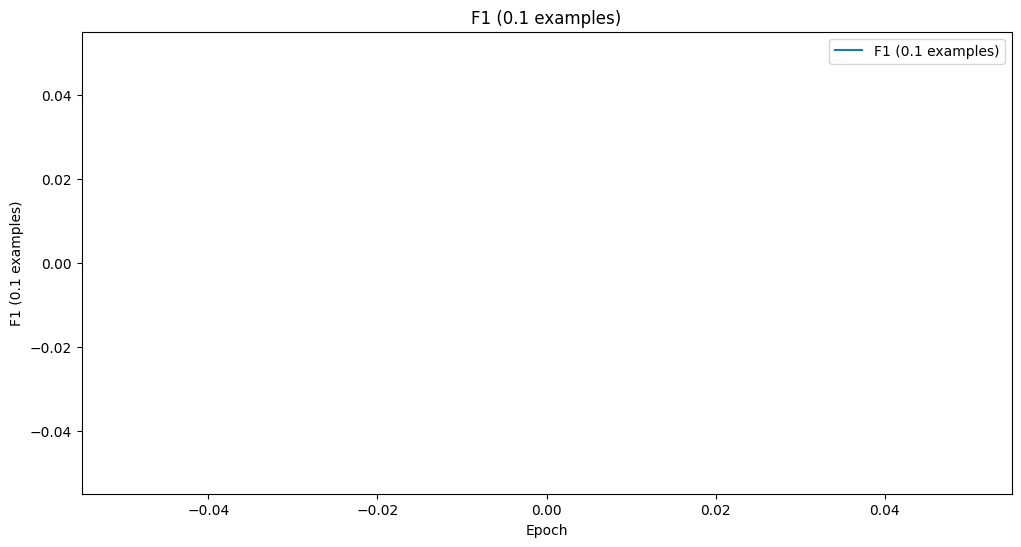

Predicting: |          | 0/? [00:00<?, ?it/s]

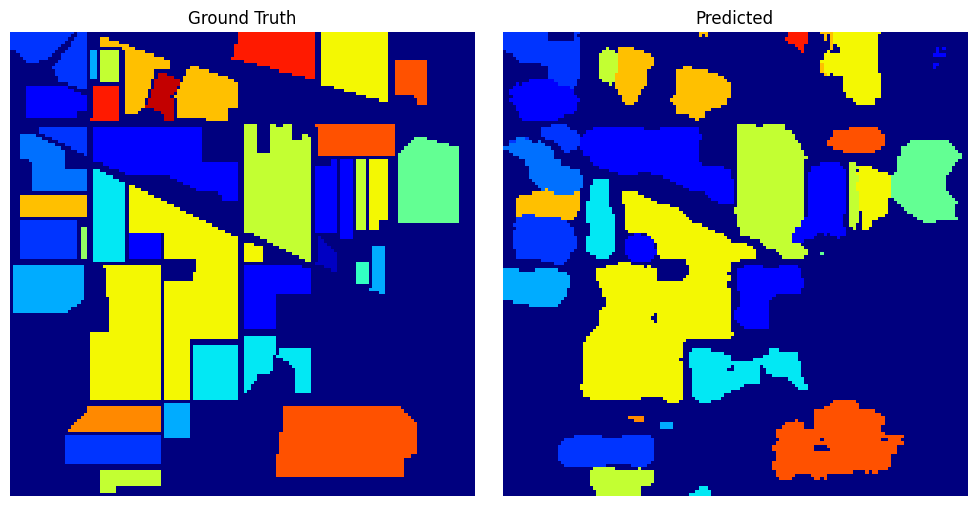

 56%|█████▌    | 10/18 [34:00<27:41, 207.69s/it, id=0.1, val_average_accuracy=0.852, val_f1=0.835, val_kappa=nan, val_loss=0.523, val_overall_accuracy=0.737]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8610701560974121
         val_f1              0.843055248260498
        val_kappa                   nan
        val_loss            0.5151957869529724
  val_overall_accuracy       0.735260009765625
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


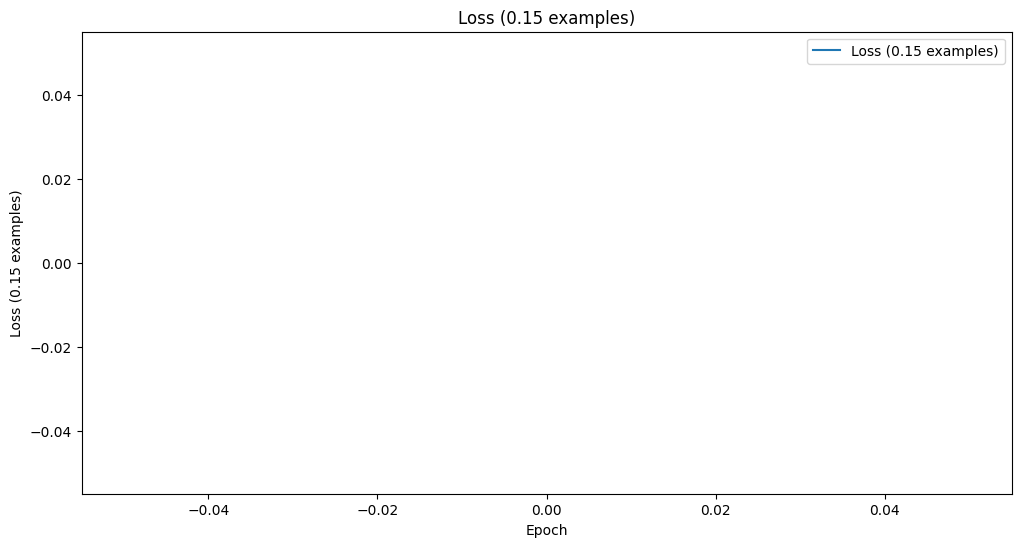

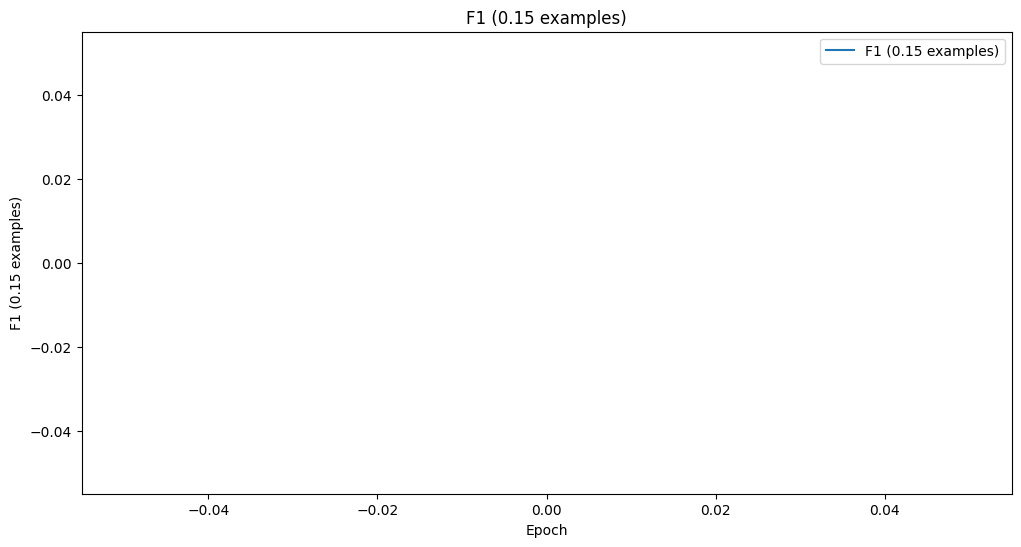

Predicting: |          | 0/? [00:00<?, ?it/s]

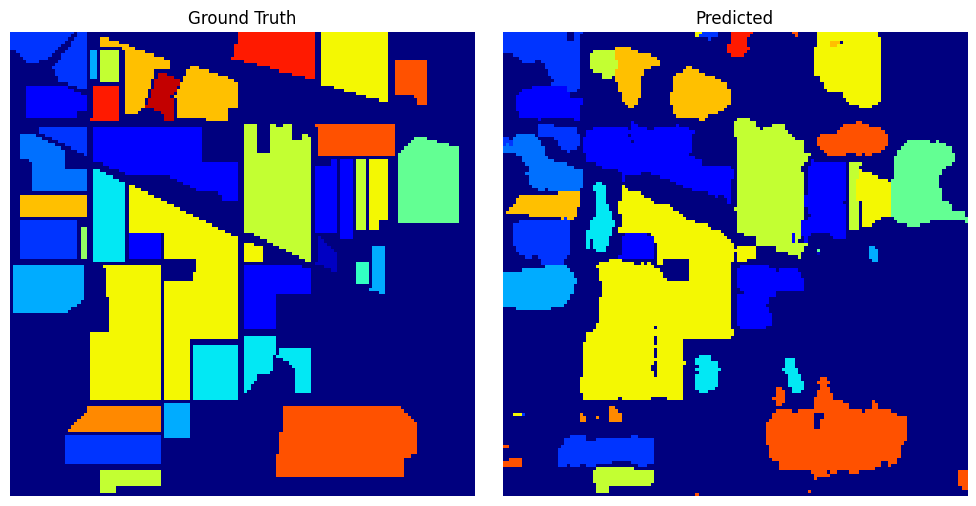

 61%|██████    | 11/18 [39:37<28:52, 247.44s/it, id=0.15, val_average_accuracy=0.861, val_f1=0.843, val_kappa=nan, val_loss=0.515, val_overall_accuracy=0.735]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8919857144355774
         val_f1              0.881477952003479
        val_kappa                   nan
        val_loss            0.46343183517456055
  val_overall_accuracy      0.7801668643951416
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


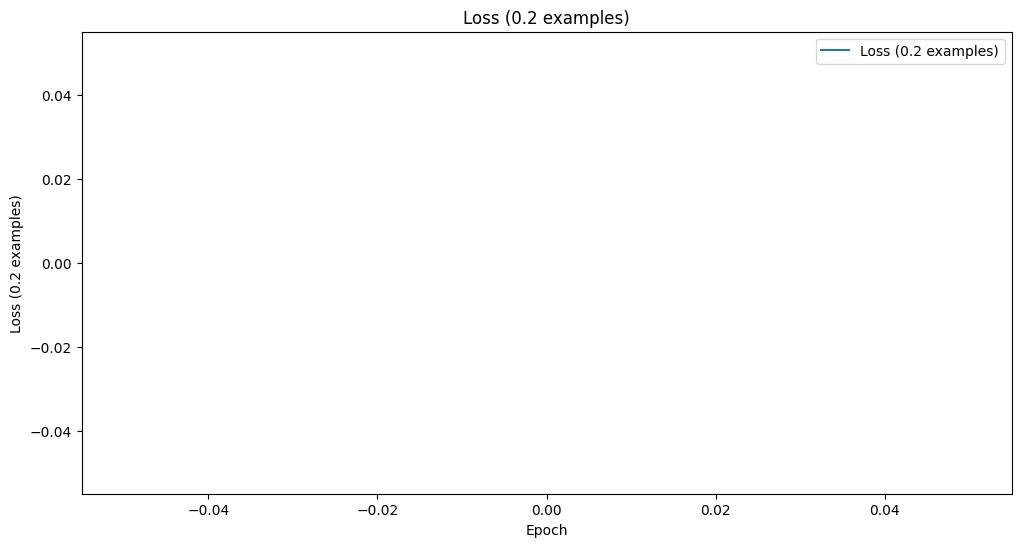

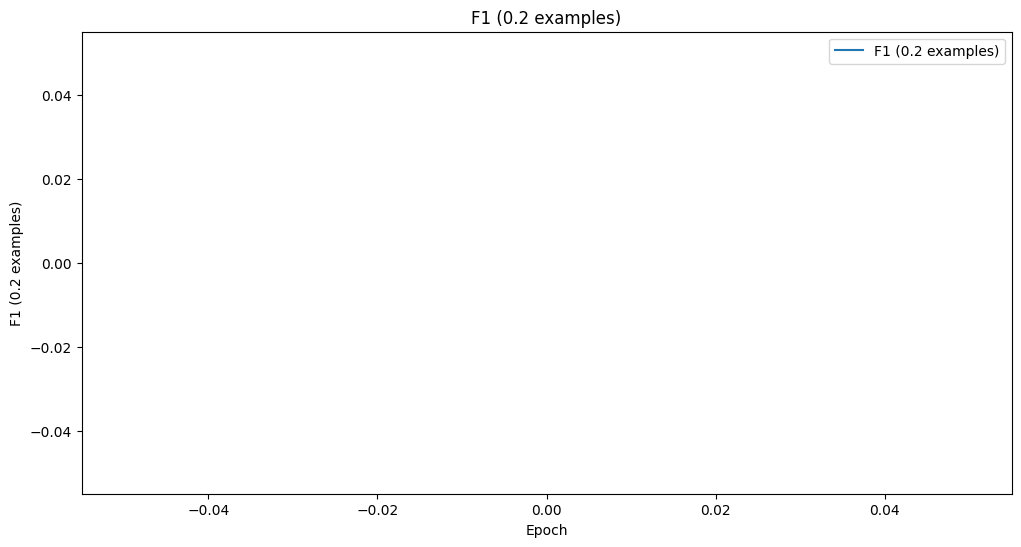

Predicting: |          | 0/? [00:00<?, ?it/s]

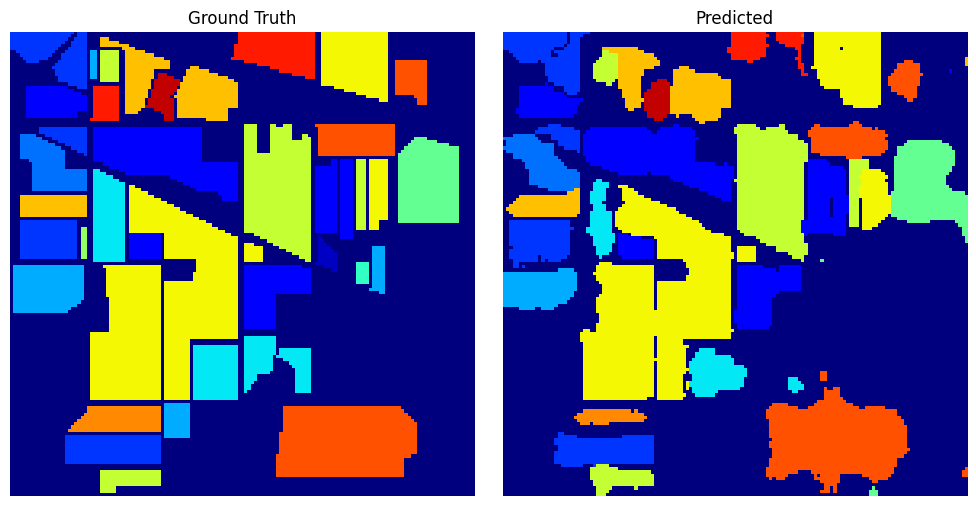

 67%|██████▋   | 12/18 [46:13<29:15, 292.54s/it, id=0.2, val_average_accuracy=0.892, val_f1=0.881, val_kappa=nan, val_loss=0.463, val_overall_accuracy=0.78]  You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccurac

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9325089454650879
         val_f1             0.9275315999984741
        val_kappa                   nan
        val_loss            0.23695652186870575
  val_overall_accuracy      0.8454035520553589
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


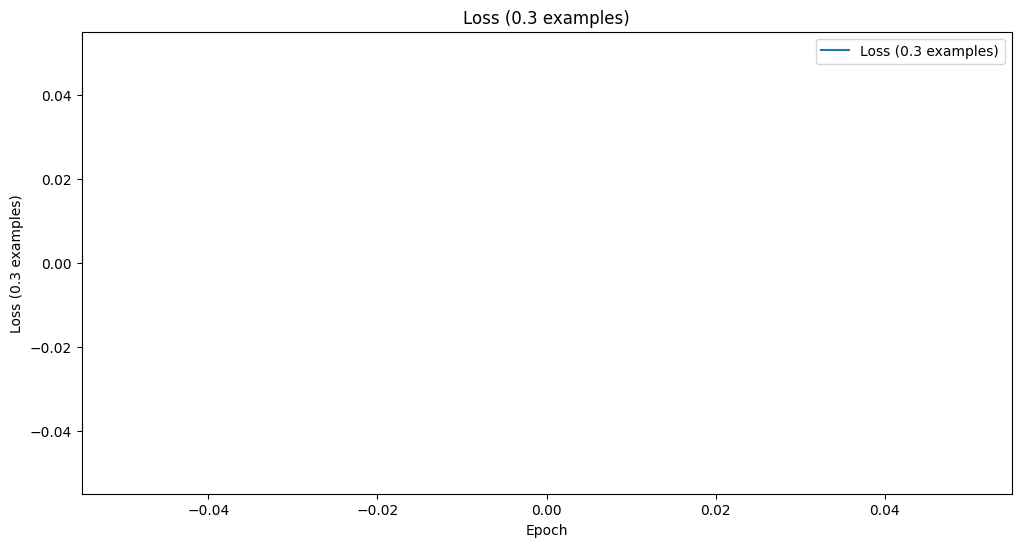

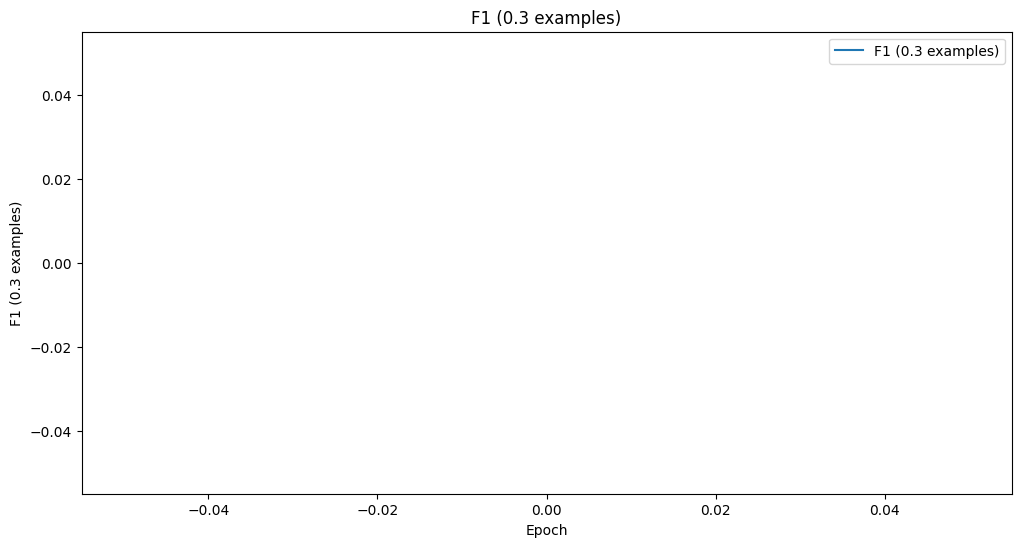

Predicting: |          | 0/? [00:00<?, ?it/s]

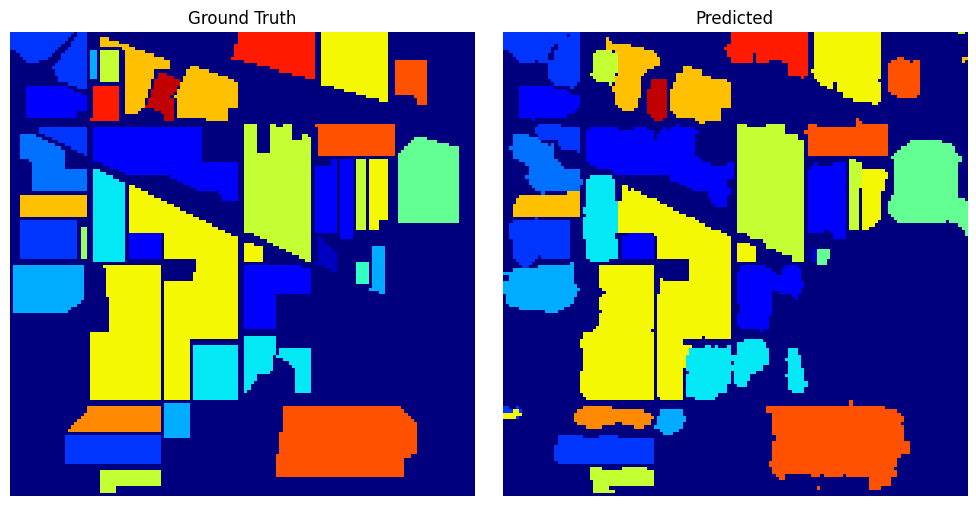

 72%|███████▏  | 13/18 [55:25<30:55, 371.11s/it, id=0.3, val_average_accuracy=0.933, val_f1=0.928, val_kappa=nan, val_loss=0.237, val_overall_accuracy=0.845]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccuracy

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9454458951950073
         val_f1             0.9420307874679565
        val_kappa                   nan
        val_loss            0.17890222370624542
  val_overall_accuracy      0.8853591084480286
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


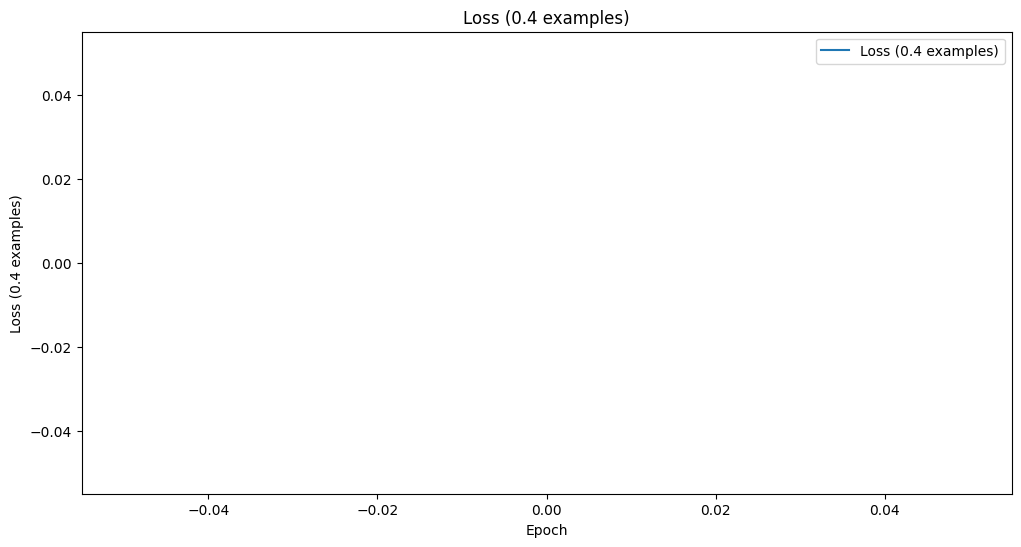

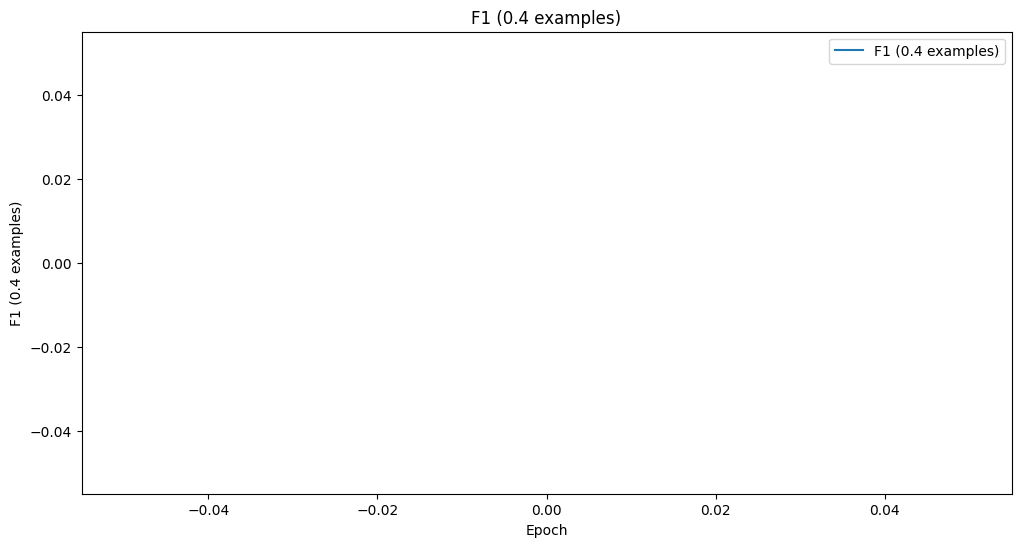

Predicting: |          | 0/? [00:00<?, ?it/s]

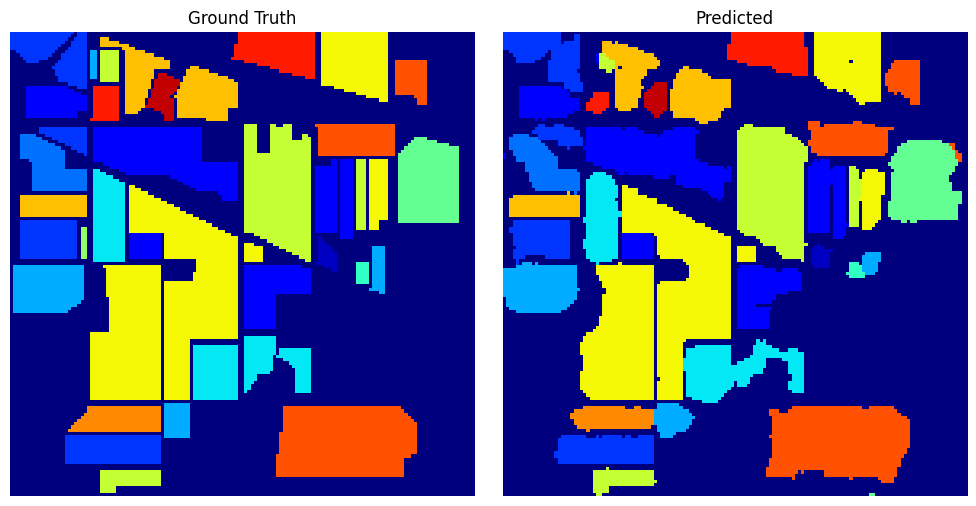

 78%|███████▊  | 14/18 [1:07:31<31:53, 478.44s/it, id=0.4, val_average_accuracy=0.945, val_f1=0.942, val_kappa=nan, val_loss=0.179, val_overall_accuracy=0.885]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9593816995620728
         val_f1             0.9575844407081604
        val_kappa                   nan
        val_loss            0.13930827379226685
  val_overall_accuracy      0.8975041508674622
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


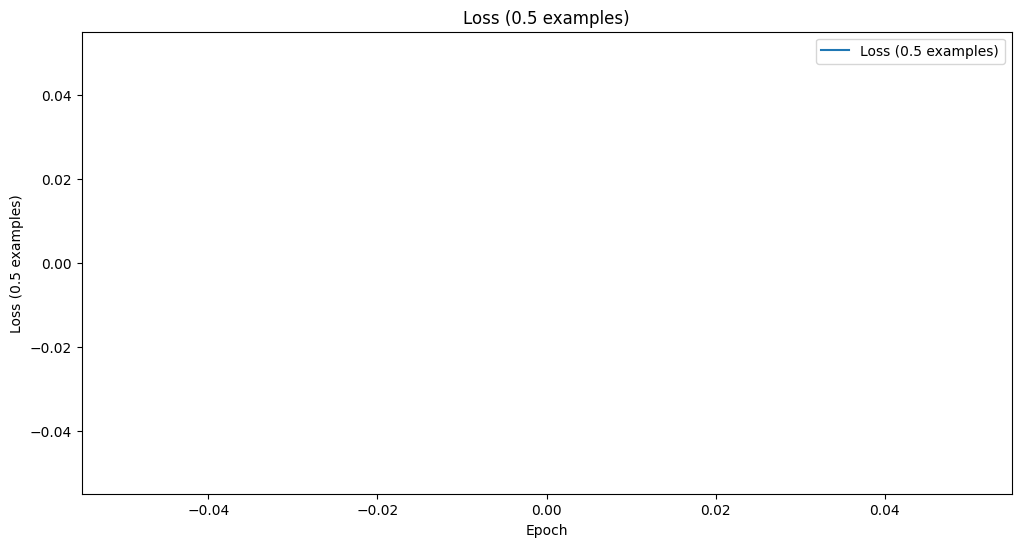

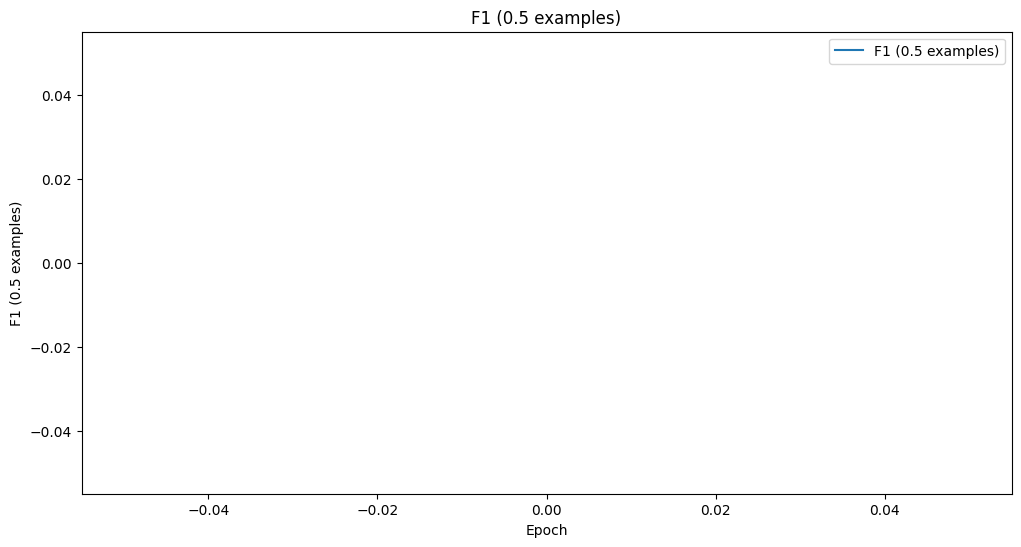

Predicting: |          | 0/? [00:00<?, ?it/s]

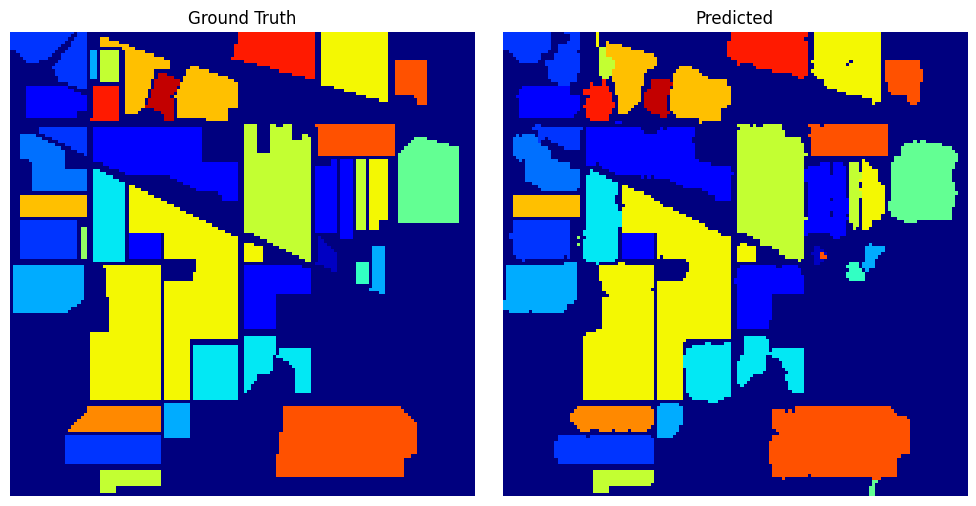

 83%|████████▎ | 15/18 [1:22:40<30:24, 608.18s/it, id=0.5, val_average_accuracy=0.959, val_f1=0.958, val_kappa=nan, val_loss=0.139, val_overall_accuracy=0.898]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9637098908424377
         val_f1             0.9614589214324951
        val_kappa                   nan
        val_loss            0.11248242855072021
  val_overall_accuracy       0.921549379825592
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


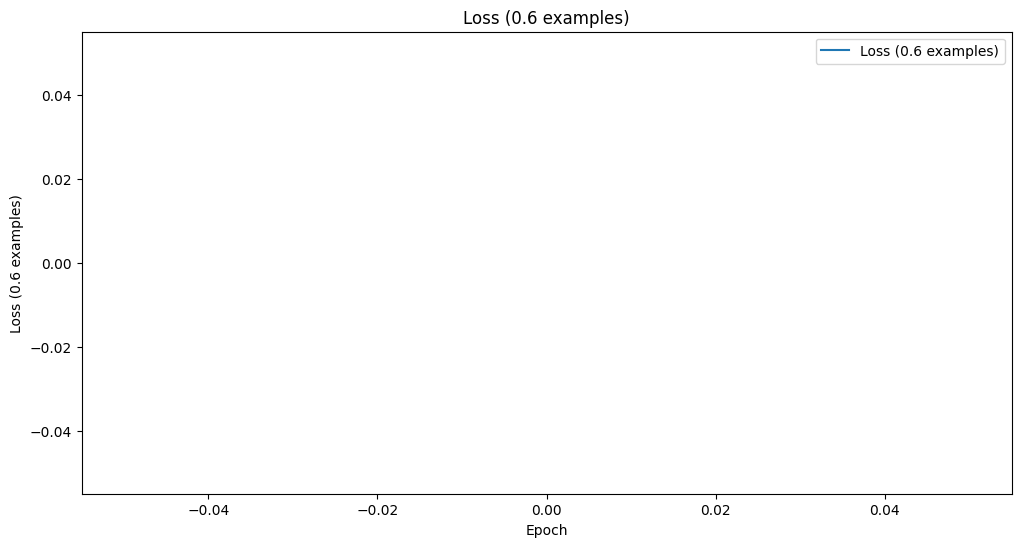

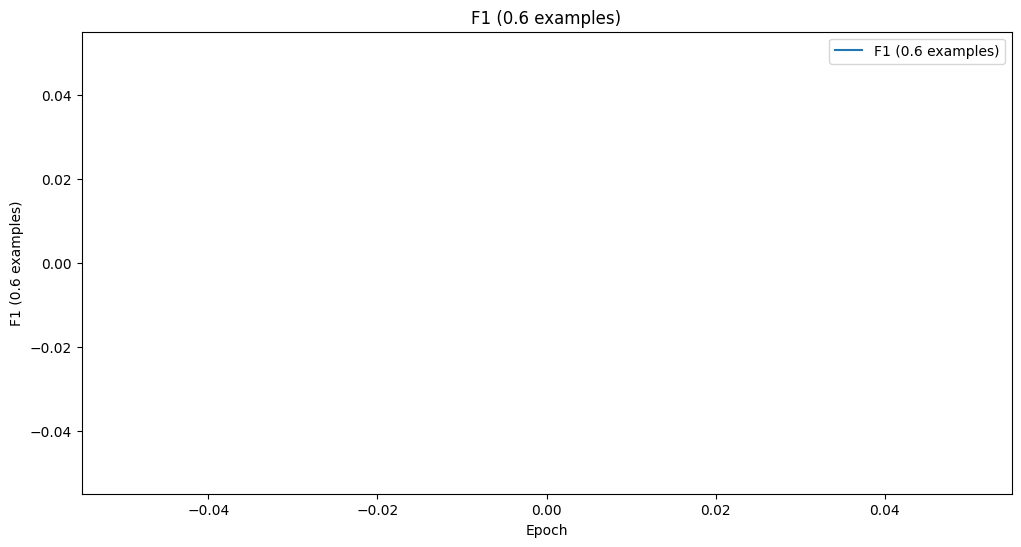

Predicting: |          | 0/? [00:00<?, ?it/s]

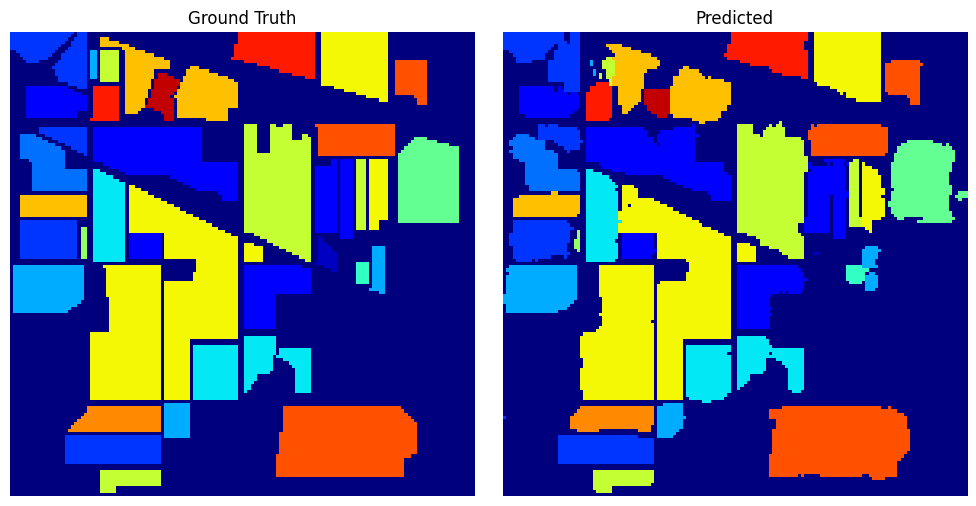

 89%|████████▉ | 16/18 [1:40:49<25:05, 752.82s/it, id=0.6, val_average_accuracy=0.964, val_f1=0.961, val_kappa=nan, val_loss=0.112, val_overall_accuracy=0.922]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccura

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9766468405723572
         val_f1             0.9757232666015625
        val_kappa                   nan
        val_loss            0.07531820982694626
  val_overall_accuracy      0.9461787343025208
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


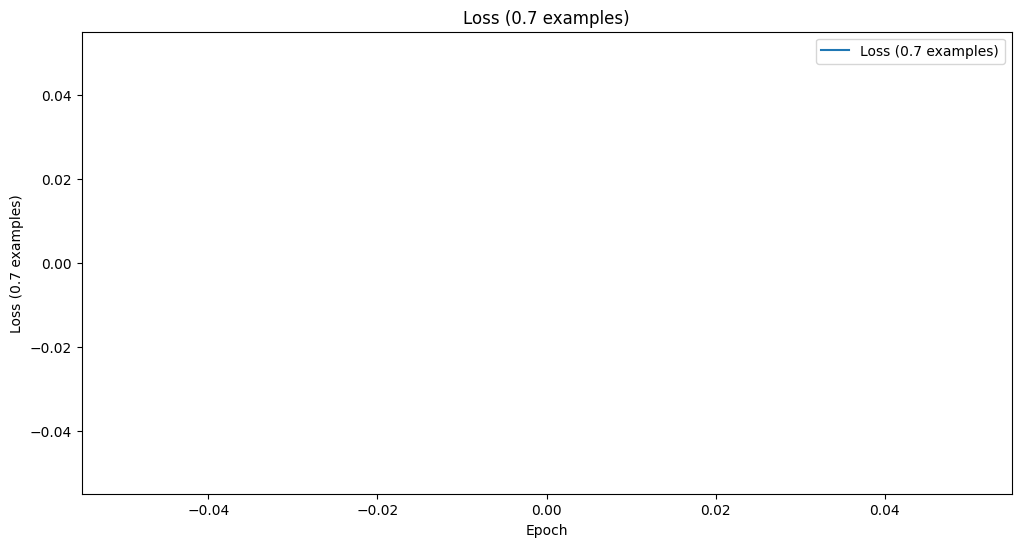

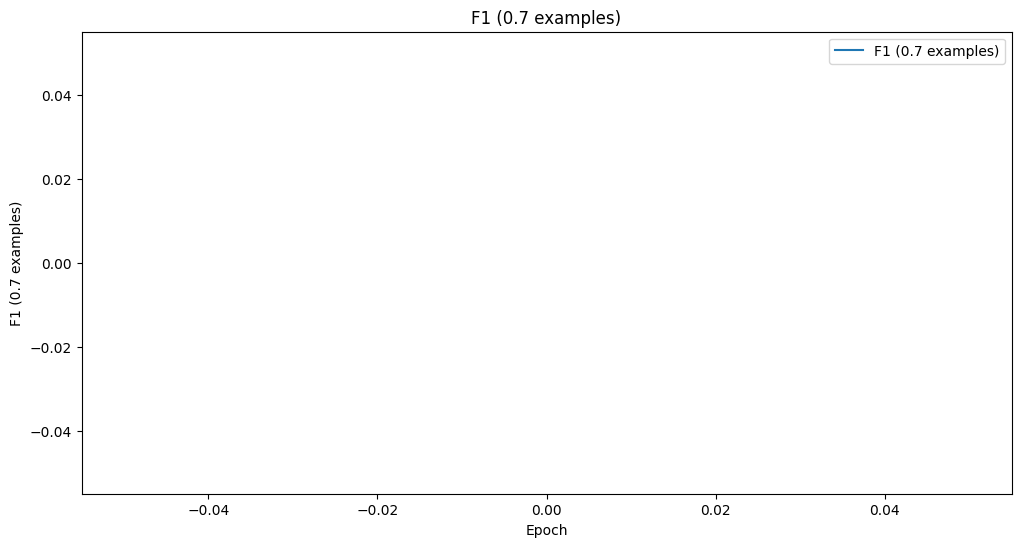

Predicting: |          | 0/? [00:00<?, ?it/s]

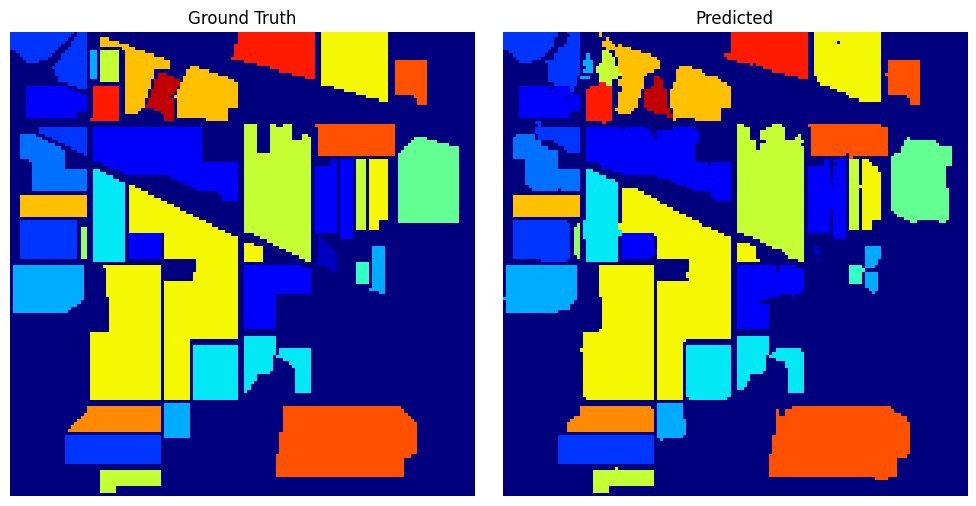

 94%|█████████▍| 17/18 [2:01:47<15:04, 904.69s/it, id=0.7, val_average_accuracy=0.977, val_f1=0.976, val_kappa=nan, val_loss=0.0753, val_overall_accuracy=0.946]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/alexandermelashchenko/Workspace/hsi-classification-playground/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name             | Type                 | Params | Mode 
------------------------------------------------------------------
0 | net              | DBDA                 | 152 K  | train
1 | loss_fun         | CrossEntropyLoss     | 0      | train
2 | f1               | MulticlassF1Score    | 0      | train
3 | overall_accuracy | MulticlassAccur

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.985969066619873
         val_f1             0.9856218695640564
        val_kappa                   nan
        val_loss            0.04626929759979248
  val_overall_accuracy      0.9719430208206177
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


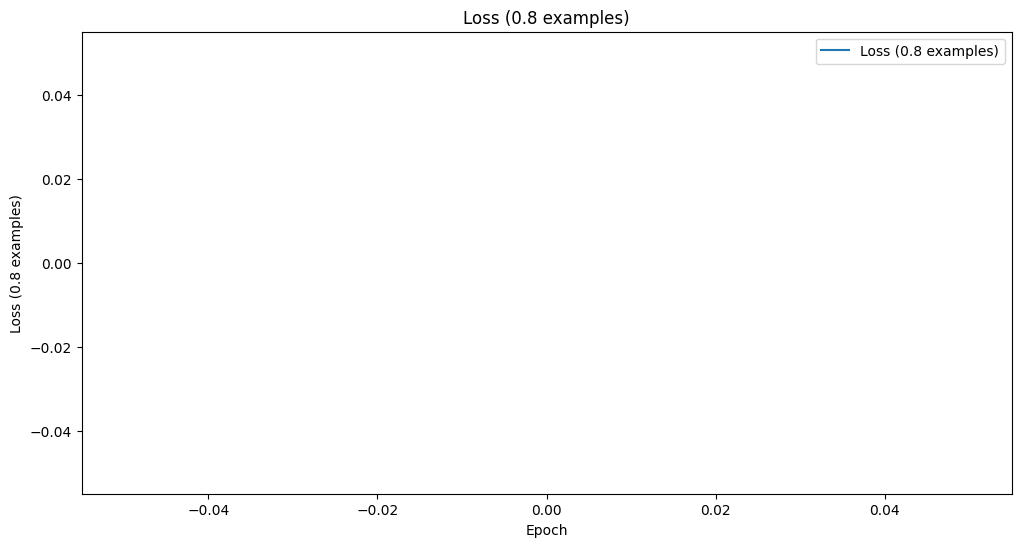

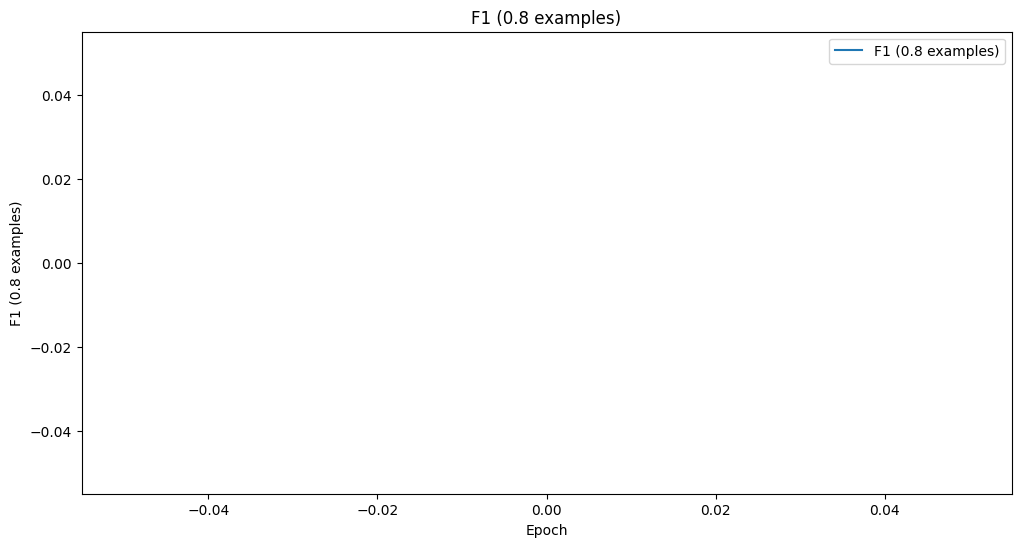

Predicting: |          | 0/? [00:00<?, ?it/s]

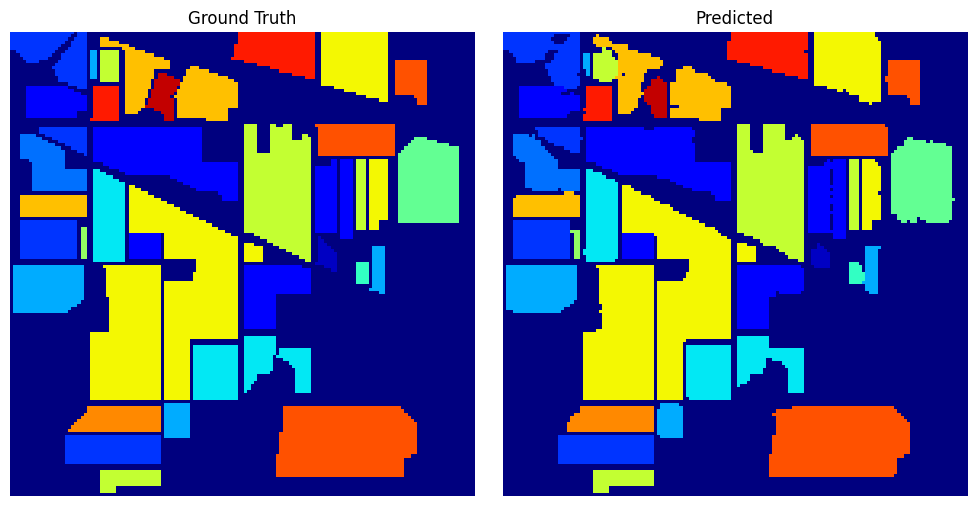

100%|██████████| 18/18 [2:40:08<00:00, 533.78s/it, id=0.8, val_average_accuracy=0.986, val_f1=0.986, val_kappa=nan, val_loss=0.0463, val_overall_accuracy=0.972] 


In [27]:
k_medoids_search = RepresentativeDataPointsSearch(
    KMedoidsSampleDataPointsSearch(), log_dir, f"k-medoids"
)

feedback = k_medoids_search.run()

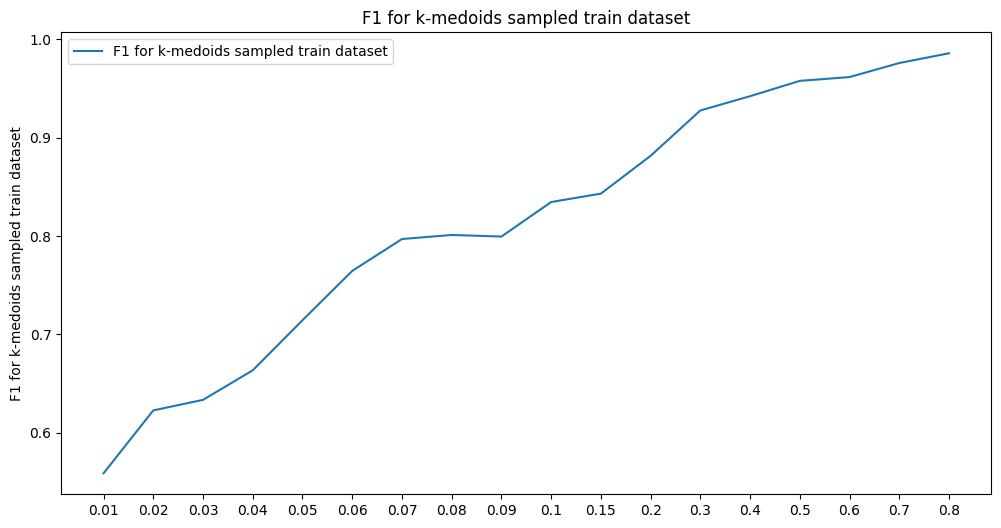

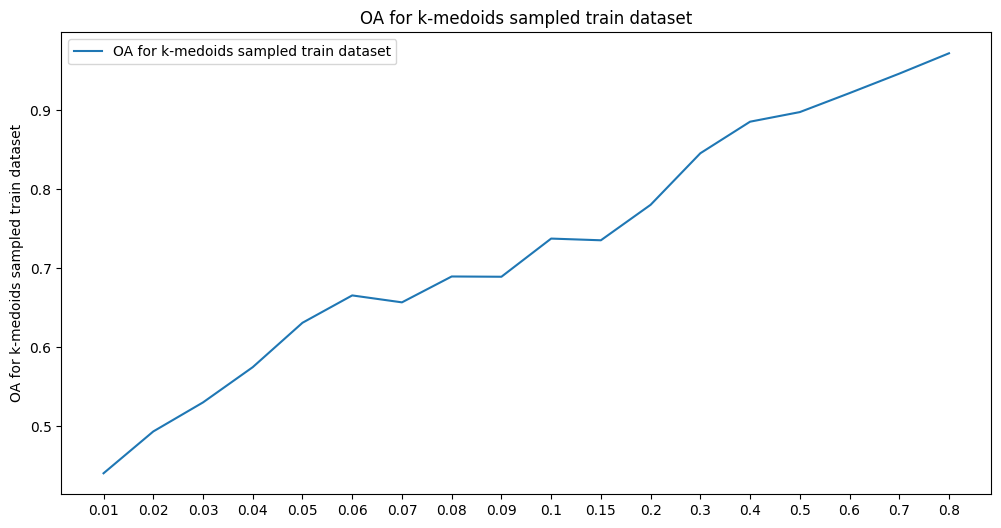

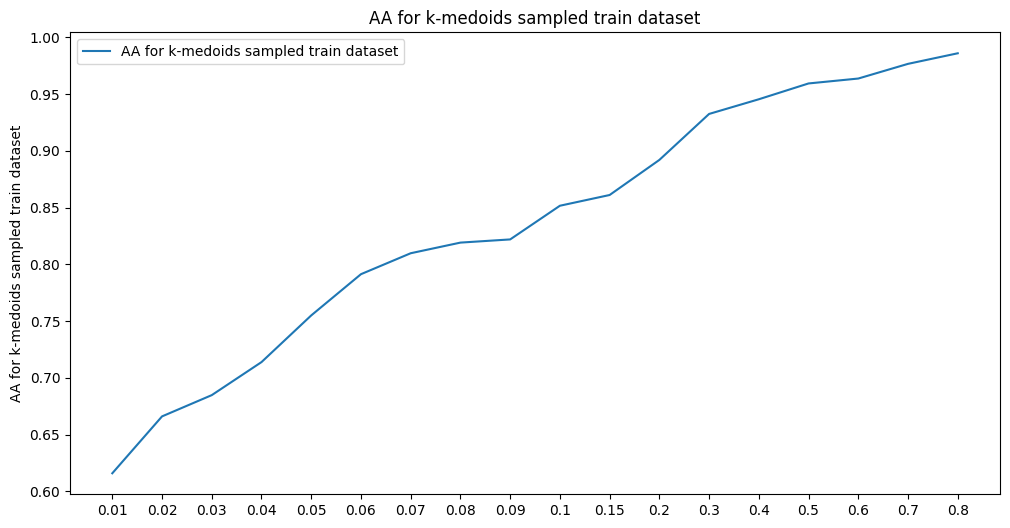

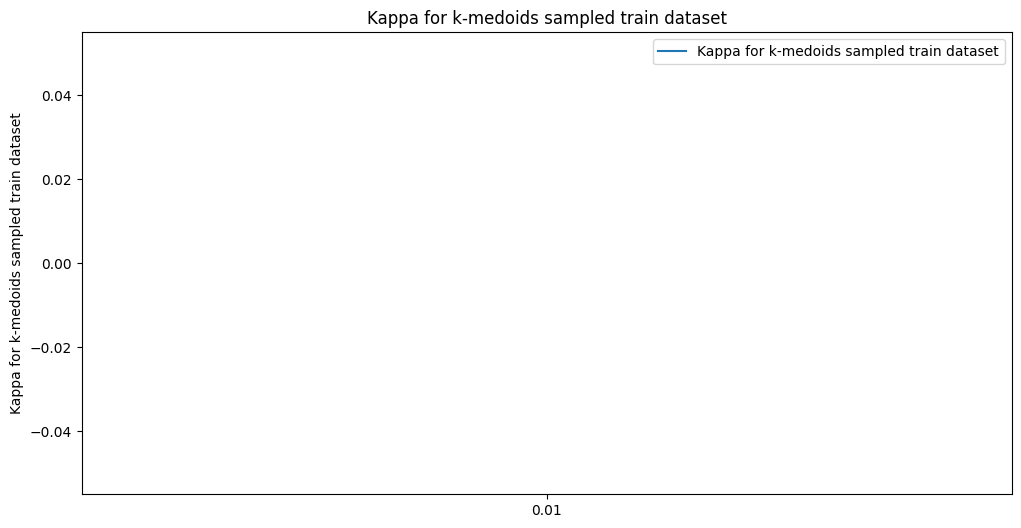

In [28]:
ids = [it.id for it in feedback]
k_medoids_f1s = [it.score["val_f1"] for it in feedback]
k_medoids_oas = [it.score["val_overall_accuracy"] for it in feedback]
k_medoids_aas = [it.score["val_average_accuracy"] for it in feedback]
k_medoids_kappas = [it.score["val_kappa"] for it in feedback]

plot_generic(
    ids,
    k_medoids_f1s,
    desc=f"F1 for k-medoids sampled train dataset",
)
plot_generic(
    ids,
    k_medoids_oas,
    desc=f"OA for k-medoids sampled train dataset",
)
plot_generic(
    ids,
    k_medoids_aas,
    desc=f"AA for k-medoids sampled train dataset",
)
plot_generic(
    ids,
    k_medoids_kappas,
    desc=f"Kappa for k-medoids sampled train dataset",
)

7. Compare results

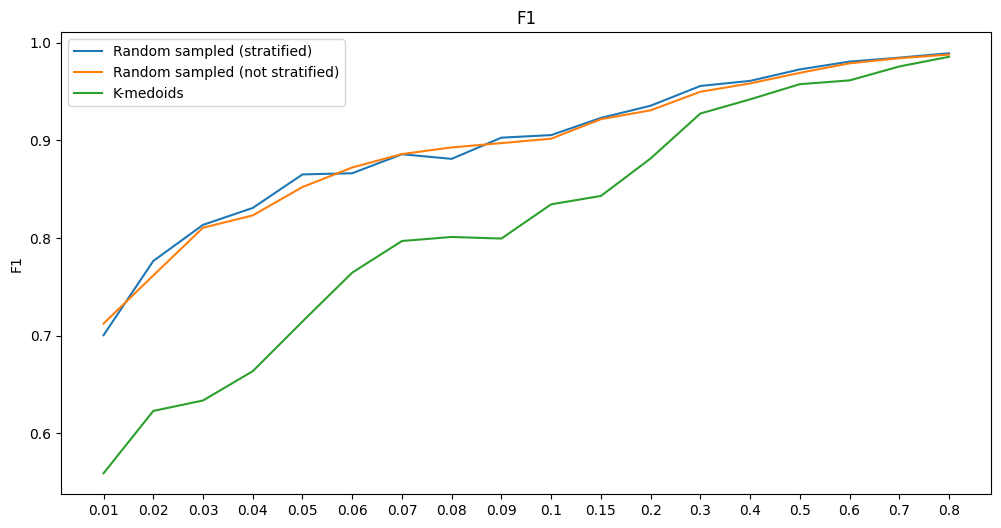

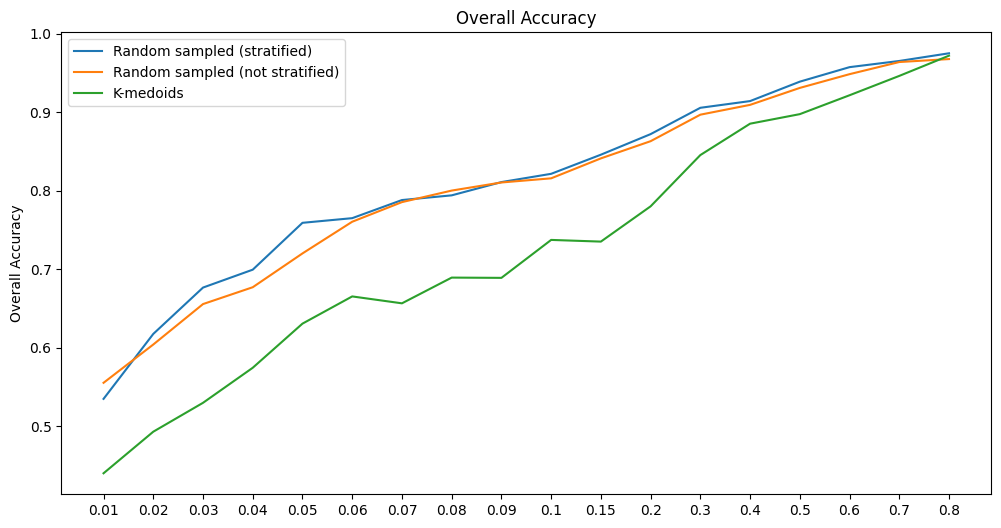

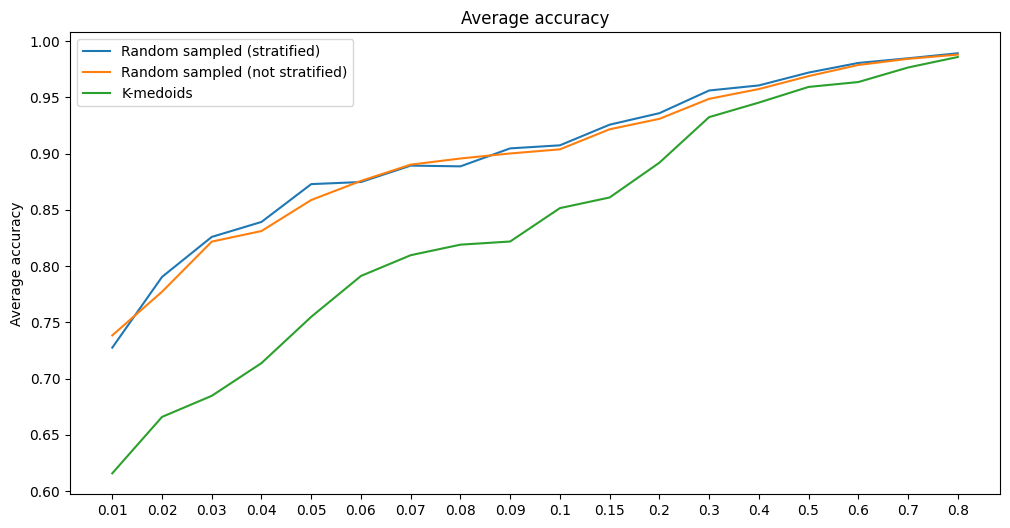

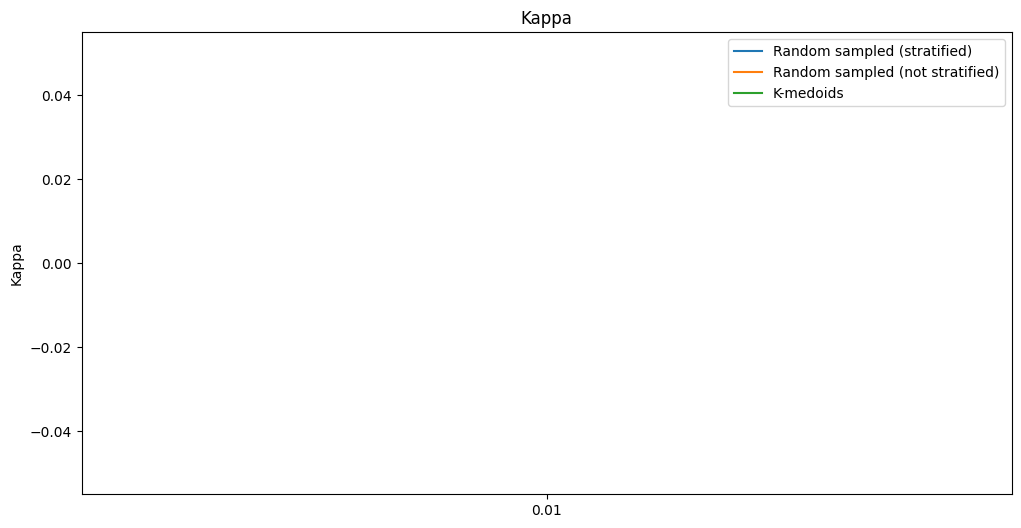

In [29]:
plot_3_generic(
    ids,
    stratified_random_f1s,
    not_stratified_random_f1s,
    k_medoids_f1s,
    desc_0="Random sampled (stratified)",
    desc_1="Random sampled (not stratified)",
    desc_2="K-medoids",
    desc="F1"
)

plot_3_generic(
    ids,
    stratified_random_oas,
    not_stratified_random_oas,
    k_medoids_oas,
    desc_0="Random sampled (stratified)",
    desc_1="Random sampled (not stratified)",
    desc_2="K-medoids",
    desc="Overall Accuracy"
)

plot_3_generic(
    ids,
    stratified_random_aas,
    not_stratified_random_aas,
    k_medoids_aas,
    desc_0="Random sampled (stratified)",
    desc_1="Random sampled (not stratified)",
    desc_2="K-medoids",
    desc="Average accuracy",
)

plot_3_generic(
    ids,
    stratified_random_kappas,
    not_stratified_random_kappas,
    k_medoids_kappas,
    desc_0="Random sampled (stratified)",
    desc_1="Random sampled (not stratified)",
    desc_2="K-medoids",
    desc="Kappa"
)